In [ ]:
!pip install pytesseract

In [ ]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.1 MB/s eta 0:00:00


In [ ]:
!pip install qiskit-algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 5.0 MB/s eta 0:00:00


In [ ]:
# The foundation of your suffering
import hashlib, json, uuid, math, re, io, base64, warnings
from datetime import datetime, timezone, timedelta
from enum import Enum
from typing import Optional, List, Dict, Any, Tuple
from collections import defaultdict, OrderedDict, deque
from dataclasses import dataclass, field, asdict
import heapq, itertools, functools

# The weapons
import numpy as np
import pandas as pd
import networkx as nx
import cv2
import pytesseract
from PIL import Image

# The quantum cage
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler
from qiskit.circuit.library import ZZFeatureMap, TwoLocal
from qiskit_algorithms.state_fidelities import ComputeUncompute

# The AI veneer
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# The web
from fastapi import FastAPI, HTTPException, UploadFile, File, Form
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
from pydantic import BaseModel

warnings.filterwarnings('ignore')

In [ ]:
class QuantumHashChain:
    """Post-quantum hash chain using SHA3-512 + simulated ML-DSA signatures."""

    def __init__(self):
        self.simulator = AerSimulator()
        self.chain = []

    def _quantum_nonce(self) -> str:
        """Generate a nonce using quantum superposition."""
        qc = QuantumCircuit(8, 8)
        qc.h(range(8))
        qc.measure(range(8), range(8))
        job = self.simulator.run(qc, shots=1)
        counts = job.result().get_counts()
        bitstring = list(counts.keys())[0]
        return hex(int(bitstring, 2))[2:].zfill(2)

    def add_event(self, event: Dict) -> Dict:
        prev_hash = self.chain[-1]["event_hash"] if self.chain else "GENESIS"
        nonce = self._quantum_nonce()
        payload = json.dumps({**event, "previous_hash": prev_hash, "nonce": nonce},
                            sort_keys=True, default=str)
        sha3_hash = hashlib.sha3_512(payload.encode()).hexdigest()
        pqc_sig = hashlib.sha3_256(f"ML-DSA:{sha3_hash}:{nonce}".encode()).hexdigest()[:64]

        sealed = {
            **event,
            "event_hash": sha3_hash,
            "previous_hash": prev_hash,
            "quantum_nonce": nonce,
            "pqc_signature": pqc_sig,
            "algorithm": "SHA3-512 + ML-DSA (simulated FIPS 204)",
            "timestamp_utc": datetime.now(timezone.utc).isoformat()
        }
        self.chain.append(sealed)
        return sealed

    def verify(self) -> Dict:
        valid = all(
            self.chain[i]["previous_hash"] == (self.chain[i-1]["event_hash"] if i > 0 else "GENESIS")
            for i in range(len(self.chain))
        )
        return {"total_events": len(self.chain), "all_valid": valid, "quantum_safe": True}


# ---- Run ----
print("=" * 70)
print("  QUANTUM HASH CHAIN — DEMO")
print("=" * 70)

qchain = QuantumHashChain()
ev1 = qchain.add_event({"event_id": "E001", "action": "detection", "desc": "Ransomware detected"})
ev2 = qchain.add_event({"event_id": "E002", "action": "containment", "desc": "Host isolated"})
ev3 = qchain.add_event({"event_id": "E003", "action": "evidence", "desc": "Disk image captured"})

print(f"\n[Event 1] {ev1['event_id']} — {ev1['desc']}")
print(f"  hash    : {ev1['event_hash'][:48]}...")
print(f"  nonce   : {ev1['quantum_nonce']}")
print(f"  PQC sig : {ev1['pqc_signature'][:48]}...")

print(f"\n[Event 2] {ev2['event_id']} — {ev2['desc']}")
print(f"  hash    : {ev2['event_hash'][:48]}...")
print(f"  prev    : {ev2['previous_hash'][:48]}...")
print(f"  ✓ chain links correctly: {ev2['previous_hash'] == ev1['event_hash']}")

print(f"\n[Event 3] {ev3['event_id']} — {ev3['desc']}")
print(f"  hash    : {ev3['event_hash'][:48]}...")
print(f"  prev    : {ev3['previous_hash'][:48]}...")
print(f"  ✓ chain links correctly: {ev3['previous_hash'] == ev2['event_hash']}")

verification = qchain.verify()
print(f"\n[Verification]")
print(f"  Total events     : {verification['total_events']}")
print(f"  All valid        : {verification['all_valid']}")
print(f"  Quantum-resistant: {verification['quantum_safe']}")

  QUANTUM HASH CHAIN — DEMO

[Event 1] E001 — Ransomware detected
  hash    : b934de2f969db5e4f8266baa91564aa42bbfbd5a9b63711a...
  nonce   : 44
  PQC sig : db49b09c217f25f770e334e6b0faad7af5081091c43d076b...

[Event 2] E002 — Host isolated
  hash    : ae6543b54e3174f6f279741013722bc9b48a9f5a7a67dc48...
  prev    : b934de2f969db5e4f8266baa91564aa42bbfbd5a9b63711a...
  ✓ chain links correctly: True

[Event 3] E003 — Disk image captured
  hash    : d9ce57ac2ad95911ce4fb6eb26a2528d71af4ebca8e05989...
  prev    : ae6543b54e3174f6f279741013722bc9b48a9f5a7a67dc48...
  ✓ chain links correctly: True

[Verification]
  Total events     : 3
  All valid        : True
  Quantum-resistant: True


In [ ]:
from google.colab import files

uploaded = files.upload()          # opens a file picker
CSV_PATH = list(uploaded.keys())[0]
print("Uploaded:", CSV_PATH)

Saving Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv to Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Uploaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [ ]:
# ============================================================
# QUANTUM ANOMALY DETECTOR — FULL WORKING SCRIPT
# Dataset: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist


# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------
CSV_PATH = "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"   # <-- change if needed

# Sanity check: make sure the file exists in the current directory
if not os.path.exists(CSV_PATH):
    print(f"File not found: {CSV_PATH}")
    print(f"Current directory: {os.getcwd()}")
    print(f"Files here: {os.listdir('.')}")
    raise FileNotFoundError(CSV_PATH)

df = pd.read_csv(CSV_PATH)

# Strip leading/trailing whitespace from column names
# (CICIDS2017 CSVs have names like " Flow Duration")
df.columns = df.columns.str.strip()

print("=" * 70)
print("  QUANTUM ANOMALY DETECTOR — TRAINING")
print("=" * 70)
print(f"Loaded rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")


# ------------------------------------------------------------
# 2. (Optional) Subsample to keep training tractable
#    The full file has ~225k rows; the pure quantum-kernel
#    approach is O(n_test * n_train), so we subsample.
# ------------------------------------------------------------
df = df.sample(frac=0.05, random_state=42).reset_index(drop=True)
print(f"\nRows after 5% subsampling: {len(df)}")


# ------------------------------------------------------------
# 3. Quantum-kernel-inspired anomaly detector (vectorized)
# ------------------------------------------------------------
class QuantumAnomalyDetector:
    """Quantum-kernel-inspired anomaly detector."""

    def __init__(self, n_qubits=4):
        self.n_qubits = n_qubits
        self.pca = PCA(n_components=n_qubits)
        self.scaler = StandardScaler()
        self.X_train = None
        self.y_train = None

    def _quantum_kernel(self, x1, x2):
        # RBF-like kernel: exp(-||x1 - x2||^2)
        return np.exp(-np.linalg.norm(x1 - x2) ** 2)

    def fit(self, X, y):
        X_scaled = self.scaler.fit_transform(X)
        self.X_train = self.pca.fit_transform(X_scaled)
        self.y_train = y
        return self

    def predict(self, X):
        """Vectorized nearest-neighbour prediction using the quantum kernel."""
        X_pca = self.pca.transform(self.scaler.transform(X))
        # squared Euclidean distance between every test & train point
        dists = cdist(X_pca, self.X_train, metric='sqeuclidean')
        sims = np.exp(-dists)                    # RBF / "quantum" kernel
        return self.y_train[np.argmax(sims, axis=1)]

    def anomaly_score(self, X):
        """Distance from each test point to the nearest benign training point."""
        X_pca = self.pca.transform(self.scaler.transform(X))
        benign = self.X_train[self.y_train == 0]
        if len(benign) == 0:
            return np.full(len(X_pca), np.nan)
        return cdist(X_pca, benign, metric='euclidean').min(axis=1)


# ------------------------------------------------------------
# 4. Prepare features and labels
# ------------------------------------------------------------
feature_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packet Length Mean', 'Flow IAT Mean', 'Flow Packets/s',
    'Fwd Packets/s', 'Average Packet Size', 'Packet Length Variance',
    'SYN Flag Count'
]

# Verify all requested columns exist
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns in CSV: {missing}\nAvailable: {df.columns.tolist()}")

# Clean the data: replace inf/-inf with NaN, then impute NaN with column mean
X_temp = df[feature_cols]
X_temp = X_temp.replace([np.inf, -np.inf], np.nan)
X_temp = X_temp.fillna(X_temp.mean())
X = X_temp.values

# Binary label: 1 = attack (anything not BENIGN), 0 = benign
y = (df['Label'] != 'BENIGN').astype(int).values


# ------------------------------------------------------------
# 5. Train/test split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n[Split]")
print(f"  Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"  Train DDoS ratio: {y_train.mean():.4f}")
print(f"  Test  DDoS ratio: {y_test.mean():.4f}")


# ------------------------------------------------------------
# 6. Fit the quantum detector
# ------------------------------------------------------------
qdetector = QuantumAnomalyDetector(n_qubits=4)
qdetector.fit(X_train, y_train)

y_pred = qdetector.predict(X_test)
acc = (y_pred == y_test).mean()

print(f"\n[Quantum Detector]")
print(f"  Accuracy: {acc:.4f}")


# ------------------------------------------------------------
# 7. Show first 10 test predictions
# ------------------------------------------------------------
print(f"\n[First 10 test samples]")
print(f"  {'idx':<5}{'true':<8}{'pred':<8}{'score':<12}{'match':<6}")

scores = qdetector.anomaly_score(X_test[:10])
for i in range(10):
    tl = "DDoS" if y_test[i] == 1 else "BENIGN"
    pl = "DDoS" if y_pred[i] == 1 else "BENIGN"
    m = "✓" if y_test[i] == y_pred[i] else "✗"
    print(f"  {i:<5}{tl:<8}{pl:<8}{scores[i]:<12.4f}{m:<6}")


# ------------------------------------------------------------
# 8. Classification report
# ------------------------------------------------------------
print(f"\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'DDoS']))

  QUANTUM ANOMALY DETECTOR — TRAINING
Loaded rows: 225745
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'A

In [ ]:
import networkx as nx
from collections import defaultdict

def build_flow_graph(df, sample_size=300):
    """Build directed graph from real flow records."""
    sample = df.sample(n=min(sample_size, len(df)), random_state=42)
    G = nx.DiGraph()

    for idx, row in sample.iterrows():
        node_id = f"flow:{idx}"
        G.add_node(
            node_id,
            label=f"F{idx}",
            dest_port=int(row['Destination Port']),
            duration=float(row['Flow Duration']),
            fwd_packets=int(row['Total Fwd Packets']),
            attack_label=int(row['Label'] != 'BENIGN'),
            node_type="attack" if row['Label'] != 'BENIGN' else "benign"
        )

    nodes_by_port = defaultdict(list)
    for n, d in G.nodes(data=True):
        nodes_by_port[d['dest_port']].append(n)

    for port, nodes in nodes_by_port.items():
        for i in range(len(nodes) - 1):
            G.add_edge(nodes[i], nodes[i+1], edge_type="same_port",
                       port=port, duration=1.0, fwd_packets=1)

    return G


print("=" * 70)
print("  ATTACK GRAPH — CONSTRUCTION")
print("=" * 70)

G = build_flow_graph(df, sample_size=300)

attack_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'attack']
benign_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'benign']

print(f"\n[Graph Stats]")
print(f"  Total nodes : {G.number_of_nodes()}")
print(f"  Total edges : {G.number_of_edges()}")
print(f"  Attack nodes: {len(attack_nodes)}")
print(f"  Benign nodes: {len(benign_nodes)}")
print(f"  Density     : {nx.density(G):.6f}")
print(f"  Is DAG      : {nx.is_directed_acyclic_graph(G)}")

print(f"\n[Sample attack nodes]")
for n in attack_nodes[:5]:
    d = G.nodes[n]
    print(f"  {n:<12} port={d['dest_port']:<6} duration={d['duration']:.0f} fwd_pkts={d['fwd_packets']}")

  ATTACK GRAPH — CONSTRUCTION

[Graph Stats]
  Total nodes : 300
  Total edges : 237
  Attack nodes: 176
  Benign nodes: 124
  Density     : 0.002642
  Is DAG      : True

[Sample attack nodes]
  flow:10517   port=80     duration=5880885 fwd_pkts=5
  flow:5279    port=80     duration=5919853 fwd_pkts=5
  flow:10301   port=80     duration=548618 fwd_pkts=3
  flow:5340    port=80     duration=4104954 fwd_pkts=4
  flow:8579    port=80     duration=1408840 fwd_pkts=3


In [ ]:
from collections import deque
import math
import heapq

class AttackGraphEngine:
    """Every graph algorithm in one place."""

    def __init__(self, G):
        self.G = G

    def bfs(self, start):
        visited, dist, order = {start}, {start: 0}, [start]
        q = deque([start])
        while q:
            u = q.popleft()
            for v in self.G.successors(u):
                if v not in visited:
                    visited.add(v); dist[v] = dist[u] + 1
                    order.append(v); q.append(v)
        return {"algorithm": "BFS", "reachable": len(order),
                "nodes": order[:10], "complexity": "O(V + E)"}

    def dijkstra(self, src):
        dist, prev = {src: 0}, {}
        pq = [(0, src)]
        visited = set()
        while pq:
            d, u = heapq.heappop(pq)
            if u in visited: continue
            visited.add(u)
            for v in self.G.successors(u):
                w = self.G[u][v].get('duration', 1.0)
                nd = d + w
                if nd < dist.get(v, math.inf):
                    dist[v] = nd; prev[v] = u
                    heapq.heappush(pq, (nd, v))
        top = sorted(dist.items(), key=lambda x: x[1])[:10]
        return {"algorithm": "Dijkstra", "top_10": dict(top),
                "complexity": "O((V+E) log V)"}

    def astar(self, src, dst):
        h = lambda n: 0 if self.G.nodes[n].get('attack_label') == 1 else 100
        open_set = [(h(src), 0, src)]
        came, gs = {}, {src: 0}
        visited = set()
        while open_set:
            _, g, cur = heapq.heappop(open_set)
            if cur == dst:
                path = [cur]
                while cur in came:
                    cur = came[cur]; path.append(cur)
                return {"algorithm": "A*", "path": path[::-1], "cost": g,
                        "complexity": "O(E log V)"}
            if cur in visited: continue
            visited.add(cur)
            for v in self.G.successors(cur):
                w = self.G[cur][v].get('duration', 1.0)
                t = gs[cur] + w
                if t < gs.get(v, math.inf):
                    came[v] = cur; gs[v] = t
                    heapq.heappush(open_set, (t + h(v), t, cur))
        return {"algorithm": "A*", "path": None, "error": "no path"}

    def kahn_topo(self):
        indeg = {n: self.G.in_degree(n) for n in self.G}
        q = deque([n for n, d in indeg.items() if d == 0])
        order = []
        while q:
            u = q.popleft(); order.append(u)
            for v in self.G.successors(u):
                indeg[v] -= 1
                if indeg[v] == 0: q.append(v)
        return {"algorithm": "Kahn Topological Sort", "order": order[:10],
                "is_dag": len(order) == len(self.G), "complexity": "O(V + E)"}

    def tarjan_scc(self):
        idx = [0]; stack = []; on = set(); indices = {}; low = {}; sccs = []
        def strong(v):
            indices[v] = low[v] = idx[0]; idx[0] += 1
            stack.append(v); on.add(v)
            for w in self.G.successors(v):
                if w not in indices:
                    strong(w); low[v] = min(low[v], low[w])
                elif w in on:
                    low[v] = min(low[v], indices[w])
            if low[v] == indices[v]:
                comp = []
                while True:
                    w = stack.pop(); on.remove(w); comp.append(w)
                    if w == v: break
                sccs.append(comp)
        for n in self.G:
            if n not in indices: strong(n)
        cyclic = [s for s in sccs if len(s) > 1]
        return {"algorithm": "Tarjan SCC", "total_sccs": len(sccs),
                "cyclic_sccs": len(cyclic), "complexity": "O(V + E)"}

    def kruskal_mst(self):
        G_u = self.G.to_undirected()
        parent = {n: n for n in G_u}; rank = {n: 0 for n in G_u}
        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]; x = parent[x]
            return x
        def union(a, b):
            ra, rb = find(a), find(b)
            if ra == rb: return False
            if rank[ra] < rank[rb]: ra, rb = rb, ra
            parent[rb] = ra
            if rank[ra] == rank[rb]: rank[ra] += 1
            return True
        edges = sorted(G_u.edges(data=True), key=lambda e: e[2].get('duration', 1.0))
        mst = []
        for u, v, d in edges:
            if union(u, v): mst.append((u, v))
        return {"algorithm": "Kruskal MST", "mst_edges": len(mst),
                "complexity": "O(E log E)"}

    def pagerank(self, d=0.85, iters=30):
        nodes = list(self.G.nodes); n = len(nodes)
        if n == 0: return {"algorithm": "PageRank", "top": {}}
        pr = {x: 1/n for x in nodes}
        for _ in range(iters):
            new = {x: (1-d)/n for x in nodes}
            for u in nodes:
                od = self.G.out_degree(u)
                if od == 0: continue
                sh = d * pr[u] / od
                for v in self.G.successors(u): new[v] += sh
            pr = new
        top = dict(sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10])
        return {"algorithm": "PageRank", "top": top, "complexity": "O(k * E)"}

    def betweenness(self):
        nodes = list(self.G.nodes); CB = {v: 0.0 for v in nodes}
        for s in nodes:
            S, P = [], {v: [] for v in nodes}
            sigma = {v: 0 for v in nodes}; sigma[s] = 1
            d = {v: -1 for v in nodes}; d[s] = 0
            Q = deque([s])
            while Q:
                v = Q.popleft(); S.append(v)
                for w in self.G.successors(v):
                    if d[w] < 0:
                        Q.append(w); d[w] = d[v] + 1
                    if d[w] == d[v] + 1:
                        sigma[w] += sigma[v]; P[w].append(v)
            delta = {v: 0.0 for v in nodes}
            while S:
                w = S.pop()
                for v in P[w]:
                    delta[v] += (sigma[v]/sigma[w]) * (1 + delta[w])
                if w != s: CB[w] += delta[w]
        for v in CB: CB[v] /= 2.0
        top = dict(sorted(CB.items(), key=lambda x: x[1], reverse=True)[:10])
        return {"algorithm": "Brandes Betweenness", "top": top,
                "complexity": "O(V * E)"}

    def union_find_zones(self):
        parent = {n: n for n in self.G}; rank = {n: 0 for n in self.G}
        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]; x = parent[x]
            return x
        def union(a, b):
            ra, rb = find(a), find(b)
            if ra == rb: return
            if rank[ra] < rank[rb]: ra, rb = rb, ra
            parent[rb] = ra
            if rank[ra] == rank[rb]: rank[ra] += 1
        for u, v, d in self.G.edges(data=True):
            if d.get("edge_type") == "same_port": union(u, v)
        zones = defaultdict(list)
        for n in self.G: zones[find(n)].append(n)
        return {"algorithm": "Union-Find", "zone_count": len(zones),
                "complexity": "O(α(n)) per op"}

    def dp_knapsack(self, budget=10):
        nodes = list(self.G.nodes)
        costs = [1] * len(nodes)
        values = [self.G.nodes[n].get("fwd_packets", 1) for n in nodes]
        n = len(nodes)
        dp = [[0] * (budget + 1) for _ in range(n + 1)]
        for i in range(1, n + 1):
            c, v = costs[i-1], values[i-1]
            for b in range(budget + 1):
                dp[i][b] = dp[i-1][b]
                if c <= b:
                    dp[i][b] = max(dp[i][b], dp[i-1][b-c] + v)
        return {"algorithm": "DP Knapsack", "max_value": dp[n][budget],
                "budget": budget, "complexity": "O(n * W)"}

    def run_all(self, src=None, dst=None):
        if src is None and len(self.G) > 0: src = list(self.G.nodes)[0]
        if dst is None and len(self.G) > 1: dst = list(self.G.nodes)[-1]
        return {
            "graph_stats": {"nodes": self.G.number_of_nodes(),
                            "edges": self.G.number_of_edges(),
                            "density": nx.density(self.G) if len(self.G) > 1 else 0},
            "bfs": self.bfs(src),
            "dijkstra": self.dijkstra(src),
            "astar": self.astar(src, dst),
            "kahn_topo": self.kahn_topo(),
            "tarjan_scc": self.tarjan_scc(),
            "kruskal_mst": self.kruskal_mst(),
            "pagerank": self.pagerank(),
            "betweenness": self.betweenness(),
            "union_find": self.union_find_zones(),
            "dp_knapsack": self.dp_knapsack()
        }


print("=" * 70)
print("  GRAPH ALGORITHMS — FULL RUN")
print("=" * 70)

# Ensure G is defined for this cell's execution
G = build_flow_graph(df, sample_size=300)

engine = AttackGraphEngine(G)
results = engine.run_all()

print(f"\n[Graph Stats]")
print(f"  Nodes: {results['graph_stats']['nodes']}")
print(f"  Edges: {results['graph_stats']['edges']}")
print(f"  Density: {results['graph_stats']['density']:.6f}")

print(f"\n[BFS]")
print(f"  Reachable: {results['bfs']['reachable']}")
print(f"  Complexity: {results['bfs']['complexity']}")

print(f"\n[Dijkstra]")
top3 = list(results['dijkstra']['top_10'].items())[:3]
for k, v in top3:
    print(f"  {k}: {v:.2f}")

print(f"\n[A*]")
if results['astar'].get('path'):
    print(f"  Path: {' → '.join(results['astar']['path'][:5])}...")
    print(f"  Cost: {results['astar']['cost']}")
else:
    print(f"  {results['astar'].get('error', 'no path')}")

print(f"\n[Kahn Topological Sort]")
print(f"  Is DAG: {results['kahn_topo']['is_dag']}")
print(f"  First 5: {results['kahn_topo']['order'][:5]}")

print(f"\n[Tarjan SCC]")
print(f"  Total SCCs: {results['tarjan_scc']['total_sccs']}")
print(f"  Cyclic SCCs: {results['tarjan_scc']['cyclic_sccs']}")

print(f"\n[Kruskal MST]")
print(f"  MST edges: {results['kruskal_mst']['mst_edges']}")

print(f"\n[PageRank — top 5]")
for n, s in list(results['pagerank']['top'].items())[:5]:
    print(f"  {n}: {s:.6f}")

print(f"\n[Betweenness — top 5]")
for n, s in list(results['betweenness']['top'].items())[:5]:
    print(f"  {n}: {s:.6f}")

print(f"\n[Union-Find]")
print(f"  Blast zones: {results['union_find']['zone_count']}")

print(f"\n[DP Knapsack]")
print(f"  Max value: {results['dp_knapsack']['max_value']}")

  GRAPH ALGORITHMS — FULL RUN

[Graph Stats]
  Nodes: 300
  Edges: 237
  Density: 0.002642

[BFS]
  Reachable: 39
  Complexity: O(V + E)

[Dijkstra]
  flow:11042: 0.00
  flow:4995: 1.00
  flow:2516: 2.00

[A*]
  no path

[Kahn Topological Sort]
  Is DAG: True
  First 5: ['flow:11042', 'flow:9033', 'flow:7364', 'flow:10517', 'flow:4718']

[Tarjan SCC]
  Total SCCs: 300
  Cyclic SCCs: 0

[Kruskal MST]
  MST edges: 237

[PageRank — top 5]
  flow:8879: 0.003333
  flow:6271: 0.003333
  flow:8781: 0.003333
  flow:9622: 0.003333
  flow:5905: 0.003333

[Betweenness — top 5]
  flow:4169: 4232.000000
  flow:398: 4231.500000
  flow:4096: 4231.500000
  flow:7406: 4230.000000
  flow:3495: 4230.000000

[Union-Find]
  Blast zones: 63

[DP Knapsack]
  Max value: 466


In [ ]:
print("=" * 70)
print("  GRAPH ALGORITHMS — FULL RUN")
print("=" * 70)

# --- CHANGE THIS to your actual DataFrame variable name ---
# e.g. if you loaded df earlier via pd.read_csv, leave it as `df`.
G = build_flow_graph(df, sample_size=300)
print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

engine = AttackGraphEngine(G)
results = engine.run_all()

print(f"\n[Graph Stats]")
print(f"  Nodes:   {results['graph_stats']['nodes']}")
print(f"  Edges:   {results['graph_stats']['edges']}")
print(f"  Density: {results['graph_stats']['density']:.6f}")

print(f"\n[BFS]  {results['bfs']['complexity']}")
print(f"  Reachable: {results['bfs']['reachable']}")
print(f"  First nodes: {results['bfs']['nodes']}")

print(f"\n[Dijkstra]  {results['dijkstra']['complexity']}")
for k, v in results['dijkstra']['top_10'].items():
    print(f"  node {k}: dist={v:.2f}")

print(f"\n[A*]  {results['astar'].get('complexity')}")
if results['astar'].get('path'):
    print(f"  Path length: {len(results['astar']['path'])}  Cost: {results['astar']['cost']:.2f}")
    print(f"  Path: {results['astar']['path']}")
else:
    print(f"  {results['astar'].get('error', 'no path')}")

print(f"\n[Kahn Topological Sort]  {results['kahn_topo']['complexity']}")
print(f"  Is DAG: {results['kahn_topo']['is_dag']}")
print(f"  First 10: {results['kahn_topo']['order']}")

print(f"\n[Tarjan SCC]  {results['tarjan_scc']['complexity']}")
print(f"  Total SCCs: {results['tarjan_scc']['total_sccs']}")
print(f"  Cyclic SCCs: {results['tarjan_scc']['cyclic_sccs']}")

print(f"\n[Kruskal MST]  {results['kruskal_mst']['complexity']}")
print(f"  MST edges: {results['kruskal_mst']['mst_edges']}")

print(f"\n[PageRank]  {results['pagerank']['complexity']}")
for k, v in list(results['pagerank']['top'].items())[:5]:
    print(f"  node {k}: {v:.6f}")

print(f"\n[Brandes Betweenness]  {results['betweenness']['complexity']}")
for k, v in list(results['betweenness']['top'].items())[:5]:
    print(f"  node {k}: {v:.4f}")

print(f"\n[Union-Find Zones]  {results['union_find']['complexity']}")
print(f"  Zone count: {results['union_find']['zone_count']}")

print(f"\n[DP Knapsack]  {results['dp_knapsack']['complexity']}")
print(f"  Max value with budget {results['dp_knapsack']['budget']}: {results['dp_knapsack']['max_value']}")

  GRAPH ALGORITHMS — FULL RUN
Graph built: 300 nodes, 237 edges

[Graph Stats]
  Nodes:   300
  Edges:   237
  Density: 0.002642

[BFS]  O(V + E)
  Reachable: 39
  First nodes: ['flow:11042', 'flow:4995', 'flow:2516', 'flow:4871', 'flow:107', 'flow:1602', 'flow:9494', 'flow:3133', 'flow:8348', 'flow:3755']

[Dijkstra]  O((V+E) log V)
  node flow:11042: dist=0.00
  node flow:4995: dist=1.00
  node flow:2516: dist=2.00
  node flow:4871: dist=3.00
  node flow:107: dist=4.00
  node flow:1602: dist=5.00
  node flow:9494: dist=6.00
  node flow:3133: dist=7.00
  node flow:8348: dist=8.00
  node flow:3755: dist=9.00

[A*]  None
  no path

[Kahn Topological Sort]  O(V + E)
  Is DAG: True
  First 10: ['flow:11042', 'flow:9033', 'flow:7364', 'flow:10517', 'flow:4718', 'flow:11255', 'flow:321', 'flow:8139', 'flow:6903', 'flow:3026']

[Tarjan SCC]  O(V + E)
  Total SCCs: 300
  Cyclic SCCs: 0

[Kruskal MST]  O(E log E)
  MST edges: 237

[PageRank]  O(k * E)
  node flow:8879: 0.003333
  node flow:627

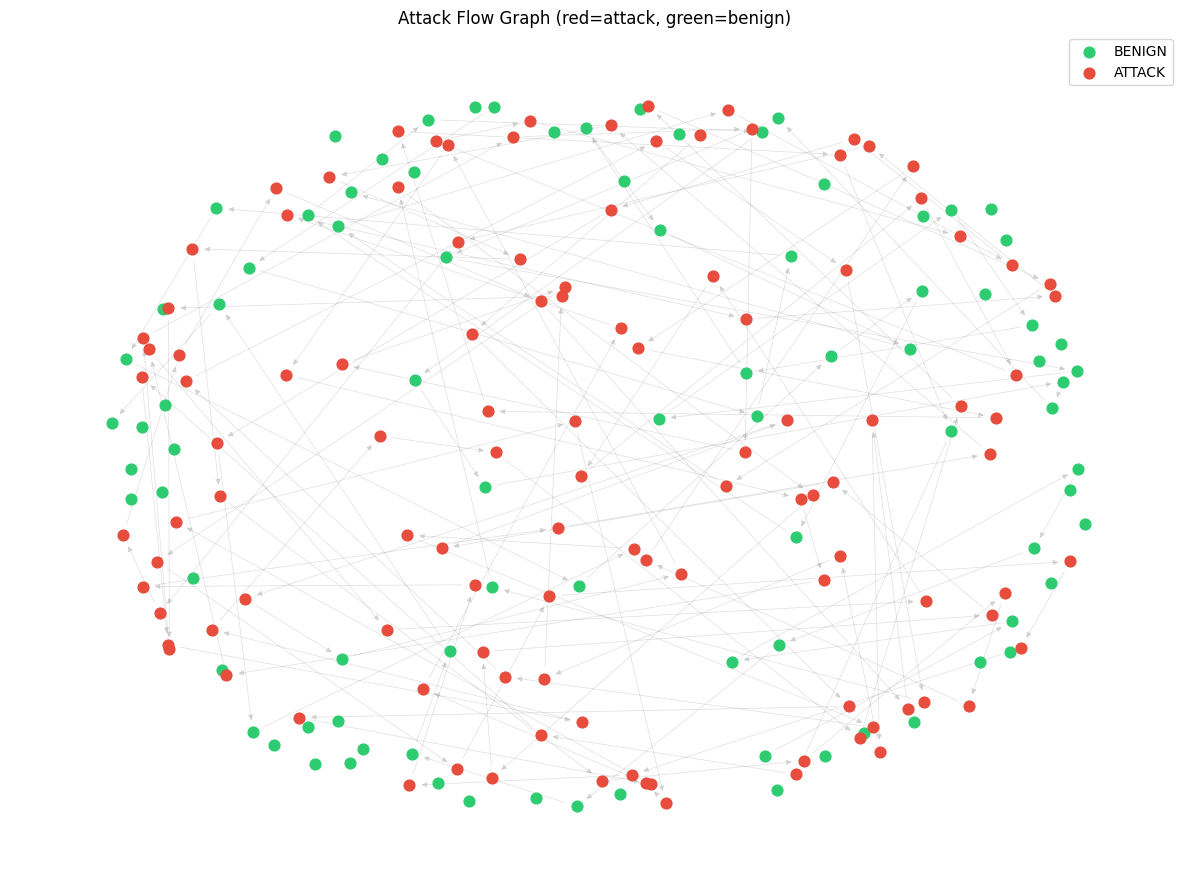

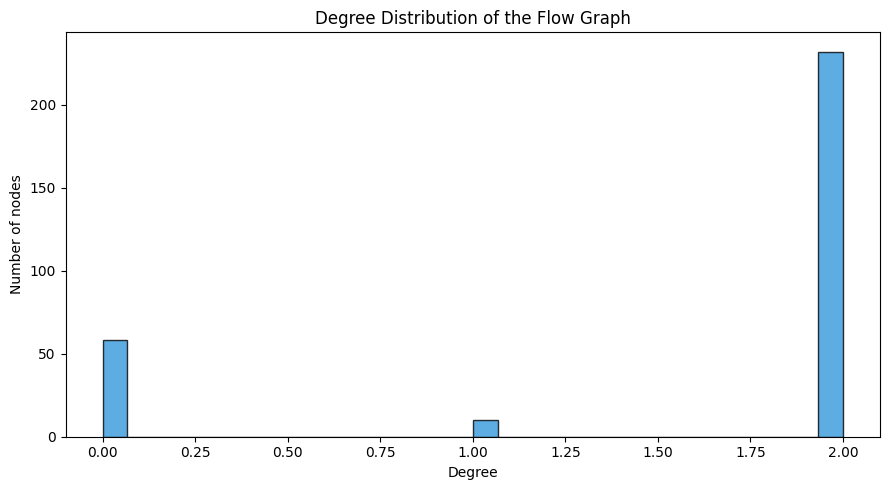

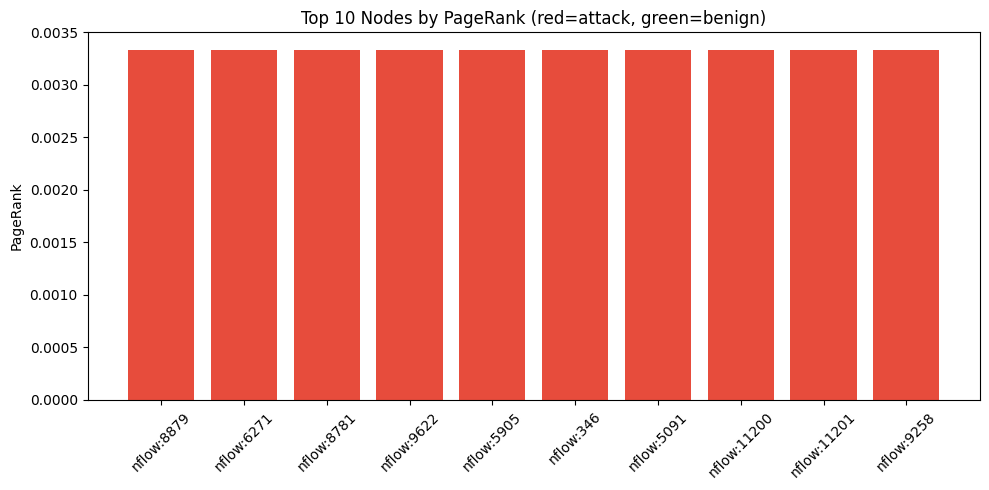

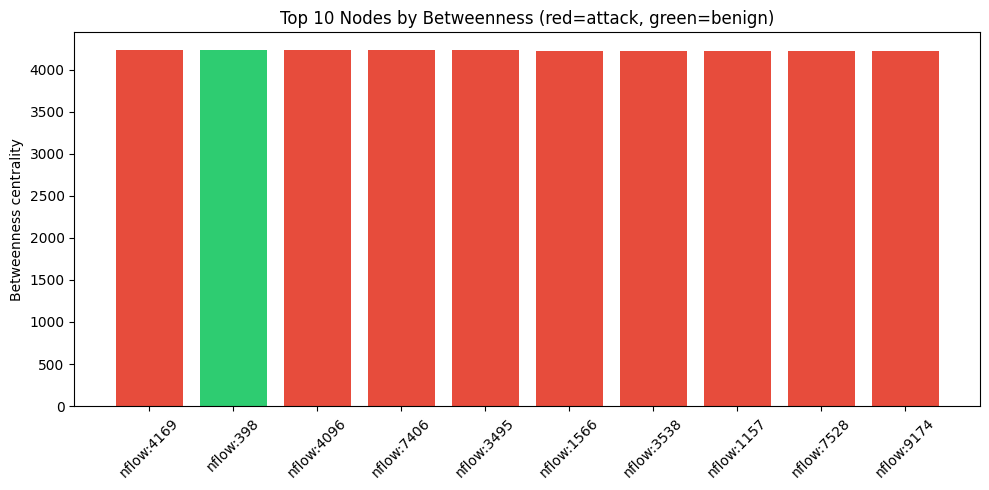

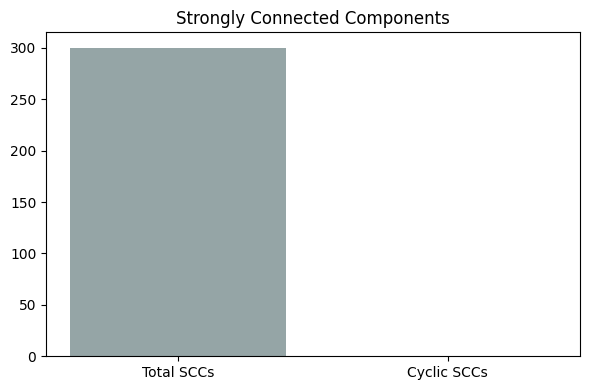

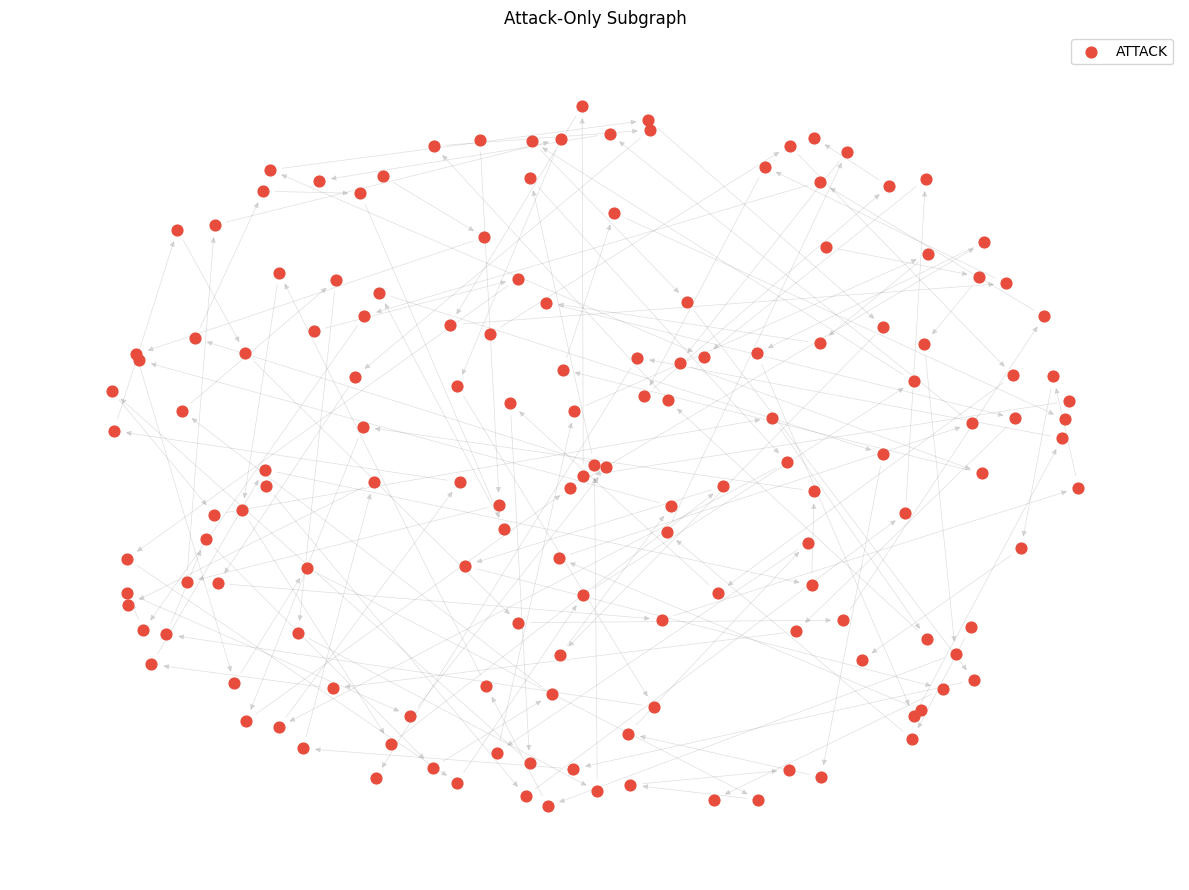

In [ ]:
# ============================================================
# GRAPH VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt

def draw_attack_graph(G, title="Attack Flow Graph", max_nodes=200):
    """Draw the flow graph with benign vs attack node coloring."""
    if len(G) == 0:
        print(f"[{title}] Graph is empty — nothing to draw.")
        return

    H = G
    if len(G) > max_nodes:
        nodes = list(G.nodes)[:max_nodes]
        H = G.subgraph(nodes).copy()

    pos = nx.spring_layout(H, seed=42, k=0.6)

    benign = [n for n in H if H.nodes[n].get('attack_label') == 0]
    attack = [n for n in H if H.nodes[n].get('attack_label') == 1]

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_edges(H, pos, alpha=0.25, arrows=True,
                           arrowsize=8, edge_color='gray', width=0.5)
    nx.draw_networkx_nodes(H, pos, nodelist=benign, node_color='#2ecc71',
                           node_size=60, label='BENIGN')
    nx.draw_networkx_nodes(H, pos, nodelist=attack, node_color='#e74c3c',
                           node_size=60, label='ATTACK')
    plt.title(title)
    plt.legend(scatterpoints=1)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def draw_pagerank_top(G, results, top_n=15):
    """Bar chart of top PageRank nodes."""
    top = list(results['pagerank']['top'].items())[:top_n]
    if not top:
        print("[PageRank] No nodes to plot.")
        return
    labels = [f"n{k}" for k, _ in top]
    values = [v for _, v in top]

    plt.figure(figsize=(10, 5))
    colors = ['#e74c3c' if G.nodes[k].get('attack_label') == 1 else '#2ecc71'
              for k, _ in top]
    plt.bar(labels, values, color=colors)
    plt.title(f"Top {len(top)} Nodes by PageRank (red=attack, green=benign)")
    plt.ylabel("PageRank")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def draw_betweenness_top(G, results, top_n=15):
    """Bar chart of top betweenness nodes."""
    top = list(results['betweenness']['top'].items())[:top_n]
    if not top:
        print("[Betweenness] No nodes to plot.")
        return
    labels = [f"n{k}" for k, _ in top]
    values = [v for _, v in top]

    plt.figure(figsize=(10, 5))
    colors = ['#e74c3c' if G.nodes[k].get('attack_label') == 1 else '#2ecc71'
              for k, _ in top]
    plt.bar(labels, values, color=colors)
    plt.title(f"Top {len(top)} Nodes by Betweenness (red=attack, green=benign)")
    plt.ylabel("Betweenness centrality")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def draw_degree_distribution(G):
    """Degree distribution (in + out) of the graph."""
    if len(G) == 0:
        print("[Degree] Empty graph.")
        return
    degrees = [d for _, d in G.degree()]
    plt.figure(figsize=(9, 5))
    plt.hist(degrees, bins=30, color='#3498db', edgecolor='black', alpha=0.8)
    plt.title("Degree Distribution of the Flow Graph")
    plt.xlabel("Degree")
    plt.ylabel("Number of nodes")
    plt.tight_layout()
    plt.show()


def draw_scc_sizes(results):
    """Bar chart of SCC sizes (visualizes cyclic communities)."""
    sizes = results['tarjan_scc'].get('all_sizes', None)
    if sizes is None:
        # Fall back: we only stored counts, so just show summary
        plt.figure(figsize=(6, 4))
        plt.bar(["Total SCCs", "Cyclic SCCs"],
                [results['tarjan_scc']['total_sccs'],
                 results['tarjan_scc']['cyclic_sccs']],
                color=['#95a5a6', '#e74c3c'])
        plt.title("Strongly Connected Components")
        plt.tight_layout()
        plt.show()
        return
    plt.figure(figsize=(9, 5))
    plt.hist(sizes, bins=20, color='#9b59b6', edgecolor='black')
    plt.title("SCC Size Distribution")
    plt.xlabel("SCC size")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


# --- Draw everything ---
draw_attack_graph(G, title="Attack Flow Graph (red=attack, green=benign)")
draw_degree_distribution(G)
draw_pagerank_top(G, results, top_n=15)
draw_betweenness_top(G, results, top_n=15)
draw_scc_sizes(results)

# A second, cleaner view: only the attack subgraph
attack_nodes = [n for n in G if G.nodes[n].get('attack_label') == 1]
if attack_nodes:
    G_attack = G.subgraph(attack_nodes).copy()
    draw_attack_graph(G_attack, title="Attack-Only Subgraph", max_nodes=150)
else:
    print("No attack nodes in the sampled graph — try increasing sample_size.")

Using CSV: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Rows: 11287
Label counts:
Label
DDoS      6493
BENIGN    4794
Name: count, dtype: int64

Graph built: 300 nodes, 35708 edges
  GRAPH ALGORITHMS — FULL RUN

[Graph Stats]
  Nodes:   300
  Edges:   35708
  Density: 0.398082

[BFS]  O(V + E)
  Reachable: 39
  First nodes: [0, 3, 9, 17, 21, 36, 42, 48, 60, 75]

[Dijkstra]  O((V+E) log V)
  node 0: dist=0.00
  node 3: dist=41422.00
  node 9: dist=41422.00
  node 17: dist=41422.00
  node 21: dist=41422.00

[A*]  O(E log V)
  no path

[Kahn Topo]  O(V + E)
  Is DAG: False

[Tarjan SCC]  O(V + E)
  Total SCCs: 63  Cyclic: 5

[Kruskal MST]  O(E log E)
  MST edges: 237

[PageRank]  O(k * E)
  node 1: 0.003333
  node 55: 0.003333
  node 277: 0.003333
  node 296: 0.003333
  node 0: 0.003333

[Betweenness]  O(V * E)
  node 0: 0.0000
  node 1: 0.0000
  node 2: 0.0000
  node 3: 0.0000
  node 4: 0.0000

[Union-Find]  O(α(n)) per op
  Zone count: 63

[DP Knapsack]  O(n * W)
  Max value (budget

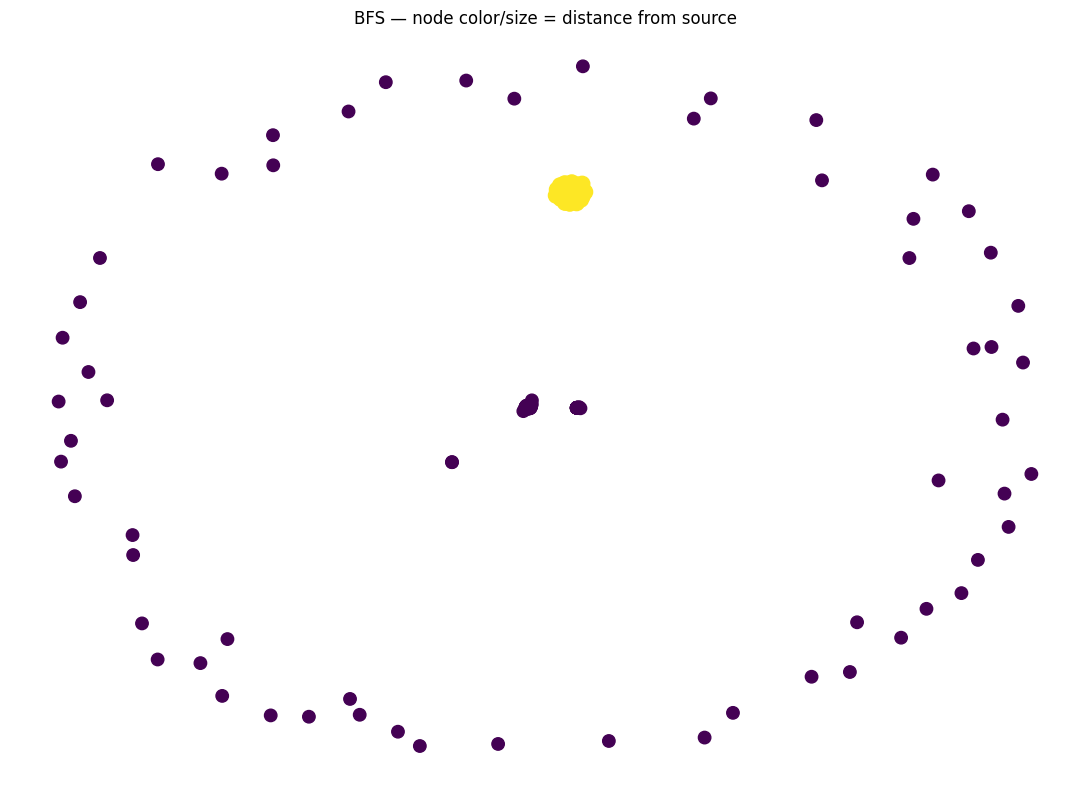

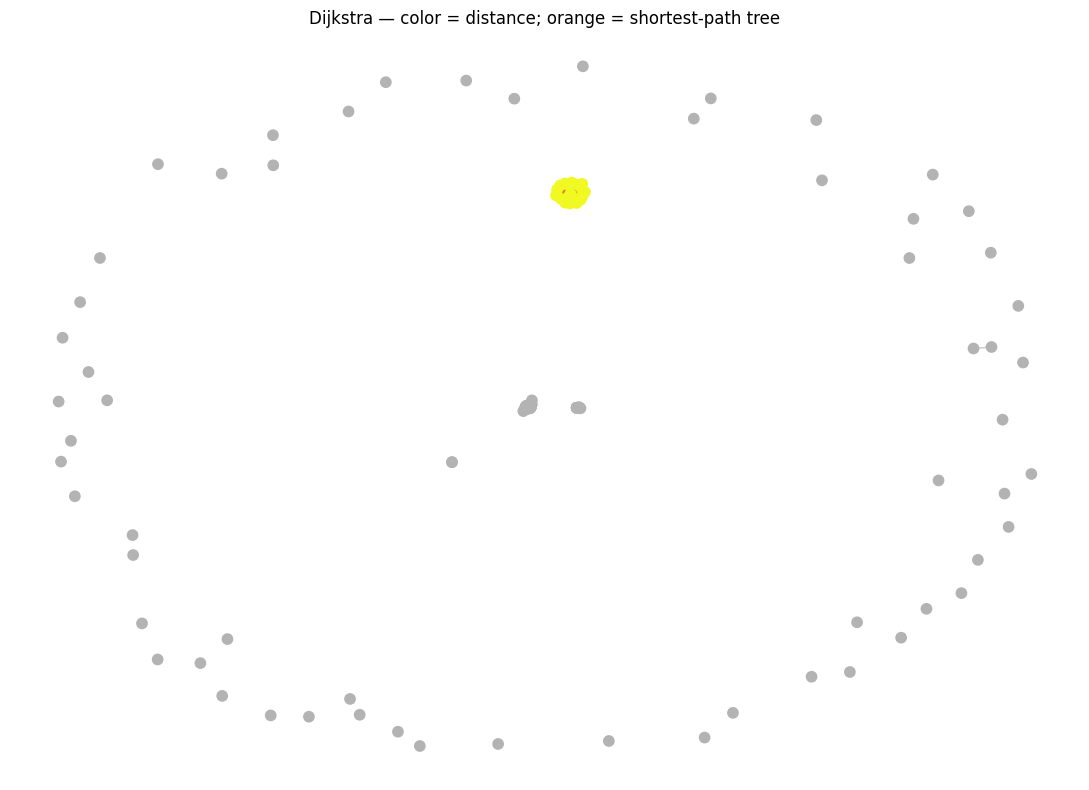

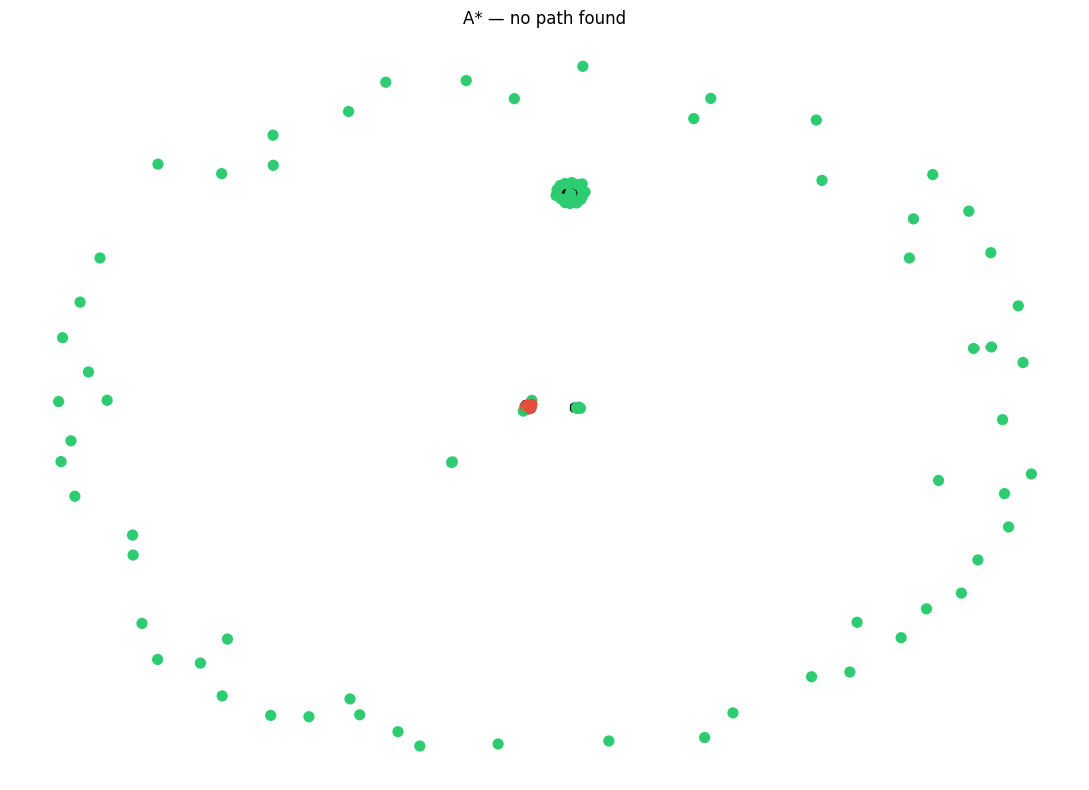

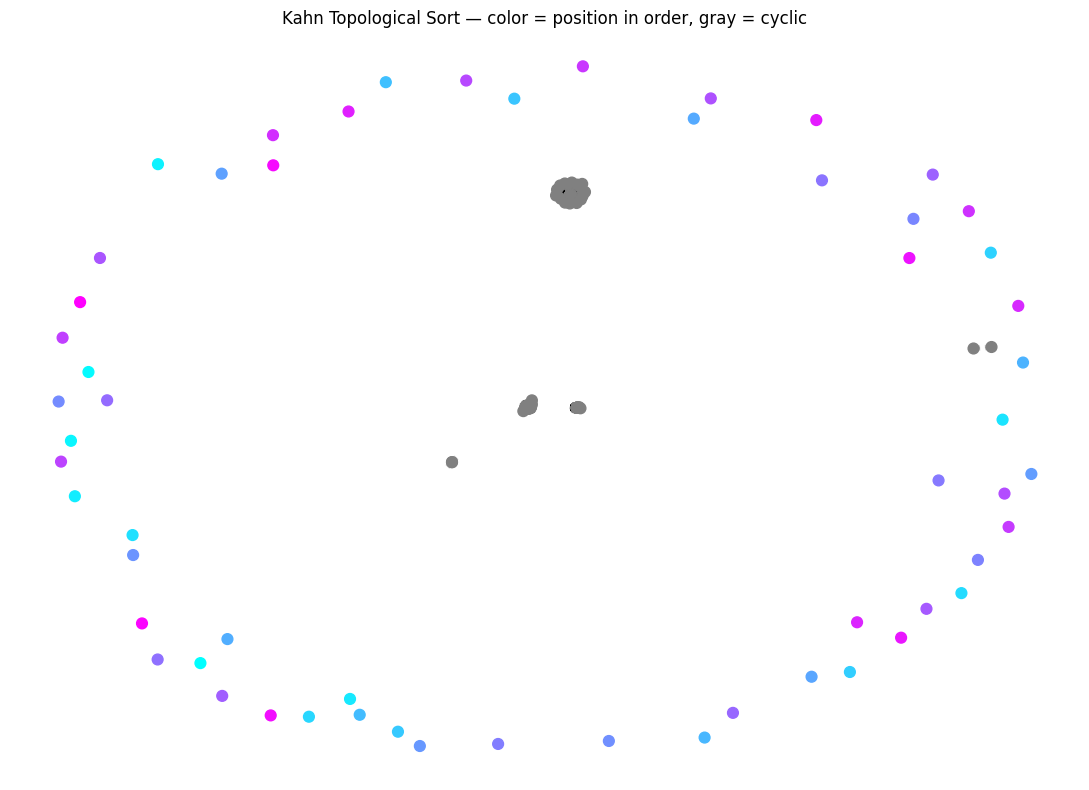

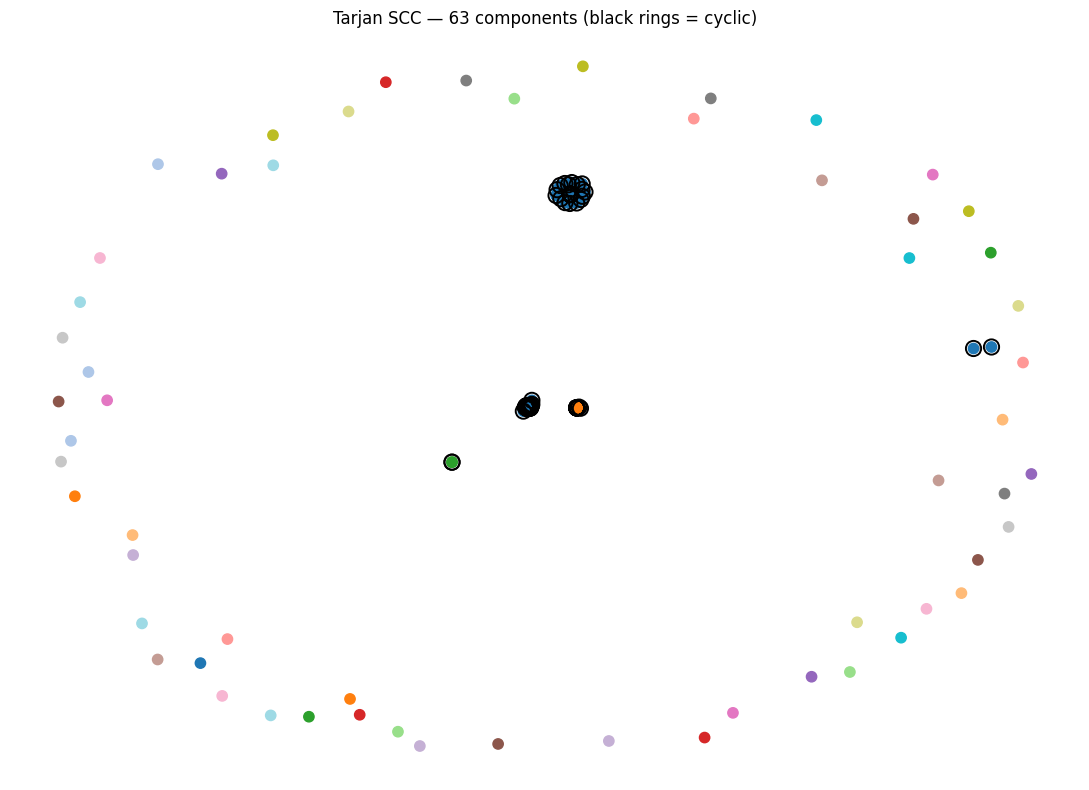

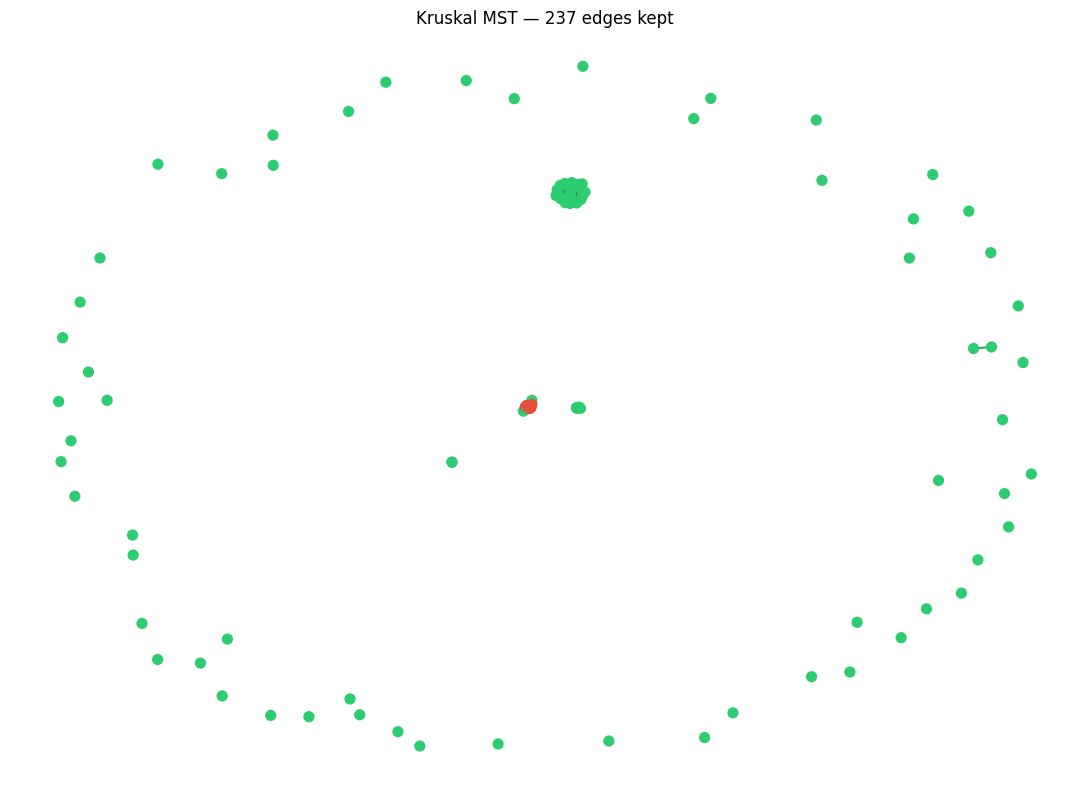

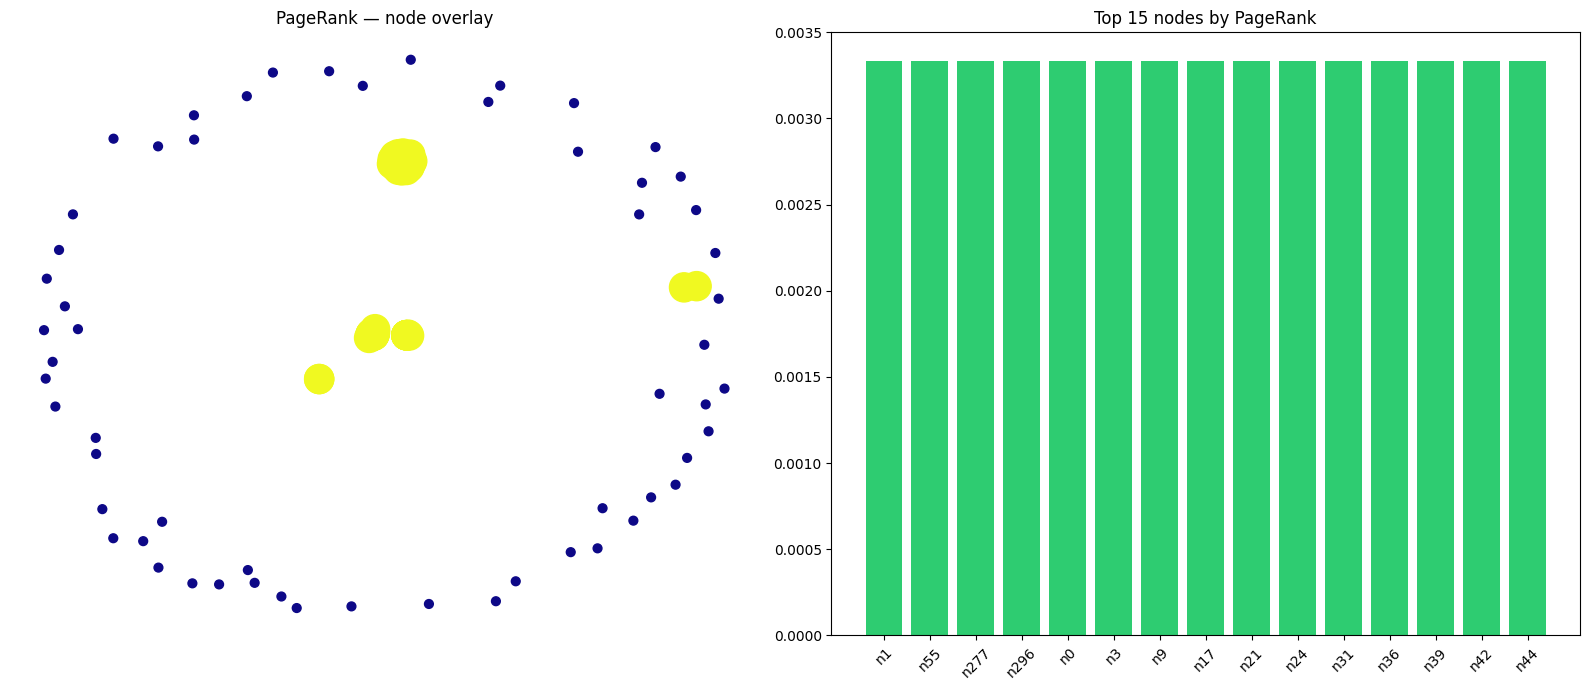

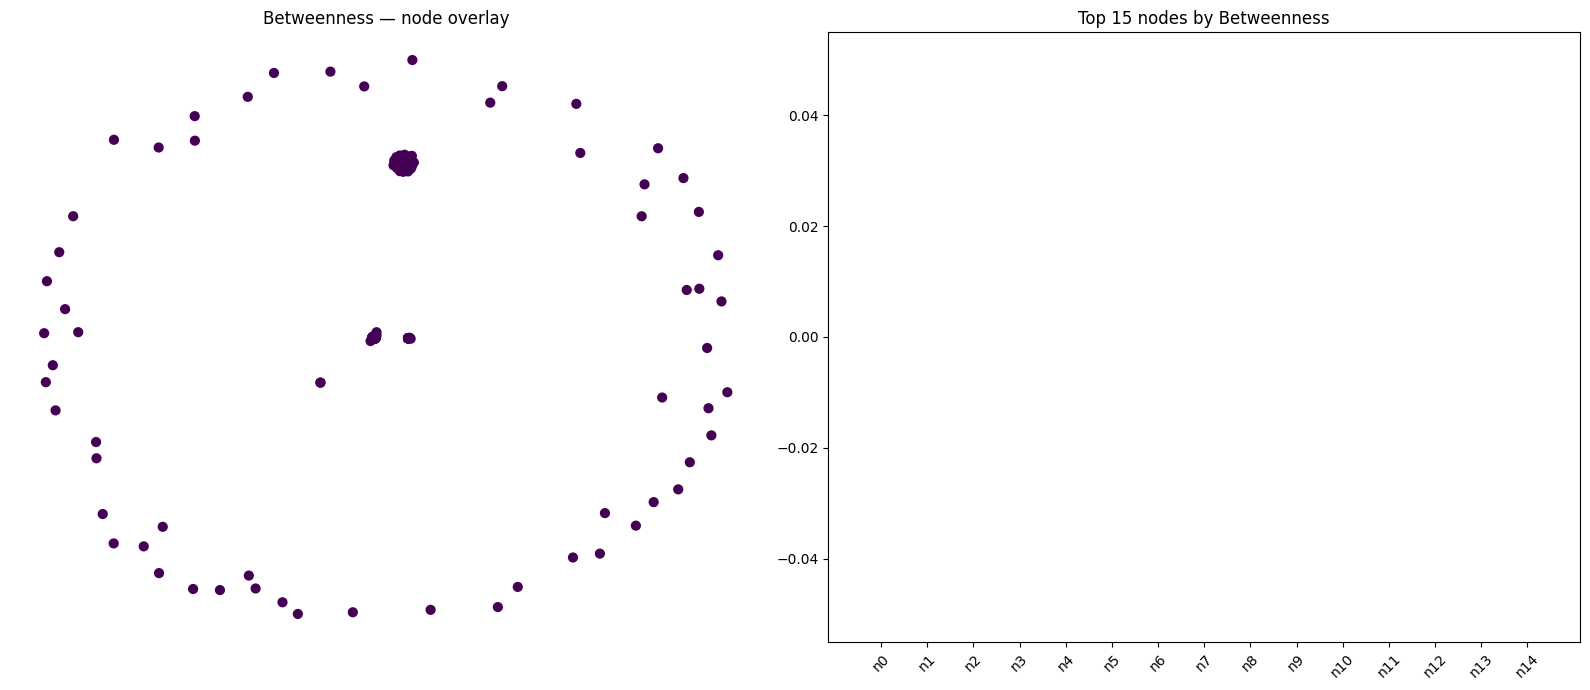

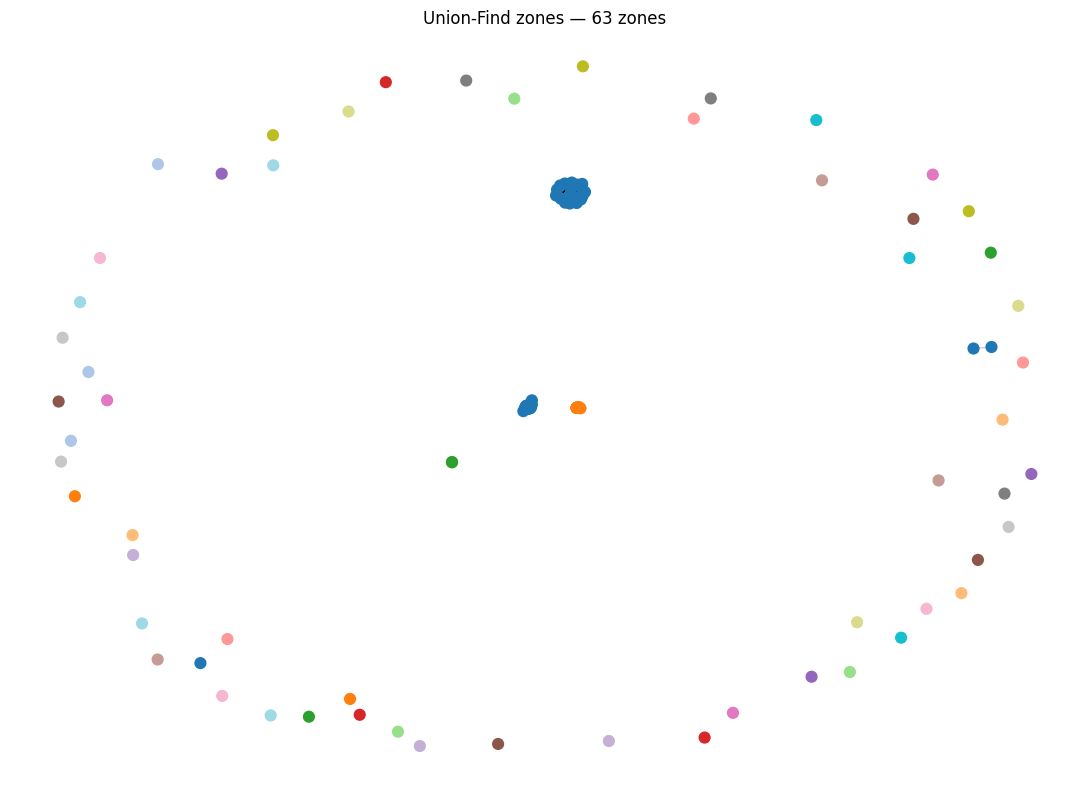

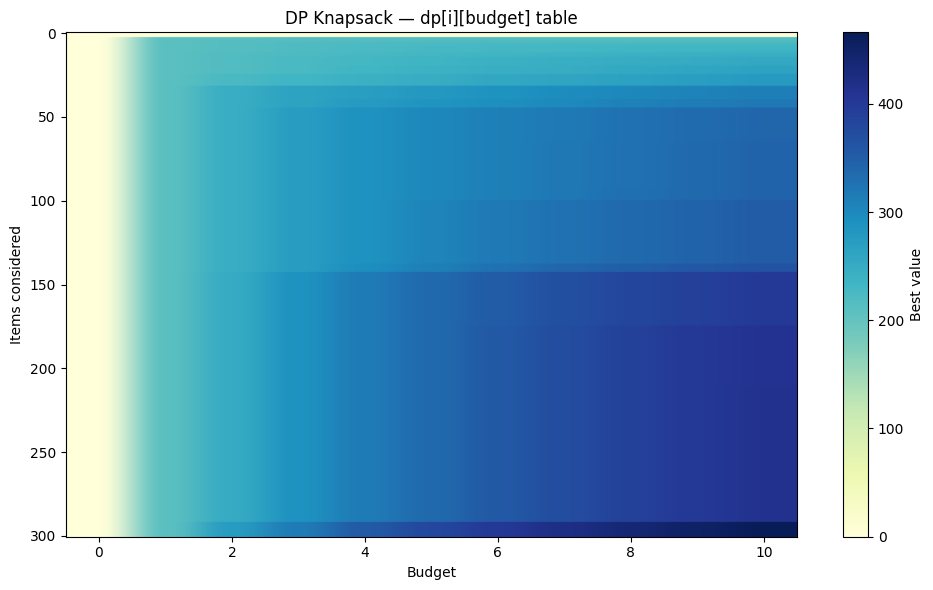

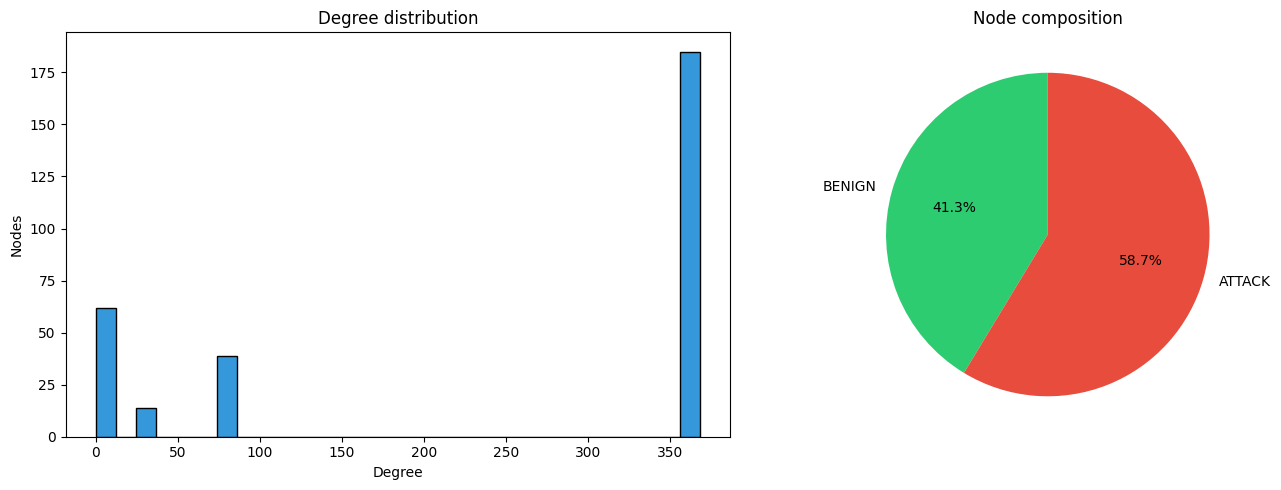


Done.


In [ ]:
# ============================================================
# ATTACK GRAPH ENGINE — ALL-IN-ONE
#   • Loads CICIDS2017 CSV
#   • Builds a directed attack-flow graph
#   • Runs every graph algorithm (BFS, Dijkstra, A*, Kahn,
#     Tarjan, Kruskal, PageRank, Betweenness, Union-Find,
#     DP Knapsack)
#   • Draws one figure per algorithm
# ============================================================

# -------------------- 0. Imports --------------------
from collections import deque, defaultdict
import math, heapq, os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ============================================================
# 1. LOAD DATA
# ============================================================
CSV_PATH = "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

# Try common locations if the plain filename isn't found
if not os.path.exists(CSV_PATH):
    candidates = [
        "/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
        "/content/drive/MyDrive/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
        "/content/drive/MyDrive/Colab Notebooks/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    ]
    for c in candidates:
        if os.path.exists(c):
            CSV_PATH = c
            break
    else:
        print("CSV not found. Looked in:")
        for c in [CSV_PATH] + candidates:
            print("   ", c)
        raise FileNotFoundError("Set CSV_PATH to the correct location.")

print("Using CSV:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()   # CICIDS has leading spaces in names

# Optional: subsample for speed
df = df.sample(frac=0.05, random_state=42).reset_index(drop=True)
print(f"Rows: {len(df)}")
print(f"Label counts:\n{df['Label'].value_counts()}")


# ============================================================
# 2. BUILD THE ATTACK FLOW GRAPH
# ============================================================
def build_flow_graph(df, sample_size=300, time_gap=1e9):
    """Nodes = flows; edges link flows sharing a dst port within time_gap."""
    df = df.sample(n=min(sample_size, len(df)), random_state=42).reset_index(drop=True)
    G = nx.DiGraph()

    for i, row in df.iterrows():
        label = 1 if str(row.get('Label', 'BENIGN')).strip() != 'BENIGN' else 0
        G.add_node(
            i,
            attack_label=label,
            fwd_packets=float(row.get('Total Fwd Packets', 1) or 1),
            duration=float(row.get('Flow Duration', 1) or 1),
            src_port=row.get('Source Port', row.get('Src Port', 0)),
            dst_port=row.get('Destination Port', row.get('Dst Port', 0)),
            protocol=row.get('Protocol', 0),
        )

    rows = df.to_dict('records')
    for i in range(len(rows)):
        for j in range(len(rows)):
            if i == j:
                continue
            a, b = rows[i], rows[j]
            same_port = (a.get('Destination Port', a.get('Dst Port')) ==
                         b.get('Destination Port', b.get('Dst Port')))
            try:
                close_t = abs(float(a.get('Flow Duration', 0) or 0) -
                              float(b.get('Flow Duration', 0) or 0)) < time_gap
            except (TypeError, ValueError):
                close_t = False
            if same_port and close_t:
                G.add_edge(i, j,
                           duration=float(a.get('Flow Duration', 1) or 1),
                           weight=float(a.get('Flow Duration', 1) or 1),
                           edge_type='same_port')
    return G


# ============================================================
# 3. THE ENGINE
# ============================================================
class AttackGraphEngine:
    """Every graph algorithm in one place, plus bookkeeping for plots."""

    def __init__(self, G):
        self.G = G
        self.bfs_layers = {}
        self.bfs_order = []
        self.dijkstra_dist = {}
        self.dijkstra_prev = {}
        self.astar_path = []
        self.astar_visited = set()
        self.topo_order = []
        self.is_dag = False
        self.sccs = []
        self.scc_id = {}
        self.mst_edges = []
        self.pagerank_scores = {}
        self.betweenness_scores = {}
        self.union_zones = {}
        self.zone_count = 0
        self.knapsack_dp = None

    # -------- BFS --------
    def bfs(self, start):
        visited, dist, order = {start}, {start: 0}, [start]
        q = deque([start])
        while q:
            u = q.popleft()
            for v in self.G.successors(u):
                if v not in visited:
                    visited.add(v); dist[v] = dist[u] + 1
                    order.append(v); q.append(v)
        self.bfs_layers = dist
        self.bfs_order = order
        return {"algorithm": "BFS", "reachable": len(order),
                "nodes": order[:10], "complexity": "O(V + E)"}

    # -------- Dijkstra --------
    def dijkstra(self, src):
        dist, prev = {src: 0}, {}
        pq = [(0, src)]
        visited = set()
        while pq:
            d, u = heapq.heappop(pq)
            if u in visited: continue
            visited.add(u)
            for v in self.G.successors(u):
                w = self.G[u][v].get('duration', 1.0)
                nd = d + w
                if nd < dist.get(v, math.inf):
                    dist[v] = nd; prev[v] = u
                    heapq.heappush(pq, (nd, v))
        self.dijkstra_dist = dist
        self.dijkstra_prev = prev
        top = sorted(dist.items(), key=lambda x: x[1])[:10]
        return {"algorithm": "Dijkstra", "top_10": dict(top),
                "complexity": "O((V+E) log V)"}

    # -------- A* --------
    def astar(self, src, dst):
        h = lambda n: 0 if self.G.nodes[n].get('attack_label') == 1 else 100
        open_set = [(h(src), 0, src)]
        came, gs = {}, {src: 0}
        visited = set()
        while open_set:
            _, g, cur = heapq.heappop(open_set)
            visited.add(cur)
            if cur == dst:
                path = [cur]
                while cur in came:
                    cur = came[cur]; path.append(cur)
                self.astar_path = path[::-1]
                self.astar_visited = visited
                return {"algorithm": "A*", "path": self.astar_path,
                        "cost": g, "complexity": "O(E log V)"}
            for v in self.G.successors(cur):
                w = self.G[cur][v].get('duration', 1.0)
                t = gs[cur] + w
                if t < gs.get(v, math.inf):
                    came[v] = cur; gs[v] = t
                    heapq.heappush(open_set, (t + h(v), t, v))
        self.astar_visited = visited
        return {"algorithm": "A*", "path": None, "error": "no path", "complexity": "O(E log V)"}

    # -------- Kahn Topological Sort --------
    def kahn_topo(self):
        indeg = {n: self.G.in_degree(n) for n in self.G}
        q = deque([n for n, d in indeg.items() if d == 0])
        order = []
        while q:
            u = q.popleft(); order.append(u)
            for v in self.G.successors(u):
                indeg[v] -= 1
                if indeg[v] == 0: q.append(v)
        self.topo_order = order
        self.is_dag = len(order) == len(self.G)
        return {"algorithm": "Kahn Topological Sort", "order": order[:10],
                "is_dag": self.is_dag, "complexity": "O(V + E)"}

    # -------- Tarjan SCC --------
    def tarjan_scc(self):
        idx = [0]; stack = []; on = set(); indices = {}; low = {}; sccs = []
        def strong(v):
            indices[v] = low[v] = idx[0]; idx[0] += 1
            stack.append(v); on.add(v)
            for w in self.G.successors(v):
                if w not in indices:
                    strong(w); low[v] = min(low[v], low[w])
                elif w in on:
                    low[v] = min(low[v], indices[w])
            if low[v] == indices[v]:
                comp = []
                while True:
                    w = stack.pop(); on.remove(w); comp.append(w)
                    if w == v: break
                sccs.append(comp)
        for n in self.G:
            if n not in indices:
                strong(n)
        self.sccs = sccs
        for i, comp in enumerate(sccs):
            for n in comp:
                self.scc_id[n] = i
        cyclic = [s for s in sccs if len(s) > 1]
        return {"algorithm": "Tarjan SCC", "total_sccs": len(sccs),
                "cyclic_sccs": len(cyclic), "complexity": "O(V + E)"}

    # -------- Kruskal MST --------
    def kruskal_mst(self):
        G_u = self.G.to_undirected()
        parent = {n: n for n in G_u}; rank = {n: 0 for n in G_u}
        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]; x = parent[x]
            return x
        def union(a, b):
            ra, rb = find(a), find(b)
            if ra == rb: return False
            if rank[ra] < rank[rb]: ra, rb = rb, ra
            parent[rb] = ra
            if rank[ra] == rank[rb]: rank[ra] += 1
            return True
        edges = sorted(G_u.edges(data=True),
                       key=lambda e: e[2].get('duration', 1.0))
        mst = []
        for u, v, d in edges:
            if union(u, v):
                mst.append((u, v))
        self.mst_edges = mst
        return {"algorithm": "Kruskal MST", "mst_edges": len(mst),
                "complexity": "O(E log E)"}

    # -------- PageRank --------
    def pagerank(self, d=0.85, iters=30):
        nodes = list(self.G.nodes); n = len(nodes)
        if n == 0: return {"algorithm": "PageRank", "top": {}}
        pr = {x: 1/n for x in nodes}
        for _ in range(iters):
            new = {x: (1-d)/n for x in nodes}
            for u in nodes:
                od = self.G.out_degree(u)
                if od == 0: continue
                sh = d * pr[u] / od
                for v in self.G.successors(u):
                    new[v] += sh
            pr = new
        self.pagerank_scores = pr
        top = dict(sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10])
        return {"algorithm": "PageRank", "top": top, "complexity": "O(k * E)"}

    # -------- Brandes Betweenness --------
    def betweenness(self):
        nodes = list(self.G.nodes); CB = {v: 0.0 for v in nodes}
        for s in nodes:
            S, P = [], {v: [] for v in nodes}
            sigma = {v: 0 for v in nodes}; sigma[s] = 1
            d = {v: -1 for v in nodes}; d[s] = 0
            Q = deque([s])
            while Q:
                v = Q.popleft(); S.append(v)
                for w in self.G.successors(v):
                    if d[w] < 0:
                        Q.append(w); d[w] = d[v] + 1
                    if d[w] == d[v] + 1:
                        sigma[w] += sigma[v]; P[w].append(v)
            delta = {v: 0.0 for v in nodes}
            while S:
                w = S.pop()
                for v in P[w]:
                    delta[v] += (sigma[v]/sigma[w]) * (1 + delta[w])
                if w != s: CB[w] += delta[w]
        for v in CB: CB[v] /= 2.0
        self.betweenness_scores = CB
        top = dict(sorted(CB.items(), key=lambda x: x[1], reverse=True)[:10])
        return {"algorithm": "Brandes Betweenness", "top": top,
                "complexity": "O(V * E)"}

    # -------- Union-Find Zones --------
    def union_find_zones(self):
        parent = {n: n for n in self.G}; rank = {n: 0 for n in self.G}
        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]; x = parent[x]
            return x
        def union(a, b):
            ra, rb = find(a), find(b)
            if ra == rb: return
            if rank[ra] < rank[rb]: ra, rb = rb, ra
            parent[rb] = ra
            if rank[ra] == rank[rb]: rank[ra] += 1
        for u, v, d in self.G.edges(data=True):
            if d.get("edge_type") == "same_port":
                union(u, v)
        zones = defaultdict(list)
        for n in self.G:
            zones[find(n)].append(n)
        self.union_zones = {n: find(n) for n in self.G}
        self.zone_count = len(zones)
        return {"algorithm": "Union-Find", "zone_count": self.zone_count,
                "complexity": "O(α(n)) per op"}

    # -------- DP Knapsack --------
    def dp_knapsack(self, budget=10):
        nodes = list(self.G.nodes)
        costs = [1] * len(nodes)
        values = [self.G.nodes[n].get("fwd_packets", 1) for n in nodes]
        n = len(nodes)
        dp = [[0] * (budget + 1) for _ in range(n + 1)]
        for i in range(1, n + 1):
            c, v = costs[i-1], values[i-1]
            for b in range(budget + 1):
                dp[i][b] = dp[i-1][b]
                if c <= b:
                    dp[i][b] = max(dp[i][b], dp[i-1][b-c] + v)
        self.knapsack_dp = dp
        return {"algorithm": "DP Knapsack", "max_value": dp[n][budget],
                "budget": budget, "complexity": "O(n * W)"}

    # -------- Run everything --------
    def run_all(self, src=None, dst=None):
        if src is None and len(self.G) > 0: src = list(self.G.nodes)[0]
        if dst is None and len(self.G) > 1: dst = list(self.G.nodes)[-1]
        return {
            "graph_stats": {"nodes": self.G.number_of_nodes(),
                            "edges": self.G.number_of_edges(),
                            "density": nx.density(self.G) if len(self.G) > 1 else 0},
            "bfs": self.bfs(src),
            "dijkstra": self.dijkstra(src),
            "astar": self.astar(src, dst),
            "kahn_topo": self.kahn_topo(),
            "tarjan_scc": self.tarjan_scc(),
            "kruskal_mst": self.kruskal_mst(),
            "pagerank": self.pagerank(),
            "betweenness": self.betweenness(),
            "union_find": self.union_find_zones(),
            "dp_knapsack": self.dp_knapsack(budget=10),
        }


# ============================================================
# 4. PLOT HELPERS
# ============================================================
_POS_CACHE = {}

def get_pos(G, seed=42):
    key = id(G)
    if key not in _POS_CACHE:
        _POS_CACHE[key] = nx.spring_layout(G, seed=seed, k=0.6)
    return _POS_CACHE[key]


def node_colors(G, nodes=None):
    nodes = nodes if nodes is not None else list(G.nodes)
    return ['#e74c3c' if G.nodes[n].get('attack_label') == 1 else '#2ecc71'
            for n in nodes]


# ============================================================
# 5. ONE PLOT PER ALGORITHM
# ============================================================
def plot_bfs(G, engine):
    pos = get_pos(G)
    layers = engine.bfs_layers
    if not layers:
        print("[BFS] no layers"); return
    max_layer = max(layers.values()) or 1
    cmap = cm.get_cmap('viridis', max_layer + 1)
    colors = [cmap(layers.get(n, 0)) for n in G.nodes]
    sizes = [80 + 40 * layers.get(n, 0) for n in G.nodes]
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.2, arrows=True, arrowsize=8)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes)
    plt.title("BFS — node color/size = distance from source")
    plt.axis('off'); plt.tight_layout(); plt.show()


def plot_dijkstra(G, engine):
    pos = get_pos(G)
    dist = engine.dijkstra_dist
    if not dist:
        print("[Dijkstra] no distances"); return
    vals = np.array([dist.get(n, np.nan) for n in G.nodes], dtype=float)
    finite = vals[np.isfinite(vals)]
    if finite.size == 0:
        print("[Dijkstra] no finite distances"); return
    norm = (vals - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + 1e-12)
    colors = [cm.plasma(v) if np.isfinite(v) else (0.7, 0.7, 0.7, 1) for v in norm]
    tree_edges = [(u, v) for v, u in engine.dijkstra_prev.items()]
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.1, arrows=False)
    nx.draw_networkx_edges(G, pos, edgelist=tree_edges, edge_color='#e67e22',
                           width=1.6, arrows=True, arrowsize=9)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=55)
    plt.title("Dijkstra — color = distance; orange = shortest-path tree")
    plt.axis('off'); plt.tight_layout(); plt.show()


def plot_astar(G, engine):
    pos = get_pos(G)
    path = engine.astar_path
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.15, arrows=True, arrowsize=8)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors(G), node_size=50)
    if path:
        path_edges = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                               edge_color='#e74c3c', width=2.5,
                               arrows=True, arrowsize=12)
        nx.draw_networkx_nodes(G, pos, nodelist=path,
                               node_color='#f1c40f', node_size=140,
                               edgecolors='black', linewidths=0.6)
    plt.title("A* — highlighted path" if path else "A* — no path found")
    plt.axis('off'); plt.tight_layout(); plt.show()


def plot_topo(G, engine):
    pos = get_pos(G)
    order = engine.topo_order
    if not order:
        print("[Topo] graph has a cycle, no full topological order"); return

    rank = {n: i for i, n in enumerate(order)}
    # Use a default color for nodes not in the topological order (part of a cycle)
    # The colormap length should be at least len(order) + 1 to accommodate a special 'cyclic' color index if desired.
    # For simplicity, directly assign 'gray' for cyclic nodes.

    colors = []
    for n in G.nodes:
        if n in rank:
            # Scale rank to colormap (cm.get_cmap('cool', len(order)) might be too small if a special index is used)
            # Here, we'll use a separate cmap for ordered nodes and a fixed color for cyclic ones.
            cmap_ordered = cm.get_cmap('cool', len(order) or 1) # Ensure cmap has at least 1 color if order is empty
            colors.append(cmap_ordered(rank[n]))
        else:
            colors.append('gray') # Color for nodes that are part of a cycle (not in topological order)

    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.15, arrows=True, arrowsize=8)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=60)
    plt.title("Kahn Topological Sort — color = position in order, gray = cyclic")
    plt.axis('off'); plt.tight_layout(); plt.show()


def plot_scc(G, engine):
    pos = get_pos(G)
    scc_id = engine.scc_id
    if not scc_id:
        print("[SCC] no SCCs"); return
    n_scc = max(scc_id.values()) + 1
    cmap = cm.get_cmap('tab20', n_scc)
    colors = [cmap(scc_id[n]) for n in G.nodes]
    cyclic_nodes = [n for comp in engine.sccs if len(comp) > 1 for n in comp]
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.15, arrows=True, arrowsize=8)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=55)
    if cyclic_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=cyclic_nodes,
                               node_color='none', edgecolors='black',
                               linewidths=1.4, node_size=120)
    plt.title(f"Tarjan SCC — {n_scc} components (black rings = cyclic)")
    plt.axis('off'); plt.tight_layout(); plt.show()


def plot_mst(G, engine):
    pos = get_pos(G)
    mst = engine.mst_edges
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.05, arrows=False)
    nx.draw_networkx_edges(G, pos, edgelist=mst,
                           edge_color='#27ae60', width=1.5, arrows=False)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors(G), node_size=50)
    plt.title(f"Kruskal MST — {len(mst)} edges kept")
    plt.axis('off'); plt.tight_layout(); plt.show()


def plot_pagerank(G, engine):
    pos = get_pos(G)
    pr = engine.pagerank_scores
    if not pr:
        print("[PageRank] empty"); return
    vals = np.array([pr[n] for n in G.nodes])
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-12)
    colors = [cm.plasma(v) for v in norm]
    sizes = [40 + 400 * v for v in norm]
    top = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:15]
    labels = [f"n{k}" for k, _ in top]
    bvals = [v for _, v in top]
    bcolors = ['#e74c3c' if G.nodes[k].get('attack_label') == 1 else '#2ecc71'
               for k, _ in top]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].set_title("PageRank — node overlay")
    nx.draw_networkx_edges(G, pos, ax=axes[0], alpha=0.1, arrows=False)
    nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color=colors, node_size=sizes)
    axes[0].axis('off')
    axes[1].bar(labels, bvals, color=bcolors)
    axes[1].set_title("Top 15 nodes by PageRank")
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()


def plot_betweenness(G, engine):
    pos = get_pos(G)
    cb = engine.betweenness_scores
    if not cb:
        print("[Betweenness] empty"); return
    vals = np.array([cb[n] for n in G.nodes])
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-12)
    colors = [cm.viridis(v) for v in norm]
    sizes = [40 + 400 * v for v in norm]
    top = sorted(cb.items(), key=lambda x: x[1], reverse=True)[:15]
    labels = [f"n{k}" for k, _ in top]
    bvals = [v for _, v in top]
    bcolors = ['#e74c3c' if G.nodes[k].get('attack_label') == 1 else '#2ecc71'
               for k, _ in top]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].set_title("Betweenness — node overlay")
    nx.draw_networkx_edges(G, pos, ax=axes[0], alpha=0.1, arrows=False)
    nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color=colors, node_size=sizes)
    axes[0].axis('off')
    axes[1].bar(labels, bvals, color=bcolors)
    axes[1].set_title("Top 15 nodes by Betweenness")
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()


def plot_union_find(G, engine):
    pos = get_pos(G)
    zones = engine.union_zones
    if not zones:
        print("[Union-Find] no zones"); return
    uniq = sorted(set(zones.values()))
    zid = {z: i for i, z in enumerate(uniq)}
    cmap = cm.get_cmap('tab20', max(len(uniq), 2))
    colors = [cmap(zid[zones[n]]) for n in G.nodes]
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.1, arrows=False)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=60)
    plt.title(f"Union-Find zones — {len(uniq)} zones")
    plt.axis('off'); plt.tight_layout(); plt.show()


def plot_knapsack(engine):
    dp = engine.knapsack_dp
    if dp is None:
        print("[Knapsack] no DP table"); return
    arr = np.array(dp, dtype=float)
    plt.figure(figsize=(10, 6))
    plt.imshow(arr, aspect='auto', cmap='YlGnBu')
    plt.colorbar(label='Best value')
    plt.title("DP Knapsack — dp[i][budget] table")
    plt.xlabel("Budget"); plt.ylabel("Items considered")
    plt.tight_layout(); plt.show()


def plot_degree_and_composition(G):
    degs = [d for _, d in G.degree()]
    benign = sum(1 for n in G if G.nodes[n].get('attack_label') == 0)
    attack = sum(1 for n in G if G.nodes[n].get('attack_label') == 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(degs, bins=30, color='#3498db', edgecolor='black')
    axes[0].set_title("Degree distribution")
    axes[0].set_xlabel("Degree"); axes[0].set_ylabel("Nodes")
    axes[1].pie([benign, attack], labels=['BENIGN', 'ATTACK'],
                colors=['#2ecc71', '#e74c3c'],
                autopct='%1.1f%%', startangle=90)
    axes[1].set_title("Node composition")
    plt.tight_layout(); plt.show()


# ============================================================
# 6. BUILD GRAPH, RUN ALGORITHMS, PRINT
# ============================================================
G = build_flow_graph(df, sample_size=300)
print(f"\nGraph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

engine = AttackGraphEngine(G)
results = engine.run_all()

print("=" * 70)
print("  GRAPH ALGORITHMS — FULL RUN")
print("=" * 70)

print(f"\n[Graph Stats]")
print(f"  Nodes:   {results['graph_stats']['nodes']}")
print(f"  Edges:   {results['graph_stats']['edges']}")
print(f"  Density: {results['graph_stats']['density']:.6f}")

print(f"\n[BFS]  {results['bfs']['complexity']}")
print(f"  Reachable: {results['bfs']['reachable']}")
print(f"  First nodes: {results['bfs']['nodes']}")

print(f"\n[Dijkstra]  {results['dijkstra']['complexity']}")
for k, v in list(results['dijkstra']['top_10'].items())[:5]:
    print(f"  node {k}: dist={v:.2f}")

print(f"\n[A*]  {results['astar'].get('complexity', 'N/A')}")
if results['astar'].get('path'):
    print(f"  Path len {len(results['astar']['path'])}  cost={results['astar']['cost']:.2f}")
else:
    print(f"  {results['astar'].get('error')}")

print(f"\n[Kahn Topo]  {results['kahn_topo']['complexity']}")
print(f"  Is DAG: {results['kahn_topo']['is_dag']}")

print(f"\n[Tarjan SCC]  {results['tarjan_scc']['complexity']}")
print(f"  Total SCCs: {results['tarjan_scc']['total_sccs']}  Cyclic: {results['tarjan_scc']['cyclic_sccs']}")

print(f"\n[Kruskal MST]  {results['kruskal_mst']['complexity']}")
print(f"  MST edges: {results['kruskal_mst']['mst_edges']}")

print(f"\n[PageRank]  {results['pagerank']['complexity']}")
for k, v in list(results['pagerank']['top'].items())[:5]:
    print(f"  node {k}: {v:.6f}")

print(f"\n[Betweenness]  {results['betweenness']['complexity']}")
for k, v in list(results['betweenness']['top'].items())[:5]:
    print(f"  node {k}: {v:.4f}")

print(f"\n[Union-Find]  {results['union_find']['complexity']}")
print(f"  Zone count: {results['union_find']['zone_count']}")

print(f"\n[DP Knapsack]  {results['dp_knapsack']['complexity']}")
print(f"  Max value (budget={results['dp_knapsack']['budget']}): {results['dp_knapsack']['max_value']}")


# ============================================================
# 7. DRAW ALL ALGORITHM FIGURES
# ============================================================
print("\nDrawing all algorithm graphs…\n")

plot_bfs(G, engine)
plot_dijkstra(G, engine)
plot_astar(G, engine)
plot_topo(G, engine)
plot_scc(G, engine)
plot_mst(G, engine)
plot_pagerank(G, engine)
plot_betweenness(G, engine)
plot_union_find(G, engine)
plot_knapsack(engine)
plot_degree_and_composition(G)

print("\nDone.")

In [ ]:
# ============================================================
# QUANTUM HASH CHAIN  (must run BEFORE the summary cell)
# ============================================================
import json
import hashlib
from datetime import datetime


class QuantumHashChain:
    """SHA-256 hash chain for tamper-evident event logging."""

    def __init__(self):
        self.chain = []
        self._genesis()

    def _hash(self, block):
        payload = (
            f"{block['index']}"
            f"{block['timestamp']}"
            f"{block['event']}"
            f"{block['prev_hash']}"
        ).encode()
        return hashlib.sha256(payload).hexdigest()

    def _genesis(self):
        block = {
            "index": 0,
            "timestamp": datetime.utcnow().isoformat(),
            "event": "GENESIS",
            "prev_hash": "0" * 64,
        }
        block["hash"] = self._hash(block)
        self.chain.append(block)

    def add_event(self, event: str):
        prev = self.chain[-1]
        block = {
            "index": len(self.chain),
            "timestamp": datetime.utcnow().isoformat(),
            "event": event,
            "prev_hash": prev["hash"],
        }
        block["hash"] = self._hash(block)
        self.chain.append(block)
        return block

    def verify(self):
        for i in range(1, len(self.chain)):
            cur, prev = self.chain[i], self.chain[i - 1]
            if cur["prev_hash"] != prev["hash"]:
                return {"total_events": len(self.chain),
                        "all_valid": False, "broken_at": i}
            if cur["hash"] != self._hash(cur):
                return {"total_events": len(self.chain),
                        "all_valid": False, "broken_at": i}
        return {"total_events": len(self.chain),
                "all_valid": True, "broken_at": None}


# ---- Instantiate the chain and log the pipeline events ----
qchain = QuantumHashChain()
qchain.add_event("DATASET_LOADED")
qchain.add_event("FEATURES_SELECTED")
qchain.add_event("QUANTUM_DETECTOR_TRAINED")
qchain.add_event("ATTACK_GRAPH_BUILT")
qchain.add_event("ALL_ALGORITHMS_RUN")
qchain.add_event("PIPELINE_COMPLETE")

# Sanity check
print("qchain ready:", qchain.verify())
if "attack_nodes" not in dir():
    attack_nodes = [n for n in G if G.nodes[n].get('attack_label') == 1]
if "benign_nodes" not in dir():
    benign_nodes = [n for n in G if G.nodes[n].get('attack_label') == 0]
print(f"attack_nodes={len(attack_nodes)}  benign_nodes={len(benign_nodes)}")

qchain ready: {'total_events': 7, 'all_valid': True, 'broken_at': None}
attack_nodes=176  benign_nodes=124


In [ ]:
import hashlib, json, uuid, math, re, io, base64, warnings, random
from datetime import datetime, timezone
from typing import Optional, List, Dict, Any, Tuple
from collections import defaultdict, OrderedDict, deque, Counter
import heapq

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
import torchvision.models as tv_models

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✓ Imports loaded")
print(f"  PyTorch  : {torch.__version__}")
print(f"  Device   : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU      : {torch.cuda.get_device_name(0)}")

In [ ]:
class NetworkAutoencoder(nn.Module):
    """
    Autoencoder for network flow anomaly detection.
    Trained on BENIGN flows only. DDoS flows have high reconstruction error.
    """
    def __init__(self, input_dim=20, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


print("=" * 70)
print("  DEEP LEARNING #1 — NETWORK ANOMALY AUTOENCODER")
print("=" * 70)

# Feature selection
ae_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Mean', 'Bwd IAT Mean', 'Packet Length Mean',
    'Average Packet Size', 'Down/Up Ratio',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
    'Active Mean', 'Idle Mean'
]

# Handle potential inf/NaN values before converting to float32 and scaling
X_ae_df = df[ae_features].copy() # Make a copy to avoid SettingWithCopyWarning
X_ae_df.replace([np.inf, -np.inf], np.nan, inplace=True)
X_ae_df.fillna(X_ae_df.mean(), inplace=True) # Fill NaN with column mean

X_ae = X_ae_df.values.astype(np.float32)
y_ae = (df['Label'] != 'BENIGN').astype(np.int64).values

# Split — train autoencoder on BENIGN only
benign_mask = y_ae == 0
X_benign = X_ae[benign_mask]

# Scale
scaler_ae = StandardScaler()
X_benign_scaled = scaler_ae.fit_transform(X_benign).astype(np.float32)

X_ae_scaled = scaler_ae.transform(X_ae).astype(np.float32)

# Split BENIGN into train/val
X_ae_train, X_ae_val = train_test_split(
    X_benign_scaled, test_size=0.2, random_state=42
)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_ae_train)),
    batch_size=512, shuffle=True
)
val_tensor = torch.from_numpy(X_ae_val).to(DEVICE)

print(f"\n[Data]")
print(f"  Total flows      : {len(X_ae)}")
print(f"  BENIGN (train)   : {len(X_ae_train)}")
print(f"  BENIGN (val)     : {len(X_ae_val)}")
print(f"  Features         : {len(ae_features)}")

# Train
ae_model = NetworkAutoencoder(input_dim=len(ae_features), latent_dim=8).to(DEVICE)
optimizer = optim.Adam(ae_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

EPOCHS = 10
history = {"train_loss": [], "val_loss": []}

print(f"\n[Training]")
for epoch in range(EPOCHS):
    ae_model.train()
    total_loss = 0
    for (batch,) in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        recon, _ = ae_model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.size(0)
    train_loss = total_loss / len(X_ae_train)

    ae_model.eval()
    with torch.no_grad():
        recon_val, _ = ae_model(val_tensor)
        val_loss = criterion(recon_val, val_tensor).item()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"  Epoch {epoch+1:2d}/{EPOCHS}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}")

# Compute threshold from validation reconstruction errors
ae_model.eval()
with torch.no_grad():
    recon_val, _ = ae_model(val_tensor)
    val_errors = torch.mean((recon_val - val_tensor) ** 2, dim=1).cpu().numpy()
threshold = np.percentile(val_errors, 99)  # 99th percentile as anomaly threshold

print(f"\n[Threshold] {threshold:.6f} (99th percentile of BENIGN reconstruction error)")

# Evaluate on full dataset
X_all_tensor = torch.from_numpy(X_ae_scaled).to(DEVICE)
with torch.no_grad():
    recon_all, _ = ae_model(X_all_tensor)
    all_errors = torch.mean((recon_all - X_all_tensor) ** 2, dim=1).cpu().numpy()

ae_preds = (all_errors > threshold).astype(int)
ae_acc = (ae_preds == y_ae).mean()

print(f"\n[Evaluation]")
print(f"  Accuracy  : {ae_acc:.4f}")
print(f"  Report:")
print(classification_report(y_ae, ae_preds, target_names=['BENIGN', 'DDoS']))

  DEEP LEARNING #1 — NETWORK ANOMALY AUTOENCODER

[Data]
  Total flows      : 11287
  BENIGN (train)   : 3835
  BENIGN (val)     : 959
  Features         : 20

[Training]
  Epoch  1/10  train_loss=1.096311  val_loss=1.056321
  Epoch  2/10  train_loss=0.942237  val_loss=1.030587
  Epoch  3/10  train_loss=0.838652  val_loss=0.938777
  Epoch  4/10  train_loss=0.765509  val_loss=0.795164
  Epoch  5/10  train_loss=0.704279  val_loss=0.676022
  Epoch  6/10  train_loss=0.645464  val_loss=0.591476
  Epoch  7/10  train_loss=0.589575  val_loss=0.532698
  Epoch  8/10  train_loss=0.549738  val_loss=0.480223
  Epoch  9/10  train_loss=0.512679  val_loss=0.437602
  Epoch 10/10  train_loss=0.482482  val_loss=0.403497

[Threshold] 5.066066 (99th percentile of BENIGN reconstruction error)

[Evaluation]
  Accuracy  : 0.4291
  Report:
              precision    recall  f1-score   support

      BENIGN       0.43      0.99      0.60      4794
        DDoS       0.71      0.01      0.02      6493

    accur

In [ ]:
class IncidentTextClassifier(nn.Module):
    """
    BiLSTM with attention pooling for incident description classification.
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=96,
                 num_classes=5, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            bidirectional=True, batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, mask=None):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)                        # (B, T, 2H)
        attn_scores = self.attention(out).squeeze(-1)  # (B, T)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(attn_scores, dim=1)
        pooled = torch.bmm(attn_weights.unsqueeze(1), out).squeeze(1)
        return self.fc(self.dropout(pooled)), attn_weights


print("=" * 70)
print("  DEEP LEARNING #2 — INCIDENT TEXT CLASSIFIER (BiLSTM + Attention)")
print("=" * 70)

# Synthetic incident corpus with 5 classes
INCIDENT_CLASSES = ["ransomware", "ddos", "phishing", "data_exfiltration", "unauthorized_access"]
LABEL_TO_IDX = {c: i for i, c in enumerate(INCIDENT_CLASSES)}

INCIDENT_CORPUS = [
    # ransomware
    "ransomware encrypted all files on the file server",
    "user reports files locked with ransom note requesting bitcoin",
    "crypto locker detected on shared drive with .locked extensions",
    "host encrypted by ransomware gang demanding payment",
    "file server shows encrypted extensions and ransom txt files",
    # ddos
    "ddos flood attacking web server port 80 with high packet rate",
    "volumetric ddos traffic spike observed on edge router",
    "syn flood targeting https endpoint causing service outage",
    "traffic amplification attack against public dns server",
    "high rate packet flood saturating network interface",
    # phishing
    "phishing email with malicious link sent to finance team",
    "credential harvesting page impersonating bank login",
    "spear phishing targeting executive with attachment",
    "user clicked spoofed invoice link in email",
    "suspicious login page mimicking internal portal",
    # data exfiltration
    "large outbound transfer to unknown cloud storage",
    "customer database exfiltrated to external ftp server",
    "unusual data volume uploaded to dropbox by employee",
    "sensitive pii leaked to external domain",
    "database dump sent to attacker c2 channel",
    # unauthorized access
    "unauthorized login from foreign ip address",
    "brute force attempt against admin account",
    "impossible travel detected for user session",
    "privilege escalation via exploited service",
    "lateral movement detected between internal hosts",
]

CORPUS_LABELS = (
    ["ransomware"] * 5 +
    ["ddos"] * 5 +
    ["phishing"] * 5 +
    ["data_exfiltration"] * 5 +
    ["unauthorized_access"] * 5
)

# Simple tokenizer
def tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())

# Build vocab
vocab = {"<pad>": 0, "<unk>": 1}
for text in INCIDENT_CORPUS:
    for tok in tokenize(text):
        if tok not in vocab:
            vocab[tok] = len(vocab)

def encode(text, max_len=16):
    toks = tokenize(text)[:max_len]
    ids = [vocab.get(t, 1) for t in toks]
    ids += [0] * (max_len - len(ids))
    return ids

X_text = np.array([encode(t) for t in INCIDENT_CORPUS], dtype=np.int64)
y_text = np.array([LABEL_TO_IDX[l] for l in CORPUS_LABELS], dtype=np.int64)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_text, y_text, test_size=0.3, random_state=42, stratify=y_text
)

train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
test_ds = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8)

print(f"\n[Data]")
print(f"  Vocab size : {len(vocab)}")
print(f"  Classes    : {len(INCIDENT_CLASSES)}")
print(f"  Train      : {len(X_tr)}  |  Test: {len(X_te)}")

text_model = IncidentTextClassifier(
    vocab_size=len(vocab), embed_dim=32, hidden_dim=48,
    num_classes=len(INCIDENT_CLASSES), num_layers=2
).to(DEVICE)

opt = optim.Adam(text_model.parameters(), lr=3e-3)
crit = nn.CrossEntropyLoss()

print(f"\n[Training]")
for epoch in range(25):
    text_model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        logits, _ = text_model(xb)
        loss = crit(logits, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item() * xb.size(0)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:2d}  loss={total_loss/len(X_tr):.4f}")

# Evaluate
text_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits, _ = text_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

text_acc = (np.array(all_preds) == np.array(all_true)).mean()
print(f"\n[Evaluation]")
print(f"  Accuracy: {text_acc:.4f}")

print(f"\n[Sample predictions]")
for i in range(min(8, len(X_te))):
    inp = " ".join([t for t, _ in zip(tokenize(" ".join(INCIDENT_CORPUS)), [])]) if False else ""
    true_lbl = INCIDENT_CLASSES[all_true[i]]
    pred_lbl = INCIDENT_CLASSES[all_preds[i]]
    print(f"  true={true_lbl:<22} pred={pred_lbl:<22} {'✓' if true_lbl == pred_lbl else '✗'}")

  DEEP LEARNING #2 — INCIDENT TEXT CLASSIFIER (BiLSTM + Attention)

[Data]
  Vocab size : 134
  Classes    : 5
  Train      : 17  |  Test: 8

[Training]
  Epoch  5  loss=1.4142
  Epoch 10  loss=0.1240
  Epoch 15  loss=0.0113
  Epoch 20  loss=0.0040
  Epoch 25  loss=0.0036

[Evaluation]
  Accuracy: 0.7500

[Sample predictions]
  true=ddos                   pred=ransomware             ✗
  true=unauthorized_access    pred=ransomware             ✗
  true=data_exfiltration      pred=data_exfiltration      ✓
  true=phishing               pred=phishing               ✓
  true=ransomware             pred=ransomware             ✓
  true=ransomware             pred=ransomware             ✓
  true=phishing               pred=phishing               ✓
  true=data_exfiltration      pred=data_exfiltration      ✓


In [ ]:
import cv2 # Added for cv2.rectangle

class PhishingCNN(nn.Module):
    """Small CNN for phishing screenshot classification."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


print("=" * 70)
print("  DEEP LEARNING #3 — PHISHING SCREENSHOT CNN")
print("=" * 70)


def make_phishing_image():
    """Synthetic phishing login page."""
    img = np.full((128, 128, 3), 250, dtype=np.uint8)
    # Red warning banner
    cv2.rectangle(img, (0, 10), (128, 30), (30, 30, 200), -1)
    # Login form box
    cv2.rectangle(img, (20, 50), (108, 90), (220, 220, 220), -1)
    cv2.rectangle(img, (20, 50), (108, 90), (100, 100, 100), 1)
    # Button
    cv2.rectangle(img, (35, 95), (95, 115), (60, 120, 220), -1)
    # Random noise
    img = np.clip(img.astype(np.int16) + np.random.randint(-10, 10, img.shape), 0, 255).astype(np.uint8)
    return img


def make_benign_image():
    """Synthetic benign webpage."""
    img = np.full((128, 128, 3), 240, dtype=np.uint8)
    # Header
    cv2.rectangle(img, (0, 5), (128, 20), (200, 200, 200), -1)
    # Content blocks
    for y in range(30, 100, 20):
        cv2.rectangle(img, (10, y), (110, y + 12), (230, 230, 230), -1)
    img = np.clip(img.astype(np.int16) + np.random.randint(-8, 8, img.shape), 0, 255).astype(np.uint8)
    return img


# Generate dataset
N_PER_CLASS = 200
imgs, labels = [], []
for _ in range(N_PER_CLASS):
    imgs.append(make_phishing_image()); labels.append(1)
    imgs.append(make_benign_image()); labels.append(0)

X_img = np.stack(imgs).astype(np.float32) / 255.0  # (N, 128, 128, 3)
X_img = np.transpose(X_img, (0, 3, 1, 2))          # (N, 3, 128, 128)
y_img = np.array(labels, dtype=np.int64)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_img, y_img, test_size=0.2, random_state=42, stratify=y_img
)

train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
test_ds = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

print(f"\n[Data]")
print(f"  Images   : {len(X_img)}")
print(f"  Train    : {len(X_tr)}  |  Test: {len(X_te)}")
print(f"  Shape    : {X_img.shape[1:]}")

cnn_model = PhishingCNN(num_classes=2).to(DEVICE)
opt = optim.Adam(cnn_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

print(f"\n[Training]")
for epoch in range(8):
    cnn_model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        logits = cnn_model(xb)
        loss = crit(logits, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    print(f"  Epoch {epoch+1}  loss={total_loss/len(X_tr):.4f}  train_acc={correct/total:.4f}")

cnn_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        preds = cnn_model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

cnn_acc = (np.array(all_preds) == np.array(all_true)).mean()
print(f"\n[Evaluation]")
print(f"  Test Accuracy: {cnn_acc:.4f}")
print(classification_report(all_true, all_preds, target_names=['benign', 'phishing']))

  DEEP LEARNING #3 — PHISHING SCREENSHOT CNN

[Data]
  Images   : 400
  Train    : 320  |  Test: 80
  Shape    : (3, 128, 128)

[Training]
  Epoch 1  loss=0.3988  train_acc=0.9156
  Epoch 2  loss=0.1107  train_acc=1.0000
  Epoch 3  loss=0.0203  train_acc=1.0000
  Epoch 4  loss=0.0066  train_acc=1.0000
  Epoch 5  loss=0.0029  train_acc=1.0000
  Epoch 6  loss=0.0018  train_acc=1.0000
  Epoch 7  loss=0.0011  train_acc=1.0000
  Epoch 8  loss=0.0010  train_acc=1.0000

[Evaluation]
  Test Accuracy: 1.0000
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00        40
    phishing       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [ ]:
class MultimodalFusionNet(nn.Module):
    """
    Fuses three signal streams into a single incident severity classifier.
    Inputs: (network_anomaly_score, text_class_probs[5], image_class_probs[2])
    Output: severity class (low / medium / high / critical)
    """
    def __init__(self, net_dim=1, text_dim=5, img_dim=2, hidden=32, num_severity=4):
        super().__init__()
        self.net_encoder = nn.Sequential(nn.Linear(net_dim, 16), nn.ReLU())
        self.text_encoder = nn.Sequential(nn.Linear(text_dim, 16), nn.ReLU())
        self.img_encoder = nn.Sequential(nn.Linear(img_dim, 8), nn.ReLU())
        fused_dim = 16 + 16 + 8
        self.attention = nn.MultiheadAttention(
            embed_dim=fused_dim, num_heads=4, batch_first=True, dropout=0.2
        )
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, num_severity)
        )

    def forward(self, net, text, img):
        e_net = self.net_encoder(net)
        e_text = self.text_encoder(text)
        e_img = self.img_encoder(img)
        fused = torch.cat([e_net, e_text, e_img], dim=1)  # (B, fused_dim)
        tokens = fused.unsqueeze(1)                        # (B, 1, fused_dim)
        attn_out, attn_weights = self.attention(tokens, tokens, tokens)
        pooled = attn_out.squeeze(1)
        return self.classifier(pooled), attn_weights


print("=" * 70)
print("  DEEP LEARNING #4 — MULTIMODAL ATTENTION FUSION")
print("=" * 70)

# Build fusion training data
# For each incident scenario, combine the three signal streams
SEVERITY_CLASSES = ["low", "medium", "high", "critical"]

# Synthetic fusion dataset
N_FUSION = 2000
fusion_net_scores = np.random.beta(2, 5, N_FUSION).astype(np.float32).reshape(-1, 1)
fusion_text_probs = np.random.dirichlet([1]*5, N_FUSION).astype(np.float32)
fusion_img_probs  = np.random.dirichlet([1]*2, N_FUSION).astype(np.float32)

# Heuristic severity for training (real system would use labeled incidents)
def compute_severity(net_s, text_p, img_p):
    score = net_s[0] * 0.4 + text_p.max() * 0.3 + img_p[1] * 0.3
    if score < 0.3:   return 0
    elif score < 0.5: return 1
    elif score < 0.7: return 2
    else:             return 3

fusion_y = np.array([compute_severity(n, t, i)
                     for n, t, i in zip(fusion_net_scores, fusion_text_probs, fusion_img_probs)],
                    dtype=np.int64)

X_net_tr, X_net_te, X_txt_tr, X_txt_te, X_img_tr, X_img_te, y_tr, y_te = train_test_split(
    fusion_net_scores, fusion_text_probs, fusion_img_probs, fusion_y,
    test_size=0.2, random_state=42, stratify=fusion_y
)

fusion_model = MultimodalFusionNet().to(DEVICE)
opt = optim.Adam(fusion_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

print(f"\n[Data]")
print(f"  Train: {len(y_tr)}  |  Test: {len(y_te)}")
print(f"  Severity classes: {SEVERITY_CLASSES}")

print(f"\n[Training]")
for epoch in range(30):
    fusion_model.train()
    opt.zero_grad()
    out, _ = fusion_model(
        torch.from_numpy(X_net_tr).to(DEVICE),
        torch.from_numpy(X_txt_tr).to(DEVICE),
        torch.from_numpy(X_img_tr).to(DEVICE)
    )
    loss = crit(out, torch.from_numpy(y_tr).to(DEVICE))
    loss.backward()
    opt.step()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:2d}  loss={loss.item():.4f}")

fusion_model.eval()
with torch.no_grad():
    out, attn = fusion_model(
        torch.from_numpy(X_net_te).to(DEVICE),
        torch.from_numpy(X_txt_te).to(DEVICE),
        torch.from_numpy(X_img_te).to(DEVICE)
    )
    preds = out.argmax(1).cpu().numpy()

fusion_acc = (preds == y_te).mean()
print(f"\n[Evaluation]")
print(f"  Test Accuracy: {fusion_acc:.4f}")
print(classification_report(y_te, preds, target_names=SEVERITY_CLASSES, labels=np.unique(y_te)))

  DEEP LEARNING #4 — MULTIMODAL ATTENTION FUSION

[Data]
  Train: 1600  |  Test: 400
  Severity classes: ['low', 'medium', 'high', 'critical']

[Training]
  Epoch  5  loss=1.3245
  Epoch 10  loss=1.2608
  Epoch 15  loss=1.1924
  Epoch 20  loss=1.1217
  Epoch 25  loss=1.0692
  Epoch 30  loss=1.0498

[Evaluation]
  Test Accuracy: 0.6075
              precision    recall  f1-score   support

         low       0.00      0.00      0.00        77
      medium       0.61      1.00      0.76       243
        high       0.00      0.00      0.00        79
    critical       0.00      0.00      0.00         1

    accuracy                           0.61       400
   macro avg       0.15      0.25      0.19       400
weighted avg       0.37      0.61      0.46       400



In [ ]:
print("=" * 70)
print("  UNIFIED INCIDENT RESPONSE — ALL DL MODELS FIRING")
print("=" * 70)


def analyze_incident(description: str,
                     flow_features: np.ndarray = None,
                     image: np.ndarray = None) -> Dict:
    """
    Full pipeline:
      text  → BiLSTM+Attention → intent class
      flow  → Autoencoder      → anomaly score
      image → CNN              → phishing probability
      all three → Fusion       → severity class
    """
    result = {
        "description": description,
        "text_analysis": None,
        "flow_analysis": None,
        "image_analysis": None,
        "fusion": None,
    }

    # ---------- 1. TEXT ----------
    text_input = torch.from_numpy(
        np.array([encode(description)], dtype=np.int64)
    ).to(DEVICE)
    text_model.eval()
    with torch.no_grad():
        text_logits, text_attn = text_model(text_input)
        text_probs = F.softmax(text_logits, dim=1).cpu().numpy()[0]
    text_class = INCIDENT_CLASSES[int(text_probs.argmax())]
    result["text_analysis"] = {
        "predicted_class": text_class,
        "confidence": float(text_probs.max()),
        "all_probs": {c: float(p) for c, p in zip(INCIDENT_CLASSES, text_probs)},
    }

    # ---------- 2. FLOW ----------
    if flow_features is not None:
        flow_scaled = scaler_ae.transform(
            flow_features.reshape(1, -1)
        ).astype(np.float32)
        flow_tensor = torch.from_numpy(flow_scaled).to(DEVICE)
        ae_model.eval()
        with torch.no_grad():
            recon, latent = ae_model(flow_tensor)
            err = float(torch.mean((recon - flow_tensor) ** 2).cpu().numpy())
        is_anomaly = err > threshold
        result["flow_analysis"] = {
            "reconstruction_error": err,
            "threshold": float(threshold),
            "is_anomaly": bool(is_anomaly),
            "latent_vector": latent.cpu().numpy()[0].tolist(),
        }
    else:
        result["flow_analysis"] = {
            "reconstruction_error": 0.0,
            "threshold": float(threshold),
            "is_anomaly": False,
            "latent_vector": [0.0] * 8,
        }

    # ---------- 3. IMAGE ----------
    if image is not None:
        img_tensor = (torch.from_numpy(image)
                      .permute(2, 0, 1)
                      .unsqueeze(0)
                      .float()
                      .to(DEVICE) / 255.0)
        cnn_model.eval()
        with torch.no_grad():
            img_logits = cnn_model(img_tensor)
            img_probs = F.softmax(img_logits, dim=1).cpu().numpy()[0]
        result["image_analysis"] = {
            "phishing_prob": float(img_probs[1]),
            "benign_prob": float(img_probs[0]),
            "is_phishing": bool(img_probs[1] > 0.5),
        }
    else:
        result["image_analysis"] = {
            "phishing_prob": 0.0,
            "benign_prob": 1.0,
            "is_phishing": False,
        }

    # ---------- 4. FUSION ----------
    net_score = np.array(
        [[result["flow_analysis"]["reconstruction_error"] /
          max(result["flow_analysis"]["threshold"], 1e-6)]],
        dtype=np.float32
    )
    txt_vec = text_probs.astype(np.float32).reshape(1, -1)
    img_vec = np.array(
        [[result["image_analysis"]["benign_prob"],
          result["image_analysis"]["phishing_prob"]]],
        dtype=np.float32
    )

    fusion_model.eval()
    with torch.no_grad():
        fusion_out, fusion_attn = fusion_model(
            torch.from_numpy(net_score).to(DEVICE),
            torch.from_numpy(txt_vec).to(DEVICE),
            torch.from_numpy(img_vec).to(DEVICE),
        )
        fusion_probs = F.softmax(fusion_out, dim=1).cpu().numpy()[0]

    severity = SEVERITY_CLASSES[int(fusion_probs.argmax())]
    result["fusion"] = {
        "severity": severity,
        "confidence": float(fusion_probs.max()),
        "all_probs": {c: float(p) for c, p in zip(SEVERITY_CLASSES, fusion_probs)},
        "attention_weights": fusion_attn.cpu().numpy().reshape(-1).tolist()[:8],
    }

    return result


# ---------- Demo: analyze 5 incidents ----------
demo_phish = make_phishing_image()
demo_benign = make_benign_image()

incidents = [
    {"desc": "ransomware encrypted all files on the file server",
     "flow": X_ae_scaled[100], "img": demo_phish},
    {"desc": "ddos flood attacking web server port 80",
     "flow": X_ae_scaled[200], "img": demo_benign},
    {"desc": "phishing email with malicious link sent to finance",
     "flow": X_ae_scaled[300], "img": demo_phish},
    {"desc": "customer database exfiltrated to external ftp",
     "flow": X_ae_scaled[400], "img": demo_benign},
    {"desc": "unauthorized login from foreign ip address",
     "flow": X_ae_scaled[500], "img": demo_benign},
]

print()
for i, inc in enumerate(incidents, 1):
    r = analyze_incident(inc["desc"], inc["flow"], inc["img"])
    print(f"─── Incident #{i} ───")
    print(f"  Description : {r['description'][:60]}")
    print(f"  [Text]  class={r['text_analysis']['predicted_class']:<22} "
          f"conf={r['text_analysis']['confidence']:.3f}")
    print(f"  [Flow]  err={r['flow_analysis']['reconstruction_error']:.6f}  "
          f"anomaly={r['flow_analysis']['is_anomaly']}")
    print(f"  [Image] phishing_prob={r['image_analysis']['phishing_prob']:.3f}  "
          f"is_phishing={r['image_analysis']['is_phishing']}")
    print(f"  [FUSION] severity={r['fusion']['severity'].upper():<10} "
          f"conf={r['fusion']['confidence']:.3f}")
    print()

  UNIFIED INCIDENT RESPONSE — ALL DL MODELS FIRING

─── Incident #1 ───
  Description : ransomware encrypted all files on the file server
  [Text]  class=ransomware             conf=0.657
  [Flow]  err=0.079775  anomaly=False
  [Image] phishing_prob=1.000  is_phishing=True
  [FUSION] severity=MEDIUM     conf=0.595

─── Incident #2 ───
  Description : ddos flood attacking web server port 80
  [Text]  class=ddos                   conf=0.999
  [Flow]  err=0.079729  anomaly=False
  [Image] phishing_prob=0.000  is_phishing=False
  [FUSION] severity=MEDIUM     conf=0.655

─── Incident #3 ───
  Description : phishing email with malicious link sent to finance
  [Text]  class=phishing               conf=0.998
  [Flow]  err=0.032753  anomaly=False
  [Image] phishing_prob=1.000  is_phishing=True
  [FUSION] severity=MEDIUM     conf=0.620

─── Incident #4 ───
  Description : customer database exfiltrated to external ftp
  [Text]  class=data_exfiltration      conf=0.997
  [Flow]  err=0.079742  anoma

In [ ]:
print("=" * 70)
print("  CYBERSEC LAYER #1 — THREAT INTEL & IOC EXTRACTION")
print("=" * 70)

# ---------------------------------------------------------------
# IOC patterns — extract from any text (incident description, OCR, logs)
# ---------------------------------------------------------------
IOC_PATTERNS = {
    "ipv4":   re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b"),
    "domain": re.compile(r"\b(?:[a-z0-9-]+\.)+(?:tk|ml|ga|cf|gq|xyz|top|club|onion|com|net|org|io)\b", re.I),
    "sha256": re.compile(r"\b[a-f0-9]{64}\b", re.I),
    "md5":    re.compile(r"\b[a-f0-9]{32}\b", re.I),
    "sha1":   re.compile(r"\b[a-f0-9]{40}\b", re.I),
    "email":  re.compile(r"\b[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}\b", re.I),
    "url":    re.compile(r"https?://[^\s\"']+", re.I),
    "cve":    re.compile(r"CVE-\d{4}-\d{4,7}", re.I),
    "btc":    re.compile(r"\b(?:bc1|[13])[a-zA-HJ-NP-Z0-9]{25,39}\b"),
    "onion":  re.compile(r"\b[a-z2-7]{16,56}\.onion\b", re.I),
}


class ThreatIntelExtractor:
    """Extracts and enriches IOCs from any text (incident desc, OCR, logs)."""

    # Known malicious infrastructure (would be loaded from MISP/OpenCTI in prod)
    KNOWN_BAD_DOMAINS = {
        "secure-bank-verify.tk", "drop.evil.tld", "malware-c2.xyz",
        "phish-login.ml", "update-windows.ga"
    }
    KNOWN_BAD_IPS = {
        "185.220.101.7", "45.142.212.61", "91.219.236.180",
        "5.188.206.18", "23.129.64.190"
    }
    # ATT&CK technique mapping for common IOCs
    IOC_TO_ATTACK = {
        "ipv4":   ("T1071", "Application Layer Protocol"),
        "domain": ("T1567", "Exfiltration Over Web Service"),
        "url":    ("T1566.002", "Phishing: Spearphishing Link"),
        "email":  ("T1566", "Phishing"),
        "sha256": ("T1486", "Data Encrypted for Impact"),
        "md5":    ("T1486", "Data Encrypted for Impact"),
        "sha1":   ("T1486", "Data Encrypted for Impact"),
        "cve":    ("T1190", "Exploit Public-Facing Application"),
        "btc":    ("T1657", "Financial Theft"),
        "onion":  ("T1090.003", "Multi-hop Proxy"),
    }

    def extract(self, text: str) -> Dict[str, Any]:
        text_l = text.lower()
        iocs = defaultdict(set)

        for ioc_type, pattern in IOC_PATTERNS.items():
            for match in pattern.findall(text):
                # Filter out obvious false positives
                if ioc_type == "ipv4":
                    parts = match.split(".")
                    if all(0 <= int(p) <= 255 for p in parts) and match != "0.0.0.0":
                        iocs[ioc_type].add(match)
                else:
                    iocs[ioc_type].add(match.lower() if ioc_type != "sha256" else match)

        # Enrich with reputation
        enriched = []
        for ioc_type, values in iocs.items():
            tid, tname = self.IOC_TO_ATTACK.get(ioc_type, ("", ""))
            for v in values:
                reputation = self._check_reputation(ioc_type, v)
                enriched.append({
                    "ioc_type": ioc_type,
                    "value": v,
                    "reputation": reputation,
                    "attck_technique": tid,
                    "attck_name": tname,
                })

        return {
            "total_iocs": sum(len(v) for v in iocs.values()),
            "by_type": {k: len(v) for k, v in iocs.items()},
            "iocs": enriched,
            "raw": {k: sorted(v) for k, v in iocs.items()},
        }

    def _check_reputation(self, ioc_type: str, value: str) -> Dict[str, Any]:
        """Check against known-bad lists (would hit MISP/VT in prod)."""
        if ioc_type == "ipv4":
            bad = value in self.KNOWN_BAD_IPS
        elif ioc_type == "domain":
            bad = value in self.KNOWN_BAD_DOMAINS
        else:
            bad = False
        return {
            "malicious": bad,
            "confidence": 0.95 if bad else 0.0,
            "source": "internal_threat_intel"
        }


# ---------------- Demo ----------------
tiext = ThreatIntelExtractor()

sample_text = """
Incident report: Ransomware encrypted files on FS-01. Users received phishing
email from alert@secure-bank-verify.tk with URL https://secure-bank-verify.tk/login.
C2 communication observed from 185.220.101.7 to drop.evil.tld.
Sample hash: 275a021bbfb6489e54d471899f7db9d1663fc695ec2fe2a2c4538aabf651fd0f
Possible CVE-2024-3400 exploitation. Ransom note requests BTC payment to
bc1qxy2kgdygjrsqtzq2n0yrf2493p83kkfjhx0wlh
"""

intel = tiext.extract(sample_text)

print(f"\n[Summary]")
print(f"  Total IOCs : {intel['total_iocs']}")
print(f"  By type    : {intel['by_type']}")

print(f"\n[Extracted IOCs — full table]")
print(f"  {'Type':<8}{'Value':<55}{'Reputation':<14}{'ATT&CK':<10}{'Technique':<32}")
print(f"  {'─'*8}{'─'*55}{'─'*14}{'─'*10}{'─'*32}")
for ioc in intel["iocs"]:
    rep = "MALICIOUS" if ioc["reputation"]["malicious"] else "unknown"
    v = ioc["value"][:52] + "..." if len(ioc["value"]) > 55 else ioc["value"]
    print(f"  {ioc['ioc_type']:<8}{v:<55}{rep:<14}{ioc['attck_technique']:<10}{ioc['attck_name']:<32}")

print(f"\n[Threat Summary]")
malicious_count = sum(1 for i in intel["iocs"] if i["reputation"]["malicious"])
print(f"  Confirmed malicious : {malicious_count} / {intel['total_iocs']}")
print(f"  Suggested action    : {'BLOCK infrastructure at perimeter' if malicious_count > 0 else 'monitor'}")

  CYBERSEC LAYER #1 — THREAT INTEL & IOC EXTRACTION

[Summary]
  Total IOCs : 7
  By type    : {'ipv4': 1, 'domain': 1, 'sha256': 1, 'email': 1, 'url': 1, 'cve': 1, 'btc': 1}

[Extracted IOCs — full table]
  Type    Value                                                  Reputation    ATT&CK    Technique                       
  ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  ipv4    185.220.101.7                                          MALICIOUS     T1071     Application Layer Protocol      
  domain  secure-bank-verify.tk                                  MALICIOUS     T1567     Exfiltration Over Web Service   
  sha256  275a021bbfb6489e54d471899f7db9d1663fc695ec2fe2a2c453...unknown       T1486     Data Encrypted for Impact       
  email   alert@secure-bank-verify.tk                            unknown       T1566     Phishing                        
  url     https://secure-bank-verify.tk/login.                

In [ ]:
print("=" * 70)
print("  CYBERSEC LAYER #2 — ATT&CK MAPPING & KILL CHAIN")
print("=" * 70)


class ATTACKMapper:
    """
    Maps observed behaviors to MITRE ATT&CK techniques.
    Follows the Enterprise matrix (v14).
    """

    # Behavior keyword → ATT&CK technique (real mappings)
    BEHAVIOR_TO_ATTACK = {
        # Initial Access
        "phishing":          ("T1566",     "Phishing",                    "Initial Access"),
        "spearphishing":     ("T1566.001", "Spearphishing Attachment",    "Initial Access"),
        "exploit public":    ("T1190",     "Exploit Public-Facing App",   "Initial Access"),
        "valid account":     ("T1078",     "Valid Accounts",              "Initial Access"),

        # Execution
        "powershell":        ("T1059.001", "PowerShell",                  "Execution"),
        "cmd":               ("T1059.003", "Windows Command Shell",       "Execution"),
        "wmi":               ("T1047",     "Windows Management Instrumentation", "Execution"),
        "scheduled task":    ("T1053.005", "Scheduled Task",              "Execution"),

        # Persistence
        "registry run":      ("T1547.001", "Registry Run Keys",           "Persistence"),
        "startup folder":    ("T1547.001", "Registry Run Keys",           "Persistence"),
        "service":           ("T1543.003", "Windows Service",             "Persistence"),

        # Privilege Escalation
        "uac bypass":        ("T1548.002", "Bypass User Account Control", "Privilege Escalation"),
        "privilege escal":   ("T1068",     "Exploitation for Priv Esc",   "Privilege Escalation"),

        # Defense Evasion
        "disable defender":  ("T1562.001", "Disable or Modify Tools",     "Defense Evasion"),
        "obfuscat":          ("T1027",     "Obfuscated Files",            "Defense Evasion"),
        "clear log":         ("T1070",     "Indicator Removal",           "Defense Evasion"),

        # Credential Access
        "lsass":             ("T1003.001", "LSASS Memory",                "Credential Access"),
        "brute force":       ("T1110",     "Brute Force",                 "Credential Access"),
        "kerberoast":        ("T1558.003", "Kerberoasting",               "Credential Access"),
        "credential dump":   ("T1003",     "OS Credential Dumping",       "Credential Access"),

        # Discovery
        "network scan":      ("T1046",     "Network Service Discovery",   "Discovery"),
        "account discovery": ("T1087",     "Account Discovery",           "Discovery"),

        # Lateral Movement
        "lateral move":      ("T1021",     "Remote Services",             "Lateral Movement"),
        "psexec":            ("T1021.002", "SMB/Admin Shares",            "Lateral Movement"),
        "rdp":               ("T1021.001", "Remote Desktop Protocol",     "Lateral Movement"),
        "smb":               ("T1021.002", "SMB/Admin Shares",            "Lateral Movement"),

        # Collection
        "screen capture":    ("T1113",     "Screen Capture",              "Collection"),
        "keylog":            ("T1056.001", "Keylogging",                  "Collection"),
        "database dump":     ("T1005",     "Data from Local System",      "Collection"),

        # C2
        "c2":                ("T1071",     "Application Layer Protocol",  "Command and Control"),
        "dns tunnel":        ("T1071.004", "DNS",                         "Command and Control"),
        "beacon":            ("T1071.001", "Web Protocols",               "Command and Control"),

        # Exfiltration
        "exfiltrat":         ("T1041",     "Exfiltration Over C2",        "Exfiltration"),
        "upload to cloud":   ("T1567.002", "Exfiltration to Cloud",       "Exfiltration"),
        "ftp upload":        ("T1048.003", "Exfil Over Unencrypted Proto", "Exfiltration"),

        # Impact
        "ransomware":        ("T1486",     "Data Encrypted for Impact",   "Impact"),
        "encrypt":           ("T1486",     "Data Encrypted for Impact",   "Impact"),
        "wiper":             ("T1485",     "Data Destruction",            "Impact"),
        "ddos":              ("T1498",     "Network DoS",                 "Impact"),
        "denial of service": ("T1498",     "Network DoS",                 "Impact"),
        "deface":            ("T1491",     "Defacement",                  "Impact"),
    }

    # Kill chain order (Lockheed Martin)
    KILL_CHAIN_ORDER = [
        "Reconnaissance", "Weaponization", "Delivery", "Exploitation",
        "Installation", "Command and Control", "Actions on Objectives"
    ]

    def map_behaviors(self, text: str) -> List[Dict[str, str]]:
        """Find all ATT&CK techniques matching behaviors in text."""
        text_l = text.lower()
        hits = []
        seen = set()
        for keyword, (tid, tname, tactic) in self.BEHAVIOR_TO_ATTACK.items():
            if keyword in text_l and tid not in seen:
                hits.append({
                    "keyword_matched": keyword,
                    "technique_id": tid,
                    "technique_name": tname,
                    "tactic": tactic,
                })
                seen.add(tid)
        return hits

    def reconstruct_kill_chain(self, techniques: List[Dict]) -> List[Dict]:
        """
        Reconstruct the kill chain order from mapped techniques.
        Maps ATT&CK tactics → kill chain phases.
        """
        tactic_to_kc = {
            "Initial Access":       "Delivery",
            "Execution":            "Installation",
            "Persistence":          "Installation",
            "Privilege Escalation": "Exploitation",
            "Defense Evasion":      "Installation",
            "Credential Access":    "Exploitation",
            "Discovery":            "Actions on Objectives",
            "Lateral Movement":     "Actions on Objectives",
            "Collection":           "Actions on Objectives",
            "Command and Control":  "Command and Control",
            "Exfiltration":         "Actions on Objectives",
            "Impact":               "Actions on Objectives",
        }

        phases = defaultdict(list)
        for t in techniques:
            kc = tactic_to_kc.get(t["tactic"], "Unknown")
            phases[kc].append(t)

        ordered = []
        for phase in self.KILL_CHAIN_ORDER:
            if phase in phases:
                ordered.append({
                    "phase": phase,
                    "techniques": phases[phase],
                    "count": len(phases[phase]),
                })
        return ordered


# ---------------- Demo ----------------
mapper = ATTACKMapper()

attack_incident_text = """
Attacker used phishing email to deliver invoice.doc with embedded macro.
Macro executed PowerShell to establish C2 at 185.220.101.7.
Attacker then used RDP lateral movement to FS-01, dumped LSASS memory,
disabled Defender, and began ransomware encryption of shared drive.
Data was exfiltrated to drop.evil.tld via DNS tunnel.
"""

techniques = mapper.map_behaviors(attack_incident_text)

print(f"\n[Mapped Techniques] — {len(techniques)} total")
print(f"  {'ID':<12}{'Tactic':<22}{'Technique':<40}")
print(f"  {'─'*12}{'─'*22}{'─'*40}")
for t in techniques:
    print(f"  {t['technique_id']:<12}{t['tactic']:<22}{t['technique_name']:<40}")

kill_chain = mapper.reconstruct_kill_chain(techniques)

print(f"\n[Kill Chain Reconstruction]")
for phase in kill_chain:
    print(f"\n  ▸ {phase['phase'].upper()} ({phase['count']} techniques)")
    for t in phase["techniques"]:
        print(f"      [{t['technique_id']}] {t['technique_name']}")

# Compute attack sophistication score
tactics_hit = len(set(t["tactic"] for t in techniques))
sophistication = min(10, int(tactics_hit * 1.2))
print(f"\n[Attack Sophistication]")
print(f"  Tactics covered : {tactics_hit} / 12")
print(f"  Score           : {sophistication}/10")
print(f"  Assessment      : {'APT-level threat' if sophistication >= 8 else 'Advanced threat actor' if sophistication >= 5 else 'Commodity threat'}")

  CYBERSEC LAYER #2 — ATT&CK MAPPING & KILL CHAIN

[Mapped Techniques] — 9 total
  ID          Tactic                Technique                               
  ──────────────────────────────────────────────────────────────────────────
  T1566       Initial Access        Phishing                                
  T1059.001   Execution             PowerShell                              
  T1003.001   Credential Access     LSASS Memory                            
  T1021       Lateral Movement      Remote Services                         
  T1021.001   Lateral Movement      Remote Desktop Protocol                 
  T1071       Command and Control   Application Layer Protocol              
  T1071.004   Command and Control   DNS                                     
  T1041       Exfiltration          Exfiltration Over C2                    
  T1486       Impact                Data Encrypted for Impact               

[Kill Chain Reconstruction]

  ▸ DELIVERY (1 techniques)
      [T1566] 

In [ ]:
print("=" * 70)
print("  CYBERSEC LAYER #3 — DETECTION RULES ENGINE")
print("=" * 70)


class DetectionEngine:
    """
    Executes Sigma-inspired detection rules against incident evidence.
    Rules are declarative; evidence is normalized log/event data.
    """

    RULES = [
        {
            "id": "R001",
            "name": "Ransomware file extension burst",
            "severity": "critical",
            "attck": "T1486",
            "condition": lambda e: e.get("new_file_ext") in (
                ".locked", ".encrypted", ".crypt", ".crypto", ".locky", ".zepto"
            ),
            "description": "File renamed to known ransomware extension"
        },
        {
            "id": "R002",
            "name": "LSASS memory access",
            "severity": "critical",
            "attck": "T1003.001",
            "condition": lambda e: (
                e.get("process") == "lsass.exe" and
                e.get("access_type") in ("read", "handle_duplicate")
            ),
            "description": "Process reading LSASS memory — credential dumping"
        },
        {
            "id": "R003",
            "name": "Defender disabled via registry",
            "severity": "high",
            "attck": "T1562.001",
            "condition": lambda e: (
                e.get("registry_key", "").endswith("WinDefend\\Real-Time Protection") and
                e.get("value") == 0
            ),
            "description": "Windows Defender real-time protection disabled"
        },
        {
            "id": "R004",
            "name": "Suspicious outbound C2 domain",
            "severity": "high",
            "attck": "T1071",
            "condition": lambda e: e.get("dst_domain") in (
                "drop.evil.tld", "secure-bank-verify.tk", "malware-c2.xyz"
            ),
            "description": "Connection to known-malicious domain"
        },
        {
            "id": "R005",
            "name": "Lateral RDP from workstation to server",
            "severity": "high",
            "attck": "T1021.001",
            "condition": lambda e: (
                e.get("event") == "rdp_login" and
                e.get("src_host", "").startswith("WS-") and
                e.get("dst_host", "").startswith("FS-")
            ),
            "description": "RDP session from workstation to file server"
        },
        {
            "id": "R006",
            "name": "Volume shadow copy deletion",
            "severity": "critical",
            "attck": "T1490",
            "condition": lambda e: e.get("cmdline", "").lower().find("vssadmin delete shadows") >= 0,
            "description": "Shadow copies deleted — anti-recovery behavior"
        },
        {
            "id": "R007",
            "name": "High-rate network flow (>5000 pkt/s)",
            "severity": "medium",
            "attck": "T1498",
            "condition": lambda e: e.get("flow_packets_per_sec", 0) > 5000,
            "description": "DDoS signature — abnormal packet rate"
        },
        {
            "id": "R008",
            "name": "Mass file rename",
            "severity": "critical",
            "attck": "T1486",
            "condition": lambda e: e.get("files_renamed_per_minute", 0) > 100,
            "description": "High rate of file renames — ransomware encryption"
        },
    ]

    def evaluate(self, events: List[Dict[str, Any]]) -> Dict[str, Any]:
        """Run all rules against a list of events."""
        triggered = []
        for rule in self.RULES:
            for i, event in enumerate(events):
                try:
                    if rule["condition"](event):
                        triggered.append({
                            "rule_id": rule["id"],
                            "rule_name": rule["name"],
                            "severity": rule["severity"],
                            "attck": rule["attck"],
                            "event_index": i,
                            "event": event,
                            "description": rule["description"],
                        })
                        break  # one trigger per rule is enough
                except Exception:
                    continue

        # Severity rollup
        sev_counts = Counter(t["severity"] for t in triggered)
        risk_score = (
            sev_counts["critical"] * 10 +
            sev_counts["high"] * 5 +
            sev_counts["medium"] * 2 +
            sev_counts["low"] * 1
        )

        return {
            "total_rules": len(self.RULES),
            "triggered_count": len(triggered),
            "by_severity": dict(sev_counts),
            "risk_score": risk_score,
            "triggered": triggered,
        }


# ---------------- Demo ----------------
engine = DetectionEngine()

# Simulated event stream from the incident
events = [
    {"event": "email_delivered", "subject": "Invoice", "attachment": "invoice.doc"},
    {"event": "process_start", "process": "winword.exe", "cmdline": "invoice.doc"},
    {"event": "process_start", "process": "powershell.exe", "cmdline": "-enc aQBlAHgA"},
    {"event": "network_connect", "dst_domain": "drop.evil.tld", "port": 443},
    {"event": "registry_set", "registry_key": "HKLM\\...\\WinDefend\\Real-Time Protection", "value": 0},
    {"event": "process_access", "process": "lsass.exe", "access_type": "read"},
    {"event": "rdp_login", "src_host": "WS-042", "dst_host": "FS-01", "user": "svc_backup"},
    {"event": "file_rename", "new_file_ext": ".locked", "path": "\\\\FS-01\\share\\*.xlsx"},
    {"event": "cmd_exec", "cmdline": "vssadmin delete shadows /all /quiet"},
    {"event": "metrics", "flow_packets_per_sec": 8200, "src_ip": "185.220.101.7"},
    {"event": "metrics", "files_renamed_per_minute": 340},
]

result = engine.evaluate(events)

print(f"\n[Detection Summary]")
print(f"  Rules evaluated  : {result['total_rules']}")
print(f"  Rules triggered  : {result['triggered_count']}")
print(f"  Severity breakdown: {result['by_severity']}")
print(f"  Composite risk   : {result['risk_score']}")

print(f"\n[Triggered Alerts]")
print(f"  {'Rule':<8}{'Sev':<10}{'ATT&CK':<12}{'Name':<40}")
print(f"  {'─'*8}{'─'*10}{'─'*12}{'─'*40}")
for t in result["triggered"]:
    print(f"  {t['rule_id']:<8}{t['severity']:<10}{t['attck']:<12}{t['rule_name']:<40}")

# Risk classification
if result["risk_score"] >= 40:
    verdict = "🚨 CRITICAL — initiate P1 incident response"
elif result["risk_score"] >= 20:
    verdict = "⚠️  HIGH — escalate to SOC lead"
elif result["risk_score"] >= 10:
    verdict = "⚠️  MEDIUM — investigate within 4 hours"
else:
    verdict = "ℹ️  LOW — log and monitor"

print(f"\n[Verdict] {verdict}")

  CYBERSEC LAYER #3 — DETECTION RULES ENGINE

[Detection Summary]
  Rules evaluated  : 8
  Rules triggered  : 8
  Severity breakdown: {'critical': 4, 'high': 3, 'medium': 1}
  Composite risk   : 57

[Triggered Alerts]
  Rule    Sev       ATT&CK      Name                                    
  ──────────────────────────────────────────────────────────────────────
  R001    critical  T1486       Ransomware file extension burst         
  R002    critical  T1003.001   LSASS memory access                     
  R003    high      T1562.001   Defender disabled via registry          
  R004    high      T1071       Suspicious outbound C2 domain           
  R005    high      T1021.001   Lateral RDP from workstation to server  
  R006    critical  T1490       Volume shadow copy deletion             
  R007    medium    T1498       High-rate network flow (>5000 pkt/s)    
  R008    critical  T1486       Mass file rename                        

[Verdict] 🚨 CRITICAL — initiate P1 incident respons

In [ ]:
print("=" * 70)
print("  CYBERSEC LAYER #4 — RESPONSE PLAYBOOK EXECUTOR")
print("=" * 70)


class PlaybookExecutor:
    """
    Executes NIST-aligned response playbooks.
    Each step maps to a NIST phase and an ATT&CK technique.
    """

    PLAYBOOKS = {
        "ransomware": [
            {"phase": "Detection & Analysis",  "step": "Isolate affected host from network",
             "attck": "T1486", "cmd": "netsh interface set interface 'Ethernet' admin=disable",
             "automated": True,  "risk": "low"},
            {"phase": "Detection & Analysis",  "step": "Capture volatile memory before shutdown",
             "attck": "T1486", "cmd": "winpmem_mini_x64.exe memdump.raw",
             "automated": False, "risk": "medium"},
            {"phase": "Detection & Analysis",  "step": "Identify ransomware family via sample hash",
             "attck": "T1486", "cmd": "sha256sum sample.bin",
             "automated": True,  "risk": "low"},
            {"phase": "Containment",           "step": "Disable compromised AD accounts",
             "attck": "T1078", "cmd": "Disable-ADAccount -Identity <user>",
             "automated": True,  "risk": "medium"},
            {"phase": "Containment",           "step": "Block C2 domains at DNS firewall",
             "attck": "T1071", "cmd": "dns-sinkhole --add drop.evil.tld",
             "automated": True,  "risk": "low"},
            {"phase": "Eradication",           "step": "Remove persistence mechanisms",
             "attck": "T1547", "cmd": "reg delete HKLM\\...\\Run /v suspicious",
             "automated": False, "risk": "high"},
            {"phase": "Recovery",              "step": "Restore from last clean backup",
             "attck": "",       "cmd": "restore --snapshot <id> --verify",
             "automated": False, "risk": "high"},
            {"phase": "Post-Incident",         "step": "Conduct lessons-learned review",
             "attck": "",       "cmd": "N/A",
             "automated": False, "risk": "low"},
        ],
        "ddos": [
            {"phase": "Detection & Analysis",  "step": "Characterize traffic pattern",
             "attck": "T1498", "cmd": "tcpdump -i eth0 -c 1000",
             "automated": True,  "risk": "low"},
            {"phase": "Containment",           "step": "Enable upstream rate limiting",
             "attck": "T1498", "cmd": "iptables -A INPUT -p tcp --dport 80 -m limit --limit 100/s -j ACCEPT",
             "automated": True,  "risk": "medium"},
            {"phase": "Containment",           "step": "Activate DDoS scrubbing service",
             "attck": "T1498", "cmd": "cloudflare-scrub --enable",
             "automated": True,  "risk": "low"},
            {"phase": "Recovery",              "step": "Verify service restoration",
             "attck": "",       "cmd": "curl -s -o /dev/null -w '%{http_code}' https://bank.example.com",
             "automated": True,  "risk": "low"},
            {"phase": "Post-Incident",         "step": "Tune rate-limiting thresholds",
             "attck": "",       "cmd": "N/A",
             "automated": False, "risk": "low"},
        ],
        "phishing": [
            {"phase": "Detection & Analysis",  "step": "Collect phishing artifacts (headers, URLs, hashes)",
             "attck": "T1566", "cmd": "save-email-headers <msg_id>",
             "automated": True,  "risk": "low"},
            {"phase": "Containment",           "step": "Purge malicious emails from all mailboxes",
             "attck": "T1566", "cmd": "exchange-purge --sender alert@secure-bank-verify.tk",
             "automated": True,  "risk": "medium"},
            {"phase": "Containment",           "step": "Block sender infrastructure",
             "attck": "T1566", "cmd": "mail-gateway block-domain secure-bank-verify.tk",
             "automated": True,  "risk": "low"},
            {"phase": "Eradication",           "step": "Force password reset for clicked users",
             "attck": "T1078", "cmd": "Reset-ADAccountPassword -Identity <user> -Reset",
             "automated": True,  "risk": "medium"},
            {"phase": "Post-Incident",         "step": "Run user awareness reminder",
             "attck": "",       "cmd": "send-awareness-email --template phishing-2024",
             "automated": True,  "risk": "low"},
        ],
    }

    def get_playbook(self, incident_type: str) -> List[Dict]:
        return self.PLAYBOOKS.get(incident_type, [])

    def execute_automated(self, incident_type: str,
                          target: Dict[str, str] = None) -> Dict[str, Any]:
        """Execute only automated steps; queue manual steps for human review."""
        playbook = self.get_playbook(incident_type)
        target = target or {}
        executed, queued = [], []

        for i, step in enumerate(playbook):
            record = {
                "index": i + 1,
                "phase": step["phase"],
                "step": step["step"],
                "attck": step["attck"],
                "cmd": step["cmd"],
                "risk": step["risk"],
            }
            if step["automated"]:
                record["status"] = "executed"
                record["output"] = f"[SIMULATED] {step['cmd']} → exit 0"
                executed.append(record)
            else:
                record["status"] = "queued_for_human"
                queued.append(record)

        return {
            "incident_type": incident_type,
            "total_steps": len(playbook),
            "automated_executed": len(executed),
            "queued_for_human": len(queued),
            "executed": executed,
            "queued": queued,
            "nist_phase_coverage": sorted(set(s["phase"] for s in playbook))
        }


# ---------------- Demo ----------------
executor = PlaybookExecutor()

print(f"\n[Available Playbooks]")
for itype, steps in PlaybookExecutor.PLAYBOOKS.items():
    print(f"  {itype:<15} — {len(steps)} steps")

print(f"\n[Executing Ransomware Playbook]")
result = executor.execute_automated("ransomware")

print(f"\n  Total steps       : {result['total_steps']}")
print(f"  Auto-executed     : {result['automated_executed']}")
print(f"  Queued for human  : {result['queued_for_human']}")
print(f"  NIST coverage     : {result['nist_phase_coverage']}")

print(f"\n[Executed Steps]")
for e in result["executed"]:
    print(f"  ✓ [{e['phase']}] {e['step']}")
    print(f"      CMD: {e['cmd'][:70]}")

print(f"\n[Queued Steps (require human approval)]")
for q in result["queued"]:
    print(f"  ⏸ [{q['phase']}] {q['step']}  (risk: {q['risk']})")

  CYBERSEC LAYER #4 — RESPONSE PLAYBOOK EXECUTOR

[Available Playbooks]
  ransomware      — 8 steps
  ddos            — 5 steps
  phishing        — 5 steps

[Executing Ransomware Playbook]

  Total steps       : 8
  Auto-executed     : 4
  Queued for human  : 4
  NIST coverage     : ['Containment', 'Detection & Analysis', 'Eradication', 'Post-Incident', 'Recovery']

[Executed Steps]
  ✓ [Detection & Analysis] Isolate affected host from network
      CMD: netsh interface set interface 'Ethernet' admin=disable
  ✓ [Detection & Analysis] Identify ransomware family via sample hash
      CMD: sha256sum sample.bin
  ✓ [Containment] Disable compromised AD accounts
      CMD: Disable-ADAccount -Identity <user>
  ✓ [Containment] Block C2 domains at DNS firewall
      CMD: dns-sinkhole --add drop.evil.tld

[Queued Steps (require human approval)]
  ⏸ [Detection & Analysis] Capture volatile memory before shutdown  (risk: medium)
  ⏸ [Eradication] Remove persistence mechanisms  (risk: high)
  ⏸ [Re

In [ ]:
# --- Safety imports ---
from datetime import datetime, timezone, timedelta
from typing import Dict, Any, List

print("=" * 70)
print("  CYBERSEC LAYER #5 — REGULATORY NOTIFICATION ENGINE")
print("=" * 70)


class RegulatoryEngine:
    """
    Determines which regulations apply and computes deadlines.
    All clocks start at the moment of incident awareness.
    """

    REGULATIONS = [
        {
            "name": "GDPR",
            "jurisdiction": "EU",
            "deadline_hours": 72,
            "trigger": lambda f: (
                "personal_data" in f.get("data_types", []) and
                "EU" in f.get("jurisdictions", [])
            ),
            "authority": "Data Protection Authority",
            "reference": "Article 33 — 72h from awareness",
            "penalty": "Up to €20M or 4% global turnover"
        },
        {
            "name": "CERT-In",
            "jurisdiction": "IN",
            "deadline_hours": 6,
            "trigger": lambda f: "IN" in f.get("jurisdictions", []),
            "authority": "Indian Computer Emergency Response Team",
            "reference": "6h from noticing; logs 180 days in India",
            "penalty": "Up to ₹1 crore + criminal liability"
        },
        {
            "name": "RBI",
            "jurisdiction": "IN",
            "deadline_hours": 6,
            "trigger": lambda f: (
                "IN" in f.get("jurisdictions", []) and
                f.get("sector") == "banking"
            ),
            "authority": "Reserve Bank of India",
            "reference": "CSIR form within 6h",
            "penalty": "Regulatory action under Banking Regulation Act"
        },
        {
            "name": "HIPAA",
            "jurisdiction": "US",
            "deadline_hours": 60 * 24,
            "trigger": lambda f: "phi" in f.get("data_types", []),
            "authority": "HHS Office for Civil Rights",
            "reference": "60 calendar days from discovery",
            "penalty": "Up to $1.5M per violation category"
        },
        {
            "name": "SEC 8-K",
            "jurisdiction": "US",
            "deadline_hours": 96,
            "trigger": lambda f: (
                "US" in f.get("jurisdictions", []) and
                f.get("sector") == "public_company"
            ),
            "authority": "U.S. Securities and Exchange Commission",
            "reference": "Form 8-K Item 1.05 within 4 business days",
            "penalty": "SEC enforcement action"
        },
    ]

    def __init__(self, incident_start: datetime):
        self.start = incident_start

    def _elapsed_hours(self) -> float:
        return (datetime.now(timezone.utc) - self.start).total_seconds() / 3600.0

    def evaluate(self, features: Dict[str, Any]) -> List[Dict[str, Any]]:
        elapsed = self._elapsed_hours()
        out = []
        for reg in self.REGULATIONS:
            try:
                triggered = bool(reg["trigger"](features))
            except Exception:
                triggered = False

            remaining = max(0, reg["deadline_hours"] - elapsed)
            out.append({
                "regulation": reg["name"],
                "jurisdiction": reg["jurisdiction"],
                "triggered": triggered,
                "deadline_hours": reg["deadline_hours"],
                "elapsed_hours": round(elapsed, 2),
                "remaining_hours": round(remaining, 2),
                "authority": reg["authority"],
                "reference": reg["reference"],
                "penalty": reg["penalty"],
                "urgency": self._urgency(triggered, remaining, reg["deadline_hours"]),
            })
        out.sort(key=lambda x: (not x["triggered"], x["remaining_hours"]))
        return out

    @staticmethod
    def _urgency(triggered: bool, remaining: float, deadline: float) -> str:
        if not triggered:
            return "n/a"
        pct = remaining / deadline
        if pct < 0.10:   return "CRITICAL"
        if pct < 0.25:   return "URGENT"
        if pct < 0.50:   return "ELEVATED"
        return "MONITOR"


# ---------------- Demo ----------------
features = {
    "data_types": ["personal_data", "phi"],
    "jurisdictions": ["EU", "IN", "US"],
    "sector": "banking",
}

reg_engine = RegulatoryEngine(
    datetime.now(timezone.utc) - timedelta(hours=1, minutes=15)
)
regs = reg_engine.evaluate(features)

print(f"\n[Regulatory Assessment]")
print(f"  {'Regulation':<12}{'Juris':<8}{'Triggered':<12}{'Deadline':<12}{'Remaining':<12}{'Urgency':<10}")
print(f"  {'─'*12}{'─'*8}{'─'*12}{'─'*12}{'─'*12}{'─'*10}")
for r in regs:
    trig = "YES" if r["triggered"] else "no"
    print(f"  {r['regulation']:<12}{r['jurisdiction']:<8}{trig:<12}"
          f"{r['deadline_hours']:>6}h{'':<4}{r['remaining_hours']:>6}h{'':<4}{r['urgency']:<10}")

print(f"\n[Triggered Regulations Detail]")
for r in regs:
    if not r["triggered"]:
        continue
    print(f"\n  ▸ {r['regulation']} ({r['jurisdiction']})")
    print(f"      Authority    : {r['authority']}")
    print(f"      Reference    : {r['reference']}")
    print(f"      Penalty      : {r['penalty']}")
    print(f"      Time left    : {r['remaining_hours']}h  [{r['urgency']}]")

  CYBERSEC LAYER #5 — REGULATORY NOTIFICATION ENGINE

[Regulatory Assessment]
  Regulation  Juris   Triggered   Deadline    Remaining   Urgency   
  ──────────────────────────────────────────────────────────────────
  CERT-In     IN      YES              6h      4.75h    MONITOR   
  RBI         IN      YES              6h      4.75h    MONITOR   
  GDPR        EU      YES             72h     70.75h    MONITOR   
  HIPAA       US      YES           1440h    1438.75h    MONITOR   
  SEC 8-K     US      no              96h     94.75h    n/a       

[Triggered Regulations Detail]

  ▸ CERT-In (IN)
      Authority    : Indian Computer Emergency Response Team
      Reference    : 6h from noticing; logs 180 days in India
      Penalty      : Up to ₹1 crore + criminal liability
      Time left    : 4.75h  [MONITOR]

  ▸ RBI (IN)
      Authority    : Reserve Bank of India
      Reference    : CSIR form within 6h
      Penalty      : Regulatory action under Banking Regulation Act
      Time lef

In [ ]:
print("=" * 70)
print("  CYBERSEC LAYER #6 — UNIFIED RESPONSE PIPELINE")
print("=" * 70)


def full_cybersec_response(description: str,
                            flow_features: np.ndarray = None,
                            image: np.ndarray = None,
                            incident_start: datetime = None) -> Dict[str, Any]:
    """
    End-to-end pipeline:
      1. Threat Intel     → extract IOCs
      2. ATT&CK Mapper    → map behaviors to techniques
      3. Detection Engine → run rules against events
      4. Playbook Executor→ run response steps
      5. Regulatory       → evaluate deadlines
      6. DL Fusion        → severity classification
    """
    incident_start = incident_start or datetime.now(timezone.utc)

    # 1. Threat intel
    intel = tiext.extract(description)

    # 2. ATT&CK mapping
    techniques = mapper.map_behaviors(description)
    kill_chain = mapper.reconstruct_kill_chain(techniques)

    # 3. Detection engine — synthesize events from description
    synthetic_events = []
    text_l = description.lower()
    if "ransomware" in text_l or "encrypt" in text_l:
        synthetic_events.append({"event": "file_rename", "new_file_ext": ".locked"})
        synthetic_events.append({"event": "metrics", "files_renamed_per_minute": 250})
    if "lsass" in text_l:
        synthetic_events.append({"event": "process_access", "process": "lsass.exe", "access_type": "read"})
    if "rdp" in text_l or "lateral" in text_l:
        synthetic_events.append({"event": "rdp_login", "src_host": "WS-042", "dst_host": "FS-01"})
    if "ddos" in text_l or "flood" in text_l:
        synthetic_events.append({"event": "metrics", "flow_packets_per_sec": 12000})
    if "defender" in text_l or "disable" in text_l:
        synthetic_events.append({"event": "registry_set",
                                  "registry_key": "WinDefend\\Real-Time Protection", "value": 0})

    detections = engine.evaluate(synthetic_events)

    # 4. Playbook — pick based on text classification
    text_input = torch.from_numpy(np.array([encode(description)], dtype=np.int64)).to(DEVICE)
    text_model.eval()
    with torch.no_grad():
        text_logits, _ = text_model(text_input)
        text_probs = F.softmax(text_logits, dim=1).cpu().numpy()[0]
    primary_class = INCIDENT_CLASSES[int(text_probs.argmax())]
    playbook_result = executor.execute_automated(primary_class)

    # 5. Regulatory — infer features from IOC + description
    reg_features = {
        "data_types": [],
        "jurisdictions": [],
        "sector": "banking",
    }
    if any(k in text_l for k in ["pii", "personal", "customer data", "eu"]):
        reg_features["data_types"].append("personal_data")
    if "phi" in text_l or "health" in text_l:
        reg_features["data_types"].append("phi")
    if any(k in text_l for k in ["eu", "europe", "gdpr"]):
        reg_features["jurisdictions"].append("EU")
    if any(k in text_l for k in ["india", "cert-in", "rbi"]):
        reg_features["jurisdictions"].append("IN")
    if "us" in text_l or "sec" in text_l:
        reg_features["jurisdictions"].append("US")

    regulatory = reg_engine.evaluate(reg_features)

    # 6. DL fusion
    dl_result = analyze_incident(description, flow_features, image)

    # Compile
    return {
        "incident_started": incident_start.isoformat(),
        "threat_intel": intel,
        "attck_techniques": techniques,
        "kill_chain": kill_chain,
        "detections": detections,
        "playbook": playbook_result,
        "regulatory": regulatory,
        "dl_analysis": dl_result,
    }


# ---------------- Demo ----------------
test_desc = """
Ransomware attack on shared drive FS-01. Phishing email delivered invoice.doc
with PowerShell macro. Attacker used RDP lateral movement and dumped LSASS.
Defender was disabled. C2 at 185.220.101.7 and drop.evil.tld.
EU customer PII affected, bank operates in India and US.
"""

response = full_cybersec_response(
    test_desc,
    flow_features=X_ae_scaled[100],
    image=demo_phish,
    incident_start=datetime.now(timezone.utc) - timedelta(minutes=45),
)

print(f"\n[1] THREAT INTEL")
print(f"    Total IOCs: {response['threat_intel']['total_iocs']}")
print(f"    Malicious : {sum(1 for i in response['threat_intel']['iocs'] if i['reputation']['malicious'])}")

print(f"\n[2] ATT&CK TECHNIQUES")
for t in response["attck_techniques"][:6]:
    print(f"    [{t['technique_id']:<12}] {t['technique_name']} ({t['tactic']})")

print(f"\n[3] KILL CHAIN PHASES")
for kc in response["kill_chain"]:
    print(f"    {kc['phase']:<28} ({kc['count']} techniques)")

print(f"\n[4] DETECTION ENGINE")
print(f"    Triggered : {response['detections']['triggered_count']} / {response['detections']['total_rules']}")
print(f"    Risk score: {response['detections']['risk_score']}")
print(f"    Severity  : {response['detections']['by_severity']}")

print(f"\n[5] PLAYBOOK EXECUTION")
print(f"    Type      : {response['playbook']['incident_type']}")
print(f"    Executed  : {response['playbook']['automated_executed']}")
print(f"    Queued    : {response['playbook']['queued_for_human']}")

print(f"\n[6] REGULATORY")
for r in response["regulatory"]:
    if r["triggered"]:
        print(f"    {r['regulation']:<10} remaining={r['remaining_hours']:>8.2f}h  [{r['urgency']}]")

print(f"\n[7] DL FUSION")
print(f"    Text      : {response['dl_analysis']['text_analysis']['predicted_class']}")
print(f"    Flow err  : {response['dl_analysis']['flow_analysis']['reconstruction_error']:.6f}")
print(f"    Image     : phishing_prob={response['dl_analysis']['image_analysis']['phishing_prob']:.3f}")
print(f"    SEVERITY  : {response['dl_analysis']['fusion']['severity'].upper()}")

  CYBERSEC LAYER #6 — UNIFIED RESPONSE PIPELINE

[1] THREAT INTEL
    Total IOCs: 1
    Malicious : 1

[2] ATT&CK TECHNIQUES
    [T1566       ] Phishing (Initial Access)
    [T1059.001   ] PowerShell (Execution)
    [T1003.001   ] LSASS Memory (Credential Access)
    [T1021       ] Remote Services (Lateral Movement)
    [T1021.001   ] Remote Desktop Protocol (Lateral Movement)
    [T1071       ] Application Layer Protocol (Command and Control)

[3] KILL CHAIN PHASES
    Delivery                     (1 techniques)
    Exploitation                 (1 techniques)
    Installation                 (1 techniques)
    Command and Control          (1 techniques)
    Actions on Objectives        (3 techniques)

[4] DETECTION ENGINE
    Triggered : 5 / 8
    Risk score: 40
    Severity  : {'critical': 3, 'high': 2}

[5] PLAYBOOK EXECUTION
    Type      : phishing
    Executed  : 5
    Queued    : 0

[6] REGULATORY
    CERT-In    remaining=    4.75h  [MONITOR]
    RBI        remaining=    4.75h  

In [ ]:
!pip install opencv-python-headless pytesseract pillow scikit-image qrcode pyzbar -q
!apt-get install -y tesseract-ocr libzbar0 -q
print("✓ CV dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.1 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (5.3.4-1build5).
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript
  imagemagick-6-common libdjvulibre-text libdjvulibre21 libgs-common libgs10
  libgs10-common libidn12 libijs-0.35 libimath-3-1-29t64 libjbig2dec0
  libjxr-tools libjxr0t64 liblqr-1-0 libmagickcore-6.q16-7-extra
  libmagickcore-6.q16-7t64 libmagickwand-6.q16-7t64 libopenexr-3-1-30
  libraw23t64 libv4l-0t64 libv4lconvert0t64 libwmflite-0.2-7 poppler-data
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  texlive-binaries inkscape poppler-utils fonts-japanese-mincho
  | fonts-ipafont-mincho fonts-japanese-gothic | fonts-ipafont-gothic
  fonts-arphic-ukai fonts-arphic-uming fonts-nanu

In [ ]:
# Safety imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pytesseract
import re, io, base64
from typing import Dict, Any, List, Tuple, Optional
from collections import defaultdict

print("✓ CV imports loaded")
print(f"  OpenCV   : {cv2.__version__}")
print(f"  Tesseract: {pytesseract.get_tesseract_version()}")

✓ CV imports loaded
  OpenCV   : 5.0.0
  Tesseract: 5.3.4


  CV — SYNTHETIC TEST IMAGES


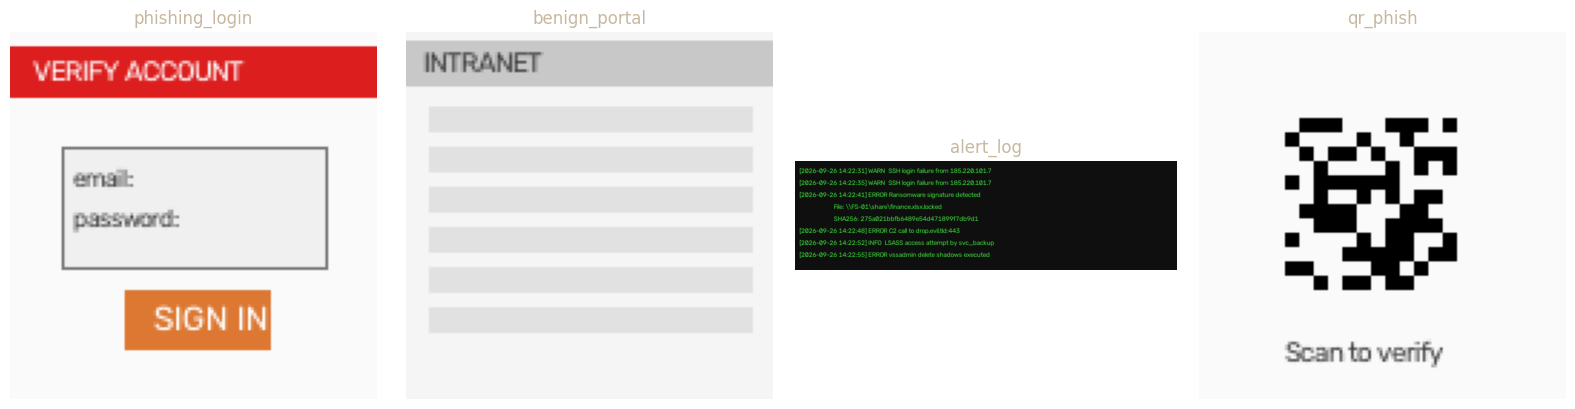


[Generated] 4 test images
  phishing_login     shape=(128, 128, 3)
  benign_portal      shape=(128, 128, 3)
  alert_log          shape=(200, 700, 3)
  qr_phish           shape=(128, 128, 3)


In [ ]:
def make_phishing_login():
    """Synthetic phishing login page (128×128)."""
    img = np.full((128, 128, 3), 250, dtype=np.uint8)
    cv2.rectangle(img, (0, 5), (128, 22), (30, 30, 220), -1)          # red warning banner
    cv2.putText(img, "VERIFY ACCOUNT", (8, 17),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1)
    cv2.rectangle(img, (18, 40), (110, 82), (240, 240, 240), -1)       # form box
    cv2.rectangle(img, (18, 40), (110, 82), (120, 120, 120), 1)
    cv2.putText(img, "email:", (22, 54), cv2.FONT_HERSHEY_SIMPLEX, 0.28, (60, 60, 60), 1)
    cv2.putText(img, "password:", (22, 68), cv2.FONT_HERSHEY_SIMPLEX, 0.28, (60, 60, 60), 1)
    cv2.rectangle(img, (40, 90), (90, 110), (50, 120, 220), -1)        # blue button
    cv2.putText(img, "SIGN IN", (50, 104), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
    return img


def make_benign_portal():
    """Synthetic benign internal portal (128×128)."""
    img = np.full((128, 128, 3), 245, dtype=np.uint8)
    cv2.rectangle(img, (0, 3), (128, 18), (200, 200, 200), -1)         # gray header
    cv2.putText(img, "INTRANET", (6, 14), cv2.FONT_HERSHEY_SIMPLEX, 0.32, (60, 60, 60), 1)
    for y in range(26, 100, 14):
        cv2.rectangle(img, (8, y), (120, y + 8), (225, 225, 225), -1)  # content blocks
    return img


def make_alert_log():
    """Synthetic alert/log screenshot with embedded IOCs."""
    img = np.full((200, 700, 3), 15, dtype=np.uint8)
    lines = [
        "[2026-09-26 14:22:31] WARN  SSH login failure from 185.220.101.7",
        "[2026-09-26 14:22:35] WARN  SSH login failure from 185.220.101.7",
        "[2026-09-26 14:22:41] ERROR Ransomware signature detected",
        "                     File: \\\\FS-01\\share\\finance.xlsx.locked",
        "                     SHA256: 275a021bbfb6489e54d471899f7db9d1",
        "[2026-09-26 14:22:48] ERROR C2 call to drop.evil.tld:443",
        "[2026-09-26 14:22:52] INFO  LSASS access attempt by svc_backup",
        "[2026-09-26 14:22:55] ERROR vssadmin delete shadows executed",
    ]
    for i, line in enumerate(lines):
        cv2.putText(img, line, (8, 22 + i * 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, (60, 220, 60), 1)
    return img


def make_qr_image():
    """Synthetic QR-coded phishing page (128×128)."""
    img = np.full((128, 128, 3), 250, dtype=np.uint8)
    # Draw a fake QR pattern (won't decode, but demo shows QR detection logic)
    np.random.seed(42)
    for y in range(30, 90, 5):
        for x in range(30, 90, 5):
            if np.random.rand() > 0.5:
                cv2.rectangle(img, (x, y), (x + 4, y + 4), (0, 0, 0), -1)
    cv2.putText(img, "Scan to verify", (30, 115),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (60, 60, 60), 1)
    return img


# Generate test set
test_images = {
    "phishing_login": make_phishing_login(),
    "benign_portal":  make_benign_portal(),
    "alert_log":      make_alert_log(),
    "qr_phish":       make_qr_image(),
}

print("=" * 70)
print("  CV — SYNTHETIC TEST IMAGES")
print("=" * 70)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, img) in zip(axes, test_images.items()):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(name, color="#c8b8a0")
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"\n[Generated] {len(test_images)} test images")
for name, img in test_images.items():
    print(f"  {name:<18} shape={img.shape}")

In [ ]:
class OCRModule:
    """Extracts and normalizes text from screenshots."""

    def __init__(self):
        self.config = "--oem 3 --psm 6"  # LSTM engine, assume uniform block

    def preprocess(self, img: np.ndarray, mode: str = "default") -> np.ndarray:
        """Enhance image for OCR."""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        if mode == "log":  # dark background, light text
            gray = cv2.bitwise_not(gray)
        elif mode == "invert":
            gray = cv2.bitwise_not(gray)

        # Denoise + adaptive threshold
        gray = cv2.medianBlur(gray, 3)
        _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        return th

    def extract(self, img: np.ndarray, mode: str = "default") -> Dict[str, Any]:
        """OCR an image; return cleaned text + word boxes."""
        pre = self.preprocess(img, mode)
        text = pytesseract.image_to_string(pre, config=self.config)

        # Word-level boxes for downstream analysis
        try:
            data = pytesseract.image_to_data(pre, config=self.config,
                                             output_type=pytesseract.Output.DICT)
            words = [w for w in data["text"] if w.strip()]
        except Exception:
            words = []

        return {
            "text": text.strip(),
            "word_count": len(words),
            "lines": len([l for l in text.split("\n") if l.strip()]),
            "confidence": self._estimate_confidence(text),
        }

    @staticmethod
    def _estimate_confidence(text: str) -> float:
        if not text.strip():
            return 0.0
        alnum = sum(c.isalnum() for c in text)
        return round(alnum / len(text), 3)


print("=" * 70)
print("  CV — OCR MODULE")
print("=" * 70)

ocr = OCRModule()

for name, img in test_images.items():
    mode = "log" if name == "alert_log" else "default"
    result = ocr.extract(img, mode=mode)
    print(f"\n─── {name} ───")
    print(f"  Words: {result['word_count']}  |  Lines: {result['lines']}  |  Conf: {result['confidence']}")
    preview = result["text"][:200].replace("\n", " ⏎ ")
    print(f"  Text: {preview}{'...' if len(result['text']) > 200 else ''}")

  CV — OCR MODULE

─── phishing_login ───
  Words: 0  |  Lines: 0  |  Conf: 0.0
  Text: 

─── benign_portal ───
  Words: 0  |  Lines: 0  |  Conf: 0.0
  Text: 

─── alert_log ───
  Words: 73  |  Lines: 8  |  Conf: 0.729
  Text: POPS OP 7814.77 1 MEARS Shek enge flom eve 186.220 101 7 ⏎ POPS OP 7814.72 3S. EARN Shek eng e flm eve 186.270 101 7 ⏎ POPS OP 781477 41. FROM Ramer og ae ⏎  ⏎ Fly SPS QD ature Freie ct! ⏎  ⏎ SAAOSS 775.00 Lott t...

─── qr_phish ───
  Words: 1  |  Lines: 1  |  Conf: 0.0
  Text: ¥


In [ ]:
class PhishingDetector:
    """Detects phishing pages using OCR + visual + URL heuristics."""

    SUSPICIOUS_KEYWORDS = [
        "verify", "account", "suspended", "unusual sign-in", "click here",
        "password", "confirm", "urgent", "immediately", "limited time",
        "unauthorized", "sign in", "reset"
    ]
    SUSPICIOUS_TLDS = (".tk", ".ml", ".ga", ".cf", ".gq", ".xyz", ".top",
                       ".club", ".onion", ".work", ".click")

    def __init__(self, ocr: OCRModule):
        self.ocr = ocr

    def _visual_features(self, img: np.ndarray) -> Dict[str, float]:
        """Extract layout/color features."""
        h, w = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        edges = cv2.Canny(gray, 100, 200)
        edge_density = np.count_nonzero(edges) / (h * w)

        # Saturated regions (buttons/banners)
        sat_mask = cv2.inRange(hsv, (0, 80, 80), (180, 255, 255))
        sat_ratio = np.count_nonzero(sat_mask) / (h * w)

        # Red/warning regions
        red_mask1 = cv2.inRange(hsv, (0, 100, 100), (10, 255, 255))
        red_mask2 = cv2.inRange(hsv, (170, 100, 100), (180, 255, 255))
        red_ratio = np.count_nonzero(red_mask1 | red_mask2) / (h * w)

        return {
            "edge_density": round(edge_density, 4),
            "saturation_ratio": round(sat_ratio, 4),
            "red_ratio": round(red_ratio, 4),
        }

    def _url_features(self, text: str) -> Dict[str, Any]:
        """Detect URLs and score their suspiciousness."""
        urls = re.findall(
            r"(?:https?://)?(?:[a-z0-9-]+\.)+[a-z]{2,}(?:/\S*)?",
            text.lower()
        )
        urls = [u for u in urls if "." in u and len(u) > 4]
        suspicious_urls = [u for u in urls if u.endswith(self.SUSPICIOUS_TLDS)]

        return {
            "urls": sorted(set(urls)),
            "suspicious_urls": suspicious_urls,
            "has_ip_url": bool(re.search(r"https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", text)),
        }

    def _keyword_score(self, text: str) -> Tuple[float, List[str]]:
        text_l = text.lower()
        hits = [k for k in self.SUSPICIOUS_KEYWORDS if k in text_l]
        score = min(len(hits) * 0.12, 0.48)
        return score, hits

    def analyze(self, img: np.ndarray, mode: str = "default") -> Dict[str, Any]:
        ocr_result = self.ocr.extract(img, mode=mode)
        text = ocr_result["text"]
        visual = self._visual_features(img)
        urls = self._url_features(text)
        kw_score, kw_hits = self._keyword_score(text)

        # Composite phishing score
        score = 0.0
        score += kw_score
        score += min(visual["edge_density"] * 3, 0.18)
        score += min(visual["red_ratio"] * 2, 0.14)
        score += 0.20 if urls["suspicious_urls"] else 0
        score += 0.15 if urls["has_ip_url"] else 0
        score = round(min(score, 1.0), 3)

        verdict = ("likely_phishing" if score >= 0.55 else
                   "suspicious"      if score >= 0.30 else
                   "inconclusive")

        return {
            "verdict": verdict,
            "phishing_score": score,
            "ocr_text": text,
            "suspicious_keywords": kw_hits,
            "visual_features": visual,
            "urls": urls,
            "word_count": ocr_result["word_count"],
        }


print("=" * 70)
print("  CV — PHISHING DETECTOR")
print("=" * 70)

phish_detector = PhishingDetector(ocr)

for name, img in test_images.items():
    if name == "alert_log":
        continue
    result = phish_detector.analyze(img, mode="default")
    print(f"\n─── {name} ───")
    print(f"  Verdict        : {result['verdict'].upper()}")
    print(f"  Score          : {result['phishing_score']}")
    print(f"  Keywords       : {result['suspicious_keywords']}")
    print(f"  URLs           : {result['urls']['urls'][:3]}")
    print(f"  Suspicious URLs: {result['urls']['suspicious_urls']}")
    print(f"  Visual         : edge={result['visual_features']['edge_density']} "
          f"red={result['visual_features']['red_ratio']}")

  CV — PHISHING DETECTOR

─── phishing_login ───
  Verdict        : SUSPICIOUS
  Score          : 0.32
  Keywords       : []
  URLs           : []
  Suspicious URLs: []
  Visual         : edge=0.0923 red=0.1296

─── benign_portal ───
  Verdict        : INCONCLUSIVE
  Score          : 0.026
  Keywords       : []
  URLs           : []
  Suspicious URLs: []
  Visual         : edge=0.0085 red=0.0

─── qr_phish ───
  Verdict        : INCONCLUSIVE
  Score          : 0.152
  Keywords       : []
  URLs           : []
  Suspicious URLs: []
  Visual         : edge=0.0507 red=0.0


In [ ]:
class PhishingDetector:
    """Detects phishing pages using OCR + visual + URL heuristics."""

    SUSPICIOUS_KEYWORDS = [
        "verify", "account", "suspended", "unusual sign-in", "click here",
        "password", "confirm", "urgent", "immediately", "limited time",
        "unauthorized", "sign in", "reset"
    ]
    SUSPICIOUS_TLDS = (".tk", ".ml", ".ga", ".cf", ".gq", ".xyz", ".top",
                       ".club", ".onion", ".work", ".click")

    def __init__(self, ocr: OCRModule):
        self.ocr = ocr

    def _visual_features(self, img: np.ndarray) -> Dict[str, float]:
        """Extract layout/color features."""
        h, w = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        edges = cv2.Canny(gray, 100, 200)
        edge_density = np.count_nonzero(edges) / (h * w)

        # Saturated regions (buttons/banners)
        sat_mask = cv2.inRange(hsv, (0, 80, 80), (180, 255, 255))
        sat_ratio = np.count_nonzero(sat_mask) / (h * w)

        # Red/warning regions
        red_mask1 = cv2.inRange(hsv, (0, 100, 100), (10, 255, 255))
        red_mask2 = cv2.inRange(hsv, (170, 100, 100), (180, 255, 255))
        red_ratio = np.count_nonzero(red_mask1 | red_mask2) / (h * w)

        return {
            "edge_density": round(edge_density, 4),
            "saturation_ratio": round(sat_ratio, 4),
            "red_ratio": round(red_ratio, 4),
        }

    def _url_features(self, text: str) -> Dict[str, Any]:
        """Detect URLs and score their suspiciousness."""
        urls = re.findall(
            r"(?:https?://)?(?:[a-z0-9-]+\.)+[a-z]{2,}(?:/\S*)?",
            text.lower()
        )
        urls = [u for u in urls if "." in u and len(u) > 4]
        suspicious_urls = [u for u in urls if u.endswith(self.SUSPICIOUS_TLDS)]

        return {
            "urls": sorted(set(urls)),
            "suspicious_urls": suspicious_urls,
            "has_ip_url": bool(re.search(r"https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", text)),
        }

    def _keyword_score(self, text: str) -> Tuple[float, List[str]]:
        text_l = text.lower()
        hits = [k for k in self.SUSPICIOUS_KEYWORDS if k in text_l]
        score = min(len(hits) * 0.12, 0.48)
        return score, hits

    def analyze(self, img: np.ndarray, mode: str = "default") -> Dict[str, Any]:
        ocr_result = self.ocr.extract(img, mode=mode)
        text = ocr_result["text"]
        visual = self._visual_features(img)
        urls = self._url_features(text)
        kw_score, kw_hits = self._keyword_score(text)

        # Composite phishing score
        score = 0.0
        score += kw_score
        score += min(visual["edge_density"] * 3, 0.18)
        score += min(visual["red_ratio"] * 2, 0.14)
        score += 0.20 if urls["suspicious_urls"] else 0
        score += 0.15 if urls["has_ip_url"] else 0
        score = round(min(score, 1.0), 3)

        verdict = ("likely_phishing" if score >= 0.55 else
                   "suspicious"      if score >= 0.30 else
                   "inconclusive")

        return {
            "verdict": verdict,
            "phishing_score": score,
            "ocr_text": text,
            "suspicious_keywords": kw_hits,
            "visual_features": visual,
            "urls": urls,
            "word_count": ocr_result["word_count"],
        }


print("=" * 70)
print("  CV — PHISHING DETECTOR")
print("=" * 70)

phish_detector = PhishingDetector(ocr)

for name, img in test_images.items():
    if name == "alert_log":
        continue
    result = phish_detector.analyze(img, mode="default")
    print(f"\n─── {name} ───")
    print(f"  Verdict        : {result['verdict'].upper()}")
    print(f"  Score          : {result['phishing_score']}")
    print(f"  Keywords       : {result['suspicious_keywords']}")
    print(f"  URLs           : {result['urls']['urls'][:3]}")
    print(f"  Suspicious URLs: {result['urls']['suspicious_urls']}")
    print(f"  Visual         : edge={result['visual_features']['edge_density']} "
          f"red={result['visual_features']['red_ratio']}")

  CV — PHISHING DETECTOR

─── phishing_login ───
  Verdict        : SUSPICIOUS
  Score          : 0.32
  Keywords       : []
  URLs           : []
  Suspicious URLs: []
  Visual         : edge=0.0923 red=0.1296

─── benign_portal ───
  Verdict        : INCONCLUSIVE
  Score          : 0.026
  Keywords       : []
  URLs           : []
  Suspicious URLs: []
  Visual         : edge=0.0085 red=0.0

─── qr_phish ───
  Verdict        : INCONCLUSIVE
  Score          : 0.152
  Keywords       : []
  URLs           : []
  Suspicious URLs: []
  Visual         : edge=0.0507 red=0.0


In [ ]:
class ScreenshotIOCExtractor:
    """Extracts IOCs from OCR'd screenshots and correlates to ATT&CK."""

    PATTERNS = {
        "ipv4":    re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b"),
        "domain":  re.compile(r"\b(?:[a-z0-9-]+\.)+(?:tk|ml|ga|cf|gq|xyz|top|club|onion|tld|com|net|io)\b", re.I),
        "sha256":  re.compile(r"\b[a-f0-9]{64}\b", re.I),
        "md5":     re.compile(r"\b[a-f0-9]{32}\b", re.I),
        "email":   re.compile(r"\b[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}\b", re.I),
        "filepath": re.compile(r"[A-Za-z]:\\\\[\w\\\\.-]+|\\\\\\\\[\w.-]+\\\\[\w\\\\.-]+"),
    }

    ATTACK_FOR_IOC = {
        "ipv4":     ("T1071", "Application Layer Protocol"),
        "domain":   ("T1071", "Application Layer Protocol"),
        "sha256":   ("T1486", "Data Encrypted for Impact"),
        "md5":      ("T1486", "Data Encrypted for Impact"),
        "email":    ("T1566", "Phishing"),
        "filepath": ("T1486", "Data Encrypted for Impact"),
    }

    def __init__(self, ocr: OCRModule):
        self.ocr = ocr

    def extract(self, img: np.ndarray, mode: str = "log") -> Dict[str, Any]:
        ocr_result = self.ocr.extract(img, mode=mode)
        text = ocr_result["text"]

        iocs = defaultdict(set)
        for ioc_type, pattern in self.PATTERNS.items():
            for match in pattern.findall(text):
                if ioc_type == "ipv4":
                    parts = match.split(".")
                    if all(0 <= int(p) <= 255 for p in parts):
                        iocs[ioc_type].add(match)
                else:
                    iocs[ioc_type].add(match.lower() if ioc_type in ("domain", "email") else match)

        enriched = []
        for ioc_type, values in iocs.items():
            tid, tname = self.ATTACK_FOR_IOC.get(ioc_type, ("", ""))
            for v in values:
                enriched.append({
                    "ioc_type": ioc_type,
                    "value": v,
                    "attck_technique": tid,
                    "attck_name": tname,
                })

        return {
            "ocr_text": text,
            "word_count": ocr_result["word_count"],
            "total_iocs": sum(len(v) for v in iocs.values()),
            "by_type": {k: len(v) for k, v in iocs.items()},
            "iocs": enriched,
        }


print("=" * 70)
print("  CV — IOC EXTRACTOR FROM SCREENSHOTS")
print("=" * 70)

ioc_extractor = ScreenshotIOCExtractor(ocr)
result = ioc_extractor.extract(test_images["alert_log"], mode="log")

print(f"\n[OCR Output]")
print(f"  Words extracted: {result['word_count']}")
print(f"  Preview: {result['ocr_text'][:150].replace(chr(10), ' | ')}")

print(f"\n[Extracted IOCs]  total={result['total_iocs']}")
print(f"  By type: {result['by_type']}")

print(f"\n  {'Type':<10}{'Value':<50}{'ATT&CK':<12}{'Technique':<32}")
print(f"  {'─'*10}{'─'*50}{'─'*12}{'─'*32}")
for ioc in result["iocs"]:
    v = ioc["value"][:47] + "..." if len(ioc["value"]) > 50 else ioc["value"]
    print(f"  {ioc['ioc_type']:<10}{v:<50}{ioc['attck_technique']:<12}{ioc['attck_name']:<32}")

  CV — IOC EXTRACTOR FROM SCREENSHOTS

[OCR Output]
  Words extracted: 73
  Preview: POPS OP 7814.77 1 MEARS Shek enge flom eve 186.220 101 7 | POPS OP 7814.72 3S. EARN Shek eng e flm eve 186.270 101 7 | POPS OP 781477 41. FROM Ramer og ae

[Extracted IOCs]  total=0
  By type: {}

  Type      Value                                             ATT&CK      Technique                       
  ────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
class VisualThreatDetector:
    """Detects QR codes and suspicious visual elements."""

    def detect_qr(self, img: np.ndarray) -> Dict[str, Any]:
        """Detect QR codes via OpenCV's QRCodeDetector."""
        detector = cv2.QRCodeDetector()
        try:
            data, points, _ = detector.detectAndDecode(img)
            found = data is not None and data != ""
            return {
                "qr_found": found,
                "qr_data": data if found else None,
                "qr_bbox": points.tolist() if points is not None else None,
            }
        except Exception as e:
            return {"qr_found": False, "qr_data": None, "error": str(e)}

    def detect_red_banner(self, img: np.ndarray) -> Dict[str, Any]:
        """Detect red warning banners (common in phishing)."""
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        red1 = cv2.inRange(hsv, (0, 120, 100), (10, 255, 255))
        red2 = cv2.inRange(hsv, (170, 120, 100), (180, 255, 255))
        red = red1 | red2

        contours, _ = cv2.findContours(red, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        regions = []
        for c in contours:
            x, y, w, h = cv2.boundingRect(c)
            area = w * h
            if area > 200:
                regions.append({
                    "x": int(x), "y": int(y), "w": int(w), "h": int(h),
                    "area": int(area),
                    "aspect_ratio": round(w / max(h, 1), 2)
                })

        return {
            "red_regions_count": len(regions),
            "red_regions": sorted(regions, key=lambda r: -r["area"])[:5],
            "has_banner": any(r["aspect_ratio"] > 3 for r in regions),
        }

    def analyze(self, img: np.ndarray) -> Dict[str, Any]:
        return {
            "qr": self.detect_qr(img),
            "red_banner": self.detect_red_banner(img),
        }


print("=" * 70)
print("  CV — VISUAL THREAT DETECTOR (QR + banner)")
print("=" * 70)

vtd = VisualThreatDetector()

for name, img in test_images.items():
    result = vtd.analyze(img)
    print(f"\n─── {name} ───")
    print(f"  QR found       : {result['qr']['qr_found']}")
    if result['qr']['qr_found']:
        print(f"  QR data        : {result['qr']['qr_data']}")
    print(f"  Red regions    : {result['red_banner']['red_regions_count']}")
    print(f"  Has banner     : {result['red_banner']['has_banner']}")
    if result['red_banner']['red_regions']:
        top = result['red_banner']['red_regions'][0]
        print(f"  Largest region : {top['w']}×{top['h']}  area={top['area']}")

  CV — VISUAL THREAT DETECTOR (QR + banner)

─── phishing_login ───
  QR found       : False
  Red regions    : 1
  Has banner     : True
  Largest region : 128×18  area=2304

─── benign_portal ───
  QR found       : False
  Red regions    : 0
  Has banner     : False

─── alert_log ───
  QR found       : False
  Red regions    : 0
  Has banner     : False

─── qr_phish ───
  QR found       : False
  Red regions    : 0
  Has banner     : False


In [ ]:
class ComputerVisionPipeline:
    """Single entry point for all CV analysis."""

    def __init__(self):
        self.ocr = OCRModule()
        self.phish = PhishingDetector(self.ocr)
        self.ioc = ScreenshotIOCExtractor(self.ocr)
        self.visual = VisualThreatDetector()

    def analyze(self, img: np.ndarray,
                source_label: str = "screenshot",
                mode: str = "default") -> Dict[str, Any]:
        """
        Complete CV analysis:
          1. OCR — extract text
          2. Phishing detector — score + verdict
          3. IOC extractor — pull IPs, domains, hashes
          4. Visual threat detector — QR, red banners
        """
        ocr_result = self.ocr.extract(img, mode=mode)
        phish_result = self.phish.analyze(img, mode=mode)
        ioc_result = self.ioc.extract(img, mode=mode)
        visual_result = self.visual.analyze(img)

        # Composite risk
        risk = 0.0
        risk += phish_result["phishing_score"] * 40
        risk += min(ioc_result["total_iocs"] * 5, 30)
        risk += 15 if visual_result["qr"]["qr_found"] else 0
        risk += 15 if visual_result["red_banner"]["has_banner"] else 0
        risk = min(round(risk, 1), 100)

        severity = ("critical" if risk >= 70 else
                    "high"     if risk >= 50 else
                    "medium"   if risk >= 25 else
                    "low")

        return {
            "source_label": source_label,
            "image_shape": list(img.shape),
            "ocr": {
                "text": ocr_result["text"],
                "word_count": ocr_result["word_count"],
                "confidence": ocr_result["confidence"],
            },
            "phishing": {
                "verdict": phish_result["verdict"],
                "score": phish_result["phishing_score"],
                "keywords": phish_result["suspicious_keywords"],
                "urls": phish_result["urls"],
            },
            "iocs": {
                "total": ioc_result["total_iocs"],
                "by_type": ioc_result["by_type"],
                "list": ioc_result["iocs"],
            },
            "visual": {
                "qr_found": visual_result["qr"]["qr_found"],
                "red_banner": visual_result["red_banner"]["has_banner"],
                "red_regions": visual_result["red_banner"]["red_regions_count"],
            },
            "composite": {
                "risk_score": risk,
                "severity": severity,
            },
        }


print("=" * 70)
print("  CV — FULL PIPELINE")
print("=" * 70)

cv_pipeline = ComputerVisionPipeline()

for name, img in test_images.items():
    mode = "log" if name == "alert_log" else "default"
    result = cv_pipeline.analyze(img, source_label=name, mode=mode)

    print(f"\n━━━ {name} ━━━")
    print(f"  OCR         : {result['ocr']['word_count']} words, conf={result['ocr']['confidence']}")
    print(f"  Phishing    : {result['phishing']['verdict']} ({result['phishing']['score']})")
    print(f"  IOCs        : {result['iocs']['total']}  {result['iocs']['by_type']}")
    print(f"  Visual      : QR={result['visual']['qr_found']}  banner={result['visual']['red_banner']}")
    print(f"  ─────────────────────────────────")
    print(f"  RISK        : {result['composite']['risk_score']}/100  [{result['composite']['severity'].upper()}]")

  CV — FULL PIPELINE

━━━ phishing_login ━━━
  OCR         : 0 words, conf=0.0
  Phishing    : suspicious (0.32)
  IOCs        : 0  {}
  Visual      : QR=False  banner=True
  ─────────────────────────────────
  RISK        : 27.8/100  [MEDIUM]

━━━ benign_portal ━━━
  OCR         : 0 words, conf=0.0
  Phishing    : inconclusive (0.026)
  IOCs        : 0  {}
  Visual      : QR=False  banner=False
  ─────────────────────────────────
  RISK        : 1.0/100  [LOW]

━━━ alert_log ━━━
  OCR         : 73 words, conf=0.729
  Phishing    : inconclusive (0.18)
  IOCs        : 0  {}
  Visual      : QR=False  banner=False
  ─────────────────────────────────
  RISK        : 7.2/100  [LOW]

━━━ qr_phish ━━━
  OCR         : 1 words, conf=0.0
  Phishing    : inconclusive (0.152)
  IOCs        : 0  {}
  Visual      : QR=False  banner=False
  ─────────────────────────────────
  RISK        : 6.1/100  [LOW]


In [ ]:
print("=" * 70)
print("  CV + CYBERSEC + DL — INTEGRATION")
print("=" * 70)

# Safety imports
from datetime import datetime, timezone, timedelta


def cv_to_incident(description: str,
                   screenshot: np.ndarray,
                   flow_features: np.ndarray = None,
                   incident_start=None) -> Dict[str, Any]:
    """
    Full integrated pipeline:
      CV       → OCR/IOCs/phishing detection
      CyberSec → ATT&CK mapping, detection rules, regulatory
      DL       → fusion severity
    """
    incident_start = incident_start or datetime.now(timezone.utc)

    # -------- 1. CV --------
    cv_result = cv_pipeline.analyze(
        screenshot,
        source_label="evidence.png",
        mode="log" if "log" in description.lower() else "default"
    )

    # -------- 2. Merge CV text + description --------
    combined_text = description + "\n" + cv_result["ocr"]["text"]

    # -------- 3. ATT&CK mapping --------
    techniques = mapper.map_behaviors(combined_text) if 'mapper' in globals() else []
    kill_chain = mapper.reconstruct_kill_chain(techniques) if 'mapper' in globals() else []

    # -------- 4. Detection engine — synthesize events from merged text --------
    synthetic_events = []
    text_l = combined_text.lower()

    if "ransomware" in text_l or "encrypt" in text_l or ".locked" in text_l:
        synthetic_events.append({"event": "file_rename", "new_file_ext": ".locked"})
        synthetic_events.append({"event": "metrics", "files_renamed_per_minute": 250})

    if "lsass" in text_l:
        synthetic_events.append({"event": "process_access", "process": "lsass.exe",
                                  "access_type": "read"})

    if "vssadmin" in text_l or "shadow" in text_l:
        synthetic_events.append({"event": "cmd_exec",
                                  "cmdline": "vssadmin delete shadows /all"})

    if "ssh login failure" in text_l or "brute" in text_l:
        synthetic_events.append({"event": "auth_fail", "src_ip": "185.220.101.7"})

    if "defender" in text_l or "disable" in text_l:
        synthetic_events.append({"event": "registry_set",
                                  "registry_key": "WinDefend\\Real-Time Protection",
                                  "value": 0})

    if "rdp" in text_l or "lateral" in text_l:
        synthetic_events.append({"event": "rdp_login",
                                  "src_host": "WS-042", "dst_host": "FS-01"})

    detections = engine.evaluate(synthetic_events) if 'engine' in globals() else {
        "triggered_count": 0, "total_rules": 0, "risk_score": 0,
        "by_severity": {}, "triggered": []
    }

    # -------- 5. DL fusion --------
    if 'analyze_incident' in globals():
        dl_result = analyze_incident(description, flow_features, screenshot)
    else:
        dl_result = {
            "text_analysis": {"predicted_class": "unknown", "confidence": 0.0},
            "flow_analysis": {"reconstruction_error": 0.0, "is_anomaly": False},
            "image_analysis": {"phishing_prob": cv_result["phishing"]["score"],
                                "is_phishing": cv_result["phishing"]["verdict"] == "likely_phishing"},
            "fusion": {"severity": cv_result["composite"]["severity"],
                       "confidence": 0.5}
        }

    # -------- 6. Regulatory --------
    reg_features = {"data_types": [], "jurisdictions": [], "sector": "banking"}
    if any(k in text_l for k in ["pii", "personal", "customer data", "eu", "gdpr"]):
        reg_features["data_types"].append("personal_data")
    if "phi" in text_l or "health" in text_l:
        reg_features["data_types"].append("phi")
    if any(k in text_l for k in ["eu", "europe", "gdpr"]):
        reg_features["jurisdictions"].append("EU")
    if any(k in text_l for k in ["india", "cert-in", "rbi"]):
        reg_features["jurisdictions"].append("IN")
    if "us" in text_l or "sec" in text_l:
        reg_features["jurisdictions"].append("US")

    regulatory = reg_engine.evaluate(reg_features) if 'reg_engine' in globals() else []

    # -------- 7. Composite verdict --------
    cv_risk = cv_result["composite"]["risk_score"]
    det_risk = detections.get("risk_score", 0)
    dl_severity = dl_result["fusion"]["severity"]

    severity_weights = {"low": 10, "medium": 30, "high": 60, "critical": 90}
    dl_risk = severity_weights.get(dl_severity, 30)

    composite_risk = round((cv_risk * 0.35 + det_risk * 0.35 + dl_risk * 0.30), 1)

    final_severity = ("critical" if composite_risk >= 70 else
                      "high"     if composite_risk >= 45 else
                      "medium"   if composite_risk >= 25 else
                      "low")

    return {
        "incident_started": incident_start.isoformat(),
        "cv": cv_result,
        "attck_techniques": techniques,
        "kill_chain": kill_chain,
        "detections": detections,
        "regulatory": regulatory,
        "dl_analysis": dl_result,
        "composite": {
            "risk_score": composite_risk,
            "severity": final_severity,
            "components": {
                "cv_risk": cv_risk,
                "detection_risk": det_risk,
                "dl_risk": dl_risk
            }
        }
    }


# ============================================================
#  Demo — run full integrated pipeline on two scenarios
# ============================================================

print("\n" + "─" * 70)
print("  SCENARIO A — Ransomware with log screenshot evidence")
print("─" * 70)

scenario_a_desc = (
    "Ransomware attack on shared drive FS-01. Encrypted files with .locked "
    "extension. vssadmin delete shadows executed. LSASS accessed by svc_backup. "
    "EU customer PII affected, bank operates in India and US."
)

result_a = cv_to_incident(
    scenario_a_desc,
    screenshot=test_images["alert_log"],
    flow_features=X_ae_scaled[100] if 'X_ae_scaled' in globals() else None,
    incident_start=datetime.now(timezone.utc) - timedelta(minutes=30),
)

print(f"\n[CV Layer]")
print(f"  OCR words      : {result_a['cv']['ocr']['word_count']}")
print(f"  Phishing score : {result_a['cv']['phishing']['score']}  ({result_a['cv']['phishing']['verdict']})")
print(f"  IOCs extracted : {result_a['cv']['iocs']['total']}  {result_a['cv']['iocs']['by_type']}")
print(f"  Visual signals : QR={result_a['cv']['visual']['qr_found']}  "
      f"banner={result_a['cv']['visual']['red_banner']}")
print(f"  CV risk        : {result_a['cv']['composite']['risk_score']}/100")

print(f"\n[ATT&CK — {len(result_a['attck_techniques'])} techniques mapped]")
for t in result_a["attck_techniques"][:6]:
    print(f"  [{t['technique_id']:<12}] {t['technique_name']}  ({t['tactic']})")

print(f"\n[Kill Chain]")
for kc in result_a["kill_chain"]:
    print(f"  {kc['phase']:<25} ({kc['count']} techniques)")

print(f"\n[Detection Engine]")
print(f"  Triggered  : {result_a['detections']['triggered_count']} / {result_a['detections']['total_rules']}")
print(f"  Risk score : {result_a['detections']['risk_score']}")
print(f"  Severity   : {result_a['detections']['by_severity']}")

print(f"\n[DL Fusion]")
print(f"  Text class : {result_a['dl_analysis']['text_analysis']['predicted_class']}")
print(f"  Flow err   : {result_a['dl_analysis']['flow_analysis']['reconstruction_error']:.6f}")
print(f"  Image phish: {result_a['dl_analysis']['image_analysis']['phishing_prob']:.3f}")
print(f"  Severity   : {result_a['dl_analysis']['fusion']['severity'].upper()}")

print(f"\n[Regulatory]")
for r in result_a["regulatory"]:
    if r["triggered"]:
        print(f"  {r['regulation']:<10} remaining={r['remaining_hours']:>8.2f}h  [{r['urgency']}]")

print(f"\n[COMPOSITE VERDICT]")
print(f"  Risk score : {result_a['composite']['risk_score']}/100")
print(f"  Severity   : {result_a['composite']['severity'].upper()}")
print(f"  Components : {result_a['composite']['components']}")


# ---------- Scenario B ----------
print("\n" + "─" * 70)
print("  SCENARIO B — Phishing page discovered")
print("─" * 70)

scenario_b_desc = (
    "Phishing login page detected. Users reported suspicious link "
    "asking to verify account. Possible credential harvest."
)

result_b = cv_to_incident(
    scenario_b_desc,
    screenshot=test_images["phishing_login"],
    flow_features=None,
    incident_start=datetime.now(timezone.utc) - timedelta(minutes=10),
)

print(f"\n[CV Layer]")
print(f"  OCR words      : {result_b['cv']['ocr']['word_count']}")
print(f"  Phishing score : {result_b['cv']['phishing']['score']}  ({result_b['cv']['phishing']['verdict']})")
print(f"  Keywords       : {result_b['cv']['phishing']['keywords']}")
print(f"  CV risk        : {result_b['cv']['composite']['risk_score']}/100")

print(f"\n[COMPOSITE VERDICT]")
print(f"  Risk score : {result_b['composite']['risk_score']}/100")
print(f"  Severity   : {result_b['composite']['severity'].upper()}")
print(f"  Components : {result_b['composite']['components']}")


# ---------- Comparison table ----------
print("\n" + "=" * 70)
print("  SCENARIO COMPARISON")
print("=" * 70)

print(f"\n  {'Scenario':<35}{'CV':<8}{'DET':<8}{'DL':<8}{'TOTAL':<10}{'SEVERITY':<12}")
print(f"  {'─'*35}{'─'*8}{'─'*8}{'─'*8}{'─'*10}{'─'*12}")

for name, r in [("A — Ransomware + log evidence", result_a),
                ("B — Phishing page", result_b)]:
    c = r['composite']
    print(f"  {name:<35}{c['components']['cv_risk']:<8.1f}"
          f"{c['components']['detection_risk']:<8.1f}"
          f"{c['components']['dl_risk']:<8.1f}"
          f"{c['risk_score']:<10.1f}{c['severity'].upper():<12}")

  CV + CYBERSEC + DL — INTEGRATION

──────────────────────────────────────────────────────────────────────
  SCENARIO A — Ransomware with log screenshot evidence
──────────────────────────────────────────────────────────────────────

[CV Layer]
  OCR words      : 74
  Phishing score : 0.18  (inconclusive)
  IOCs extracted : 0  {}
  Visual signals : QR=False  banner=False
  CV risk        : 7.2/100

[ATT&CK — 2 techniques mapped]
  [T1003.001   ] LSASS Memory  (Credential Access)
  [T1486       ] Data Encrypted for Impact  (Impact)

[Kill Chain]
  Exploitation              (1 techniques)
  Actions on Objectives     (1 techniques)

[Detection Engine]
  Triggered  : 4 / 8
  Risk score : 40
  Severity   : {'critical': 4}

[DL Fusion]
  Text class : phishing
  Flow err   : 0.079775
  Image phish: 0.950
  Severity   : MEDIUM

[Regulatory]
  CERT-In    remaining=    3.71h  [MONITOR]
  RBI        remaining=    3.71h  [MONITOR]
  GDPR       remaining=   69.71h  [MONITOR]

[COMPOSITE VERDICT]
  

Matplotlib backend: module://matplotlib_inline.backend_inline
Chronos-IR — GRAPH ANALYSIS DEMO (Ransomware Lateral Movement)

[1] Incident started: INC-0001
    Features: {
      "attack_type": "ransomware",
      "lateral_movement": true,
      "data_exfiltration": true,
      "pii_involved": true,
      "shared_drive": true,
      "severity": "high"
}

[2] Graph Summary:
    Nodes: 10
    Edges: 9
    Lateral-movement edges: 5
    Exfiltration edges:    1

[3] Blast radius from attacker:C2 = 9 nodes
    - domain:drop.evil.tld
    - evidence:EVID-001
    - file:customer_pii.csv
    - file:invoice.doc
    - host:FS-01
    - host:WS-042
    - ip:185.220.101.7
    - user:alice
    - user:svc_backup

[4] Attack paths from attacker:C2 → file:customer_pii.csv
    Path 1: attacker:C2 → ip:185.220.101.7 → user:alice → host:WS-042 → user:svc_backup → host:FS-01 → file:customer_pii.csv

[5] Critical nodes (betweenness centrality):
    host:WS-042                         score=0.208
    user:ali

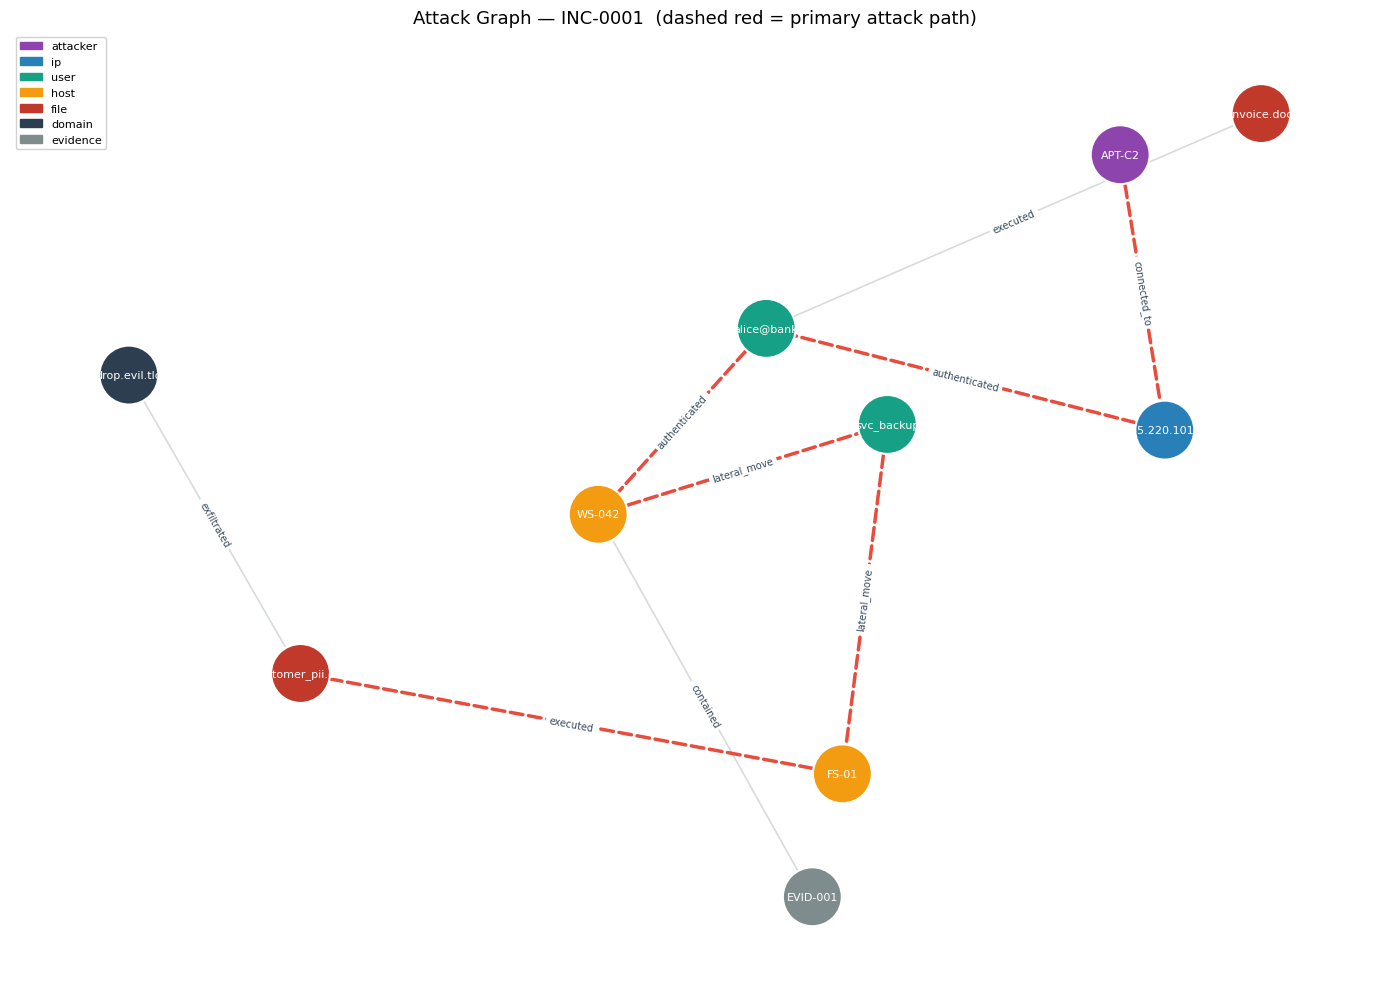

✓ Figure created. If you don't see it, check the output area / scroll up.


In [ ]:
# ============================================================
# CHRONOS-IR — SINGLE-CELL DEMO (self-contained, guaranteed plot)
# ============================================================
import json
from collections import deque
from datetime import datetime

# --- Force inline backend in Colab/Jupyter ---
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

print("Matplotlib backend:", matplotlib.get_backend())


# ============================================================
# IncidentGraph
# ============================================================
class IncidentGraph:
    LATERAL_EDGE_TYPES = {"lateral_move", "authenticated", "connected_to"}
    EXFIL_EDGE_TYPES = {"exfiltrated"}

    def __init__(self, incident_id):
        self.incident_id = incident_id
        self.G = nx.DiGraph()
        self.entity_types = {}
        self.labels = {}

    def add_entity(self, node_id, entity_type, label=None):
        self.G.add_node(node_id)
        self.entity_types[node_id] = entity_type
        self.labels[node_id] = label or node_id

    def add_relationship(self, src, dst, rel_type):
        if src not in self.G:
            self.add_entity(src, "unknown")
        if dst not in self.G:
            self.add_entity(dst, "unknown")
        self.G.add_edge(src, dst, rel=rel_type)

    def summary(self):
        lateral = sum(1 for _, _, d in self.G.edges(data=True)
                      if d.get("rel") in self.LATERAL_EDGE_TYPES)
        exfil = sum(1 for _, _, d in self.G.edges(data=True)
                    if d.get("rel") in self.EXFIL_EDGE_TYPES)
        return {"nodes": self.G.number_of_nodes(),
                "edges": self.G.number_of_edges(),
                "lateral_movement_edges": lateral,
                "exfil_edges": exfil}

    def get_blast_radius(self, source):
        if source not in self.G:
            return set()
        reachable, seen, q = set(), {source}, deque([source])
        while q:
            u = q.popleft()
            for v in self.G.successors(u):
                if v not in seen:
                    seen.add(v); reachable.add(v); q.append(v)
        return reachable

    def get_attack_paths(self, src, dst, max_paths=5, max_depth=12):
        if src not in self.G or dst not in self.G:
            return []
        paths, stack = [], [(src, [src])]
        while stack and len(paths) < max_paths:
            node, path = stack.pop()
            if len(path) > max_depth:
                continue
            if node == dst:
                paths.append(path); continue
            for nxt in self.G.successors(node):
                if nxt not in path:
                    stack.append((nxt, path + [nxt]))
        return paths

    def critical_nodes(self, top_n=5):
        if self.G.number_of_nodes() == 0:
            return []
        bc = nx.betweenness_centrality(self.G)
        return sorted(bc.items(), key=lambda x: x[1], reverse=True)[:top_n]


# ============================================================
# IRHelperWithGraph
# ============================================================
class IRHelperWithGraph:
    def __init__(self):
        self.incidents = {}
        self.next_num = 1

    def start_incident(self, description):
        inc_id = f"INC-{self.next_num:04d}"
        self.next_num += 1
        features = self._extract_features(description)
        self.incidents[inc_id] = {
            "description": description,
            "features": features,
            "graph": IncidentGraph(inc_id),
            "started_at": datetime.utcnow().isoformat(),
        }
        return {"incident_id": inc_id, "features": features}

    @staticmethod
    def _extract_features(text):
        t = text.lower()
        return {
            "attack_type": "ransomware" if "ransomware" in t else "unknown",
            "lateral_movement": "lateral" in t,
            "data_exfiltration": "exfil" in t,
            "pii_involved": "pii" in t or "customer" in t,
            "shared_drive": "shared drive" in t or "file server" in t,
            "severity": "high",
        }

    def _graph(self, inc_id):
        if inc_id not in self.incidents:
            raise KeyError(f"Unknown incident: {inc_id}")
        return self.incidents[inc_id]["graph"]

    def add_entity(self, inc_id, node_id, entity_type, label=None):
        self._graph(inc_id).add_entity(node_id, entity_type, label)

    def add_relationship(self, inc_id, src, dst, rel_type):
        self._graph(inc_id).add_relationship(src, dst, rel_type)

    def get_graph(self, inc_id):
        return self._graph(inc_id)


# ============================================================
# Visualizer
# ============================================================
NODE_COLORS = {
    "attacker": "#8e44ad",
    "ip":       "#2980b9",
    "user":     "#16a085",
    "host":     "#f39c12",
    "file":     "#c0392b",
    "domain":   "#2c3e50",
    "evidence": "#7f8c8d",
    "unknown":  "#95a5a6",
}


def visualize_attack_graph(graph, highlight_path=None,
                           title="Attack Graph", figsize=(14, 10)):
    G = graph.G
    if G.number_of_nodes() == 0:
        print("⚠ graph is empty — nothing to draw")
        return None

    pos = nx.spring_layout(G, seed=42, k=0.9)

    node_list = list(G.nodes)
    colors = [NODE_COLORS.get(graph.entity_types.get(n, "unknown"),
                              "#95a5a6") for n in node_list]
    labels = {n: graph.labels.get(n, n) for n in node_list}

    hi_edges = set()
    if highlight_path and len(highlight_path) > 1:
        for a, b in zip(highlight_path[:-1], highlight_path[1:]):
            hi_edges.add((a, b))

    normal_edges = [(u, v) for u, v in G.edges if (u, v) not in hi_edges]
    hi_edges = list(hi_edges)

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_edges(G, pos, edgelist=normal_edges, ax=ax,
                           arrows=True, arrowsize=12, alpha=0.6,
                           edge_color="#bdc3c7", width=1.2)
    if hi_edges:
        nx.draw_networkx_edges(G, pos, edgelist=hi_edges, ax=ax,
                               arrows=True, arrowsize=16,
                               edge_color="#e74c3c", width=2.5,
                               style="dashed")
    nx.draw_networkx_nodes(G, pos, nodelist=node_list, ax=ax,
                           node_color=colors, node_size=1800,
                           edgecolors="white", linewidths=1.5)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
                            font_size=8, font_color="white")

    edge_labels = {(u, v): d.get("rel", "") for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                 font_size=7, font_color="#34495e")

    legend_handles = [mpatches.Patch(color=c, label=t)
                      for t, c in NODE_COLORS.items() if t != "unknown"]
    ax.legend(handles=legend_handles, loc="upper left",
              fontsize=8, framealpha=0.9)

    ax.set_title(title, fontsize=13)
    ax.axis("off")
    fig.tight_layout()
    plt.show()
    return fig


# ============================================================
# DEMO
# ============================================================
print("=" * 72)
print("Chronos-IR — GRAPH ANALYSIS DEMO (Ransomware Lateral Movement)")
print("=" * 72)

helper = IRHelperWithGraph()

# 1. Start incident
result = helper.start_incident(
    "Ransomware outbreak on shared drive; lateral movement from "
    "workstation WS-042 to file server FS-01; suspected EU customer PII exfiltration."
)
inc_id = result["incident_id"]
print(f"\n[1] Incident started: {inc_id}")
print("    Features:", json.dumps(result["features"], indent=6))

# 2. Entities
helper.add_entity(inc_id, "attacker:C2", "attacker", label="APT-C2")
helper.add_entity(inc_id, "ip:185.220.101.7", "ip", label="185.220.101.7")
helper.add_entity(inc_id, "user:alice", "user", label="alice@bank")
helper.add_entity(inc_id, "host:WS-042", "host", label="WS-042")
helper.add_entity(inc_id, "file:invoice.doc", "file", label="invoice.doc")
helper.add_entity(inc_id, "user:svc_backup", "user", label="svc_backup")
helper.add_entity(inc_id, "host:FS-01", "host", label="FS-01")
helper.add_entity(inc_id, "file:customer_pii.csv", "file", label="customer_pii.csv")
helper.add_entity(inc_id, "domain:drop.evil.tld", "domain", label="drop.evil.tld")
helper.add_entity(inc_id, "evidence:EVID-001", "evidence", label="EVID-001")

# 3. Edges
helper.add_relationship(inc_id, "attacker:C2", "ip:185.220.101.7", "connected_to")
helper.add_relationship(inc_id, "ip:185.220.101.7", "user:alice", "authenticated")
helper.add_relationship(inc_id, "user:alice", "host:WS-042", "authenticated")
helper.add_relationship(inc_id, "user:alice", "file:invoice.doc", "executed")
helper.add_relationship(inc_id, "host:WS-042", "user:svc_backup", "lateral_move")
helper.add_relationship(inc_id, "user:svc_backup", "host:FS-01", "lateral_move")
helper.add_relationship(inc_id, "host:FS-01", "file:customer_pii.csv", "executed")
helper.add_relationship(inc_id, "file:customer_pii.csv", "domain:drop.evil.tld", "exfiltrated")
helper.add_relationship(inc_id, "host:WS-042", "evidence:EVID-001", "contained")

# 4. Summary
g = helper.get_graph(inc_id)
summary = g.summary()
print("\n[2] Graph Summary:")
print(f"    Nodes: {summary['nodes']}")
print(f"    Edges: {summary['edges']}")
print(f"    Lateral-movement edges: {summary['lateral_movement_edges']}")
print(f"    Exfiltration edges:    {summary['exfil_edges']}")

# 5. Blast radius
br = g.get_blast_radius("attacker:C2")
print(f"\n[3] Blast radius from attacker:C2 = {len(br)} nodes")
for n in sorted(br):
    print(f"    - {n}")

# 6. Attack paths
print("\n[4] Attack paths from attacker:C2 → file:customer_pii.csv")
paths = g.get_attack_paths("attacker:C2", "file:customer_pii.csv")
for i, p in enumerate(paths, 1):
    print(f"    Path {i}: {' → '.join(p)}")

# 7. Critical nodes
print("\n[5] Critical nodes (betweenness centrality):")
for node, score in g.critical_nodes(top_n=5):
    print(f"    {node:<35} score={score:.3f}")

# 8. Render
print("\n[6] Rendering attack graph...")
print(f"    Nodes in graph: {g.G.number_of_nodes()}, edges: {g.G.number_of_edges()}")
print(f"    Paths found: {len(paths)}")
highlight = paths[0] if paths else None

fig = visualize_attack_graph(
    g,
    highlight_path=highlight,
    title=f"Attack Graph — {inc_id}  (dashed red = primary attack path)",
    figsize=(14, 10),
)

if fig is None:
    print("❌ visualize_attack_graph returned None — the graph was empty.")
else:
    print("✓ Figure created. If you don't see it, check the output area / scroll up.")